## Import Python Packages

In [9]:
# !/usr/bin/env python3
# ────────────────────────────────────────────────────────────────────────── 
import numpy        as np
import xarray       as xr
import pandas       as pd
import os, datetime, warnings, glob, re, gc
from pathlib import Path
import geopandas    as gpd
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot      as plt
import matplotlib.patches     as mpatches
import matplotlib.ticker      as mticker
import matplotlib.gridspec    as gridspec
import matplotlib.colors      as mcolors
import matplotlib.patheffects as mpe
import cartopy.crs            as ccrs
import cartopy.feature        as cfeature
warnings.filterwarnings("ignore")

## Working Directory

In [10]:
p = Path(r"D:\vectri-seasonal")
os.chdir(p)
print(Path.cwd())


D:\vectri-seasonal


### Input File Paths

In [11]:
# ── File paths ─────────────────────────────────────────────────────────────

# ── CHIRPS observational data ─────────────────────────────────────────────
CHIRPS_CAL_PATH  = r"data/processed/chirps/chirps_ethiopia_cal_vectri_19930201_20160531.nc"
CHIRPS_VAL_PATH  = r"data/processed/chirps/chirps_ethiopia_val_vectri_20170201_20250531.nc"


CHIRPS_VAR         = "tp"

# ── DWD GCFS2.1 forecast data ─────────────────────────────────────────────
DWD_DIR          = r"data/raw/seasonal_data/dwd_et_precip"
DWD_FILE_PATTERN = "dwd_{year}02_d01.nc"
FILE_GLOB           = "dwd_*02_d01.nc"
DWD_VAR          = "tp"           # cumulative total precipitation (metres)


ETH_SHP = r"ETH_Admins_2024/ETH_Regions.shp"


OUT_DIR      = r"data/processed/seasonal_data/outputs_dwd_v3"
PLOT_DIR     = os.path.join(OUT_DIR, "plots")

os.makedirs(OUT_DIR,      exist_ok=True)
os.makedirs(PLOT_DIR,     exist_ok=True)

# ── DWD-specific output file paths ─────────────────────────────────
OUT_DWD_BC    = os.path.join(OUT_DIR, "DWD_bc_daily_all_years.nc")


print("File paths set:")
print(f"  CHIRPS CAL input  : {CHIRPS_CAL_PATH}")
print(f"  CHIRPS VAL input  : {CHIRPS_VAL_PATH}")
print(f"  DWD data     : {DWD_DIR}")
print(f"  Output root   : {OUT_DIR}")
print(f"  Plots         : {PLOT_DIR}")


File paths set:
  CHIRPS CAL input  : data/processed/chirps/chirps_ethiopia_cal_vectri_19930201_20160531.nc
  CHIRPS VAL input  : data/processed/chirps/chirps_ethiopia_val_vectri_20170201_20250531.nc
  DWD data     : data/raw/seasonal_data/dwd_et_precip
  Output root   : data/processed/seasonal_data/outputs_dwd_v3
  Plots         : data/processed/seasonal_data/outputs_dwd_v3\plots


### Output Directory

In [ ]:
os.makedirs(OUT_DIR, exist_ok=True)
for _sub in ["calibration_params", "validation_scores", "operational_2026",
             "diagnostics", "plots"]:
    os.makedirs(os.path.join(OUT_DIR, _sub), exist_ok=True)

PLOT_DIR     = os.path.join(OUT_DIR, "plots")
CALIB_DIR    = os.path.join(OUT_DIR, "calibration_params")
VALID_DIR    = os.path.join(OUT_DIR, "validation_scores")




# ── DWD-specific outputs ───────────────────────────────────────────
OUT_DWD_BC    = os.path.join(OUT_DIR, "DWD_bc_daily_all_years.nc")
# OUT_DWD_ONSET = os.path.join(OUT_DIR, "DWD_onset_doy_all_years.nc")
# OUT_DWD_CESS  = os.path.join(OUT_DIR, "DWD_cessation_doy_all_years.nc")
# OUT_DWD_LGP   = os.path.join(OUT_DIR, "DWD_lgp_days_all_years.nc")

print("\nOutput file paths:")
print(f"  Root           : {OUT_DIR}")
print(f"  Plots          : {PLOT_DIR}")
print(f"  Calibration    : {CALIB_DIR}")
print(f"  Validation     : {VALID_DIR}")
print(f"  DWD BC daily  : {OUT_DWD_BC}")
# print(f"  DWD onset     : {OUT_DWD_ONSET}")
# print(f"  DWD cessation : {OUT_DWD_CESS}")
# print(f"  DWD LGP       : {OUT_DWD_LGP}")


Output file paths:
  Root           : data/processed/seasonal_data/outputs_dwd_v3
  Plots          : data/processed/seasonal_data/outputs_dwd_v3\plots
  Calibration    : data/processed/seasonal_data/outputs_dwd_v3\calibration_params
  Validation     : data/processed/seasonal_data/outputs_dwd_v3\validation_scores
  DWD BC daily  : data/processed/seasonal_data/outputs_dwd_v3\DWD_bc_daily_all_years.nc
  DWD onset     : data/processed/seasonal_data/outputs_dwd_v3\DWD_onset_doy_all_years.nc
  DWD cessation : data/processed/seasonal_data/outputs_dwd_v3\DWD_cessation_doy_all_years.nc
  DWD LGP       : data/processed/seasonal_data/outputs_dwd_v3\DWD_lgp_days_all_years.nc


In [13]:
# ── Year splits derived from CHIRPS path ranges and DWD files ─────────────────
import re

def extract_years_from_timerange(path):
    basename = os.path.basename(path)
    match = re.search(r'_(\d{8})_(\d{8})\.nc$', basename)
    if match is None:
        raise ValueError(f'Could not extract date range from: {basename}')
    start_year = int(match.group(1)[:4])
    end_year = int(match.group(2)[:4])
    return np.arange(start_year, end_year + 1, dtype=int)

CAL_YEAR = extract_years_from_timerange(CHIRPS_CAL_PATH)
VAL_YEAR = extract_years_from_timerange(CHIRPS_VAL_PATH)

dwd_files = sorted(glob.glob(os.path.join(DWD_DIR, FILE_GLOB)))
dwd_years = []
for file_path in dwd_files:
    basename = os.path.basename(file_path)
    match = re.search(r'dwd_(\d{4})02_d01\.nc$', basename)
    if match is not None:
        dwd_years.append(int(match.group(1)))

DWD_AVAILABLE_YEARS = np.array(sorted(set(dwd_years)), dtype=int)

if DWD_AVAILABLE_YEARS.size > 0:
    OP_YEAR = int(DWD_AVAILABLE_YEARS.max())
else:
    OP_YEAR = int(VAL_YEAR[-1] + 1)

ALL_YEARS = np.unique(np.concatenate([CAL_YEAR, VAL_YEAR, [OP_YEAR]])).astype(int)
CHIRPS_FULL_YEAR = np.arange(int(min(CAL_YEAR[0], VAL_YEAR[0])), int(max(CAL_YEAR[-1], VAL_YEAR[-1])) + 1, dtype=int)

# Aliases for downstream cells that may use plural names
CAL_YEARS = CAL_YEAR
VAL_YEARS = VAL_YEAR
CHIRPS_FULL_YEARS = CHIRPS_FULL_YEAR

print('Derived year groups:')
print(f'  CAL_YEAR            : {CAL_YEAR[0]}-{CAL_YEAR[-1]} ({len(CAL_YEAR)} years)')
print(f'  VAL_YEAR            : {VAL_YEAR[0]}-{VAL_YEAR[-1]} ({len(VAL_YEAR)} years)')
print(f'  OP_YEAR             : {OP_YEAR}')
print(f'  ALL_YEARS           : {ALL_YEARS[0]}-{ALL_YEARS[-1]} ({len(ALL_YEARS)} values)')
if DWD_AVAILABLE_YEARS.size > 0:
    print(f'  DWD_AVAILABLE_YEARS : {DWD_AVAILABLE_YEARS[0]}-{DWD_AVAILABLE_YEARS[-1]} ({len(DWD_AVAILABLE_YEARS)} files)')
else:
    print('  DWD_AVAILABLE_YEARS : no matching DWD files found')
print(f'  CHIRPS_FULL_YEAR    : {CHIRPS_FULL_YEAR[0]}-{CHIRPS_FULL_YEAR[-1]} ({len(CHIRPS_FULL_YEAR)} years)')

Derived year groups:
  CAL_YEAR            : 1993-2016 (24 years)
  VAL_YEAR            : 2017-2025 (9 years)
  OP_YEAR             : 2026
  ALL_YEARS           : 1993-2026 (34 values)
  DWD_AVAILABLE_YEARS : 1993-2026 (32 files)
  CHIRPS_FULL_YEAR    : 1993-2025 (33 years)


### Target Domain & Grid Definition

In [14]:
# ── Target grid derived from CHIRPS calibration dataset ─────────────────────
ds_grid = xr.open_dataset(CHIRPS_CAL_PATH)

lat_name = 'latitude' if 'latitude' in ds_grid.coords else 'lat'
lon_name = 'longitude' if 'longitude' in ds_grid.coords else 'lon'

target_lat = np.asarray(ds_grid[lat_name].values, dtype=float)
target_lon = np.asarray(ds_grid[lon_name].values, dtype=float)

if target_lat[0] > target_lat[-1]:
    target_lat = target_lat[::-1]
if target_lon[0] > target_lon[-1]:
    target_lon = target_lon[::-1]

lat_res = float(np.round(np.median(np.diff(target_lat)), 6)) if len(target_lat) > 1 else np.nan
lon_res = float(np.round(np.median(np.diff(target_lon)), 6)) if len(target_lon) > 1 else np.nan
GRID_RES = lat_res if np.isfinite(lat_res) else lon_res

LAT_S = float(np.round(target_lat.min() - lat_res / 2, 6))
LAT_N = float(np.round(target_lat.max() + lat_res / 2, 6))
LON_W = float(np.round(target_lon.min() - lon_res / 2, 6))
LON_E = float(np.round(target_lon.max() + lon_res / 2, 6))

n_lat = len(target_lat)
n_lon = len(target_lon)

print(f"Derived from: {CHIRPS_CAL_PATH}")
print(f"Target grid : {n_lat} lat x {n_lon} lon = {n_lat * n_lon} pixels")
print(f"LAT_S={LAT_S}, LAT_N={LAT_N}")
print(f"LON_W={LON_W}, LON_E={LON_E}")
print(f"GRID_RES(lat)={lat_res}°, GRID_RES(lon)={lon_res}°")
print(f"Latitude centers : {target_lat[0]} to {target_lat[-1]}")
print(f"Longitude centers: {target_lon[0]} to {target_lon[-1]}")

ds_grid.close()

Derived from: data/processed/chirps/chirps_ethiopia_cal_vectri_19930201_20160531.nc
Target grid : 51 lat x 63 lon = 3213 pixels
LAT_S=2.75, LAT_N=15.5
LON_W=32.75, LON_E=48.5
GRID_RES(lat)=0.25°, GRID_RES(lon)=0.25°
Latitude centers : 2.875 to 15.375
Longitude centers: 32.875 to 48.375


## Year Splits Bounds

In [15]:
# ── Year splits derived from CHIRPS path ranges and DWD files ─────────────────

def extract_years_from_timerange(path):
    basename = os.path.basename(path)
    match = re.search(r'_(\d{8})_(\d{8})\.nc$', basename)
    if match is None:
        raise ValueError(f'Could not extract date range from: {basename}')
    start_year = int(match.group(1)[:4])
    end_year = int(match.group(2)[:4])
    return np.arange(start_year, end_year + 1, dtype=int)

CAL_YEAR = extract_years_from_timerange(CHIRPS_CAL_PATH)
VAL_YEAR = extract_years_from_timerange(CHIRPS_VAL_PATH)

dwd_files = sorted(glob.glob(os.path.join(DWD_DIR, FILE_GLOB)))
dwd_years = []
for file_path in dwd_files:
    basename = os.path.basename(file_path)
    match = re.search(r'dwd_(\d{4})02_d01\.nc$', basename)
    if match is not None:
        dwd_years.append(int(match.group(1)))

DWD_AVAILABLE_YEARS = np.array(sorted(set(dwd_years)), dtype=int)

if DWD_AVAILABLE_YEARS.size > 0:
    OP_YEAR = int(DWD_AVAILABLE_YEARS.max())
else:
    OP_YEAR = int(VAL_YEAR[-1] + 1)

ALL_YEARS = np.unique(np.concatenate([CAL_YEAR, VAL_YEAR, [OP_YEAR]])).astype(int)
CHIRPS_FULL_YEAR = np.arange(int(min(CAL_YEAR[0], VAL_YEAR[0])), int(max(CAL_YEAR[-1], VAL_YEAR[-1])) + 1, dtype=int)

# Aliases for downstream cells that may use plural names
CAL_YEARS = CAL_YEAR
VAL_YEARS = VAL_YEAR
CHIRPS_FULL_YEARS = CHIRPS_FULL_YEAR

print('Derived year groups:')
print(f'  CAL_YEAR            : {CAL_YEAR[0]}-{CAL_YEAR[-1]} ({len(CAL_YEAR)} years)')
print(f'  VAL_YEAR            : {VAL_YEAR[0]}-{VAL_YEAR[-1]} ({len(VAL_YEAR)} years)')
print(f'  OP_YEAR             : {OP_YEAR}')
print(f'  ALL_YEARS           : {ALL_YEARS[0]}-{ALL_YEARS[-1]} ({len(ALL_YEARS)} values)')
if DWD_AVAILABLE_YEARS.size > 0:
    print(f'  DWD_AVAILABLE_YEARS : {DWD_AVAILABLE_YEARS[0]}-{DWD_AVAILABLE_YEARS[-1]} ({len(DWD_AVAILABLE_YEARS)} files)')
else:
    print('  DWD_AVAILABLE_YEARS : no matching DWD files found')
print(f'  CHIRPS_FULL_YEAR    : {CHIRPS_FULL_YEAR[0]}-{CHIRPS_FULL_YEAR[-1]} ({len(CHIRPS_FULL_YEAR)} years)')

Derived year groups:
  CAL_YEAR            : 1993-2016 (24 years)
  VAL_YEAR            : 2017-2025 (9 years)
  OP_YEAR             : 2026
  ALL_YEARS           : 1993-2026 (34 values)
  DWD_AVAILABLE_YEARS : 1993-2026 (32 files)
  CHIRPS_FULL_YEAR    : 1993-2025 (33 years)


### Bias Correction Parameters


In [16]:
QM_DOY_WINDOW      = 15    # ±15 days around each forecast DOY for CDF pooling
WET_DAY_THRESH     = 0.1   # mm/day — below this a day is dry
BC_TRANSFORM_POWER = 1/3   # cube-root pre-transform

print(f"Bias correction parameters:")
print(f"  QM DOY window: ±{QM_DOY_WINDOW} days")
print(f"  Wet day threshold: {WET_DAY_THRESH} mm/day")
print(f"  Bias correction transform power: {BC_TRANSFORM_POWER} (cube-root)")


Bias correction parameters:
  QM DOY window: ±15 days
  Wet day threshold: 0.1 mm/day
  Bias correction transform power: 0.3333333333333333 (cube-root)


## List all Files 

In [17]:
# ── 1. List all files ─────────────────────────────────────────────────────
all_files = sorted(glob.glob(os.path.join(DWD_DIR, FILE_GLOB)))
if not all_files:
    raise FileNotFoundError(
        f"No files matching '{FILE_GLOB}' found in:\n  {DWD_DIR}\n"
        "Check the directory path and file naming convention.")

# Extract years from filenames such as dwd_199302_d01.nc -> 1993
file_years = []
file_map = {}
for fp in all_files:
    base = os.path.basename(fp)
    match = re.match(r'dwd_(\d{4})02_d01\.nc$', base)
    if match is None:
        print(f"  WARNING: cannot parse year from '{base}'")
        continue

    year = int(match.group(1))
    file_years.append(year)
    file_map[year] = fp

if not file_years:
    raise ValueError("No DWD years could be parsed from the matching files.")

file_years = sorted(set(file_years))
yr_min, yr_max = min(file_years), max(file_years)
expected_years = list(range(yr_min, yr_max + 1))
missing_years = [year for year in expected_years if year not in file_years]

print(f"  Files found      : {len(all_files)}")
print(f"  Parsed years     : {len(file_years)}")
print(f"  Year range       : {yr_min} - {yr_max}")
print(f"  Expected files   : {len(expected_years)}")
print(f"  Missing years    : {missing_years if missing_years else 'None ✓'}")

  Files found      : 32
  Parsed years     : 32
  Year range       : 1993 - 2026
  Expected files   : 34
  Missing years    : [2024, 2025]


## Inspect FIRST File in Detail 

In [18]:
print()
print("─" * 65)
print("DETAILED INSPECTION — first file")
print("─" * 65)

fp0 = file_map[file_years[0]]
print(f"  File: {os.path.basename(fp0)}")

ds0 = xr.open_dataset(fp0, decode_times=False)

print(f"\n  Variables:")
for vname, var in ds0.data_vars.items():
    print(f"    {vname:<20}  dims={var.dims}  shape={var.shape}  "
          f"dtype={var.dtype}  units={var.attrs.get('units','?')}")

print(f"\n  Coordinates:")
for cname, coord in ds0.coords.items():
    vals = coord.values
    if vals.ndim == 1 and len(vals) <= 6:
        print(f"    {cname:<24}  shape={vals.shape}  values={vals}")
    elif vals.ndim == 1:
        print(f"    {cname:<24}  shape={vals.shape}  "
              f"range=[{vals.min():.4f}, {vals.max():.4f}]")
    else:
        print(f"    {cname:<24}  shape={vals.shape}")

print(f"\n  Global attributes:")
for k, v in ds0.attrs.items():
    print(f"    {k:<30}: {str(v)[:80]}")


─────────────────────────────────────────────────────────────────
DETAILED INSPECTION — first file
─────────────────────────────────────────────────────────────────
  File: dwd_199302_d01.nc

  Variables:
    tp                    dims=('number', 'forecast_reference_time', 'forecast_period', 'latitude', 'longitude')  shape=(30, 1, 121, 12, 15)  dtype=float32  units=m

  Coordinates:
    number                    shape=(30,)  range=[0.0000, 29.0000]
    forecast_reference_time   shape=(1,)  values=[728524800]
    forecast_period           shape=(121,)  range=[24.0000, 2904.0000]
    latitude                  shape=(12,)  range=[3.5000, 14.5000]
    longitude                 shape=(15,)  range=[33.5000, 47.5000]
    valid_time                shape=(121,)  range=[728611200.0000, 738979200.0000]

  Global attributes:
    GRIB_edition                  : 1
    GRIB_centre                   : edzw
    GRIB_centreDescription        : Offenbach
    GRIB_subCentre                : 98
    Conven

## Ensemble Dimension 

In [19]:
print()
print("─" * 65)
print("ENSEMBLE STRUCTURE")
print("─" * 65)

# Try common dimension names for ensemble
ens_dim = None
for candidate in ['number', 'member', 'ensemble', 'realization',
                  'realization_index', 'ensemble_member']:
    if candidate in ds0.dims:
        ens_dim = candidate
        break

if ens_dim:
    n_members_0 = ds0.dims[ens_dim]
    print(f"  Ensemble dimension : '{ens_dim}'")
    print(f"  Members (yr {file_years[0]}) : {n_members_0}")

    # Peek at ensemble coordinate values if present
    if ens_dim in ds0.coords:
        ev = ds0.coords[ens_dim].values
        print(f"  Member IDs         : {ev[:min(10,len(ev))]}{'...' if len(ev)>10 else ''}")
else:
    # Check if a variable has a leading ensemble axis
    print("  No standard ensemble dimension found in dims.")
    print("  Checking variable shapes for implicit member axis ...")
    for vname, var in ds0.data_vars.items():
        if var.ndim >= 3:
            print(f"    {vname}: shape {var.shape}  dims {var.dims}")



─────────────────────────────────────────────────────────────────
ENSEMBLE STRUCTURE
─────────────────────────────────────────────────────────────────
  Ensemble dimension : 'number'
  Members (yr 1993) : 30
  Member IDs         : [0 1 2 3 4 5 6 7 8 9]...


## Time / Forecast-day Dimension 

In [20]:

print()
print("─" * 65)
print("TEMPORAL STRUCTURE")
print("─" * 65)

time_dim = None
for candidate in ['time', 'step', 'lead_time', 'forecast_day', 'day']:
    if candidate in ds0.dims:
        time_dim = candidate
        break

if time_dim:
    n_days = ds0.dims[time_dim]
    print(f"  Time dimension     : '{time_dim}'  ({n_days} steps)")
    if time_dim in ds0.coords:
        tv = ds0.coords[time_dim].values
        print(f"  Time coord type    : {type(tv[0])}")
        # Try to show first/last
        try:
            print(f"  First step         : {tv[0]}")
            print(f"  Last step          : {tv[-1]}")
        except Exception:
            pass
else:
    print("  No standard time dimension found.")

# Forecast reference time
for ref_cand in ['forecast_reference_time', 'time', 'init_time',
                  'base_time', 'reftime']:
    if ref_cand in ds0.coords:
        rv = ds0.coords[ref_cand].values
        print(f"  Reference time coord ('{ref_cand}') : {rv}")
        break




─────────────────────────────────────────────────────────────────
TEMPORAL STRUCTURE
─────────────────────────────────────────────────────────────────
  No standard time dimension found.
  Reference time coord ('forecast_reference_time') : [728524800]


## Calculate the forecast reference time into a datetime

In [21]:
ref_name = None
ref_coord = None
for candidate in ['forecast_reference_time', 'time', 'init_time', 'base_time', 'reftime']:
    if candidate in ds0.coords:
        ref_name = candidate
        ref_coord = ds0.coords[candidate]
        break

if ref_coord is None:
    print("  No forecast reference time coordinate found.")
else:
    ref_values = np.asarray(ref_coord.values)
    ref_value = ref_values[0] if ref_values.ndim > 0 else ref_values.item()
    ref_datetime = None

    if np.issubdtype(ref_values.dtype, np.datetime64):
        ref_datetime = pd.to_datetime(ref_value).to_pydatetime()
    else:
        units = ref_coord.attrs.get('units', '')
        calendar = ref_coord.attrs.get('calendar', 'standard')

        if units:
            try:
                decoded = xr.coding.times.decode_cf_datetime(ref_values, units=units, calendar=calendar)
                ref_datetime = pd.to_datetime(decoded[0] if np.ndim(decoded) > 0 else decoded).to_pydatetime()
            except Exception:
                ref_datetime = None

        if ref_datetime is None and np.issubdtype(ref_values.dtype, np.number):
            try:
                ref_datetime = pd.to_datetime(ref_value, unit='s', origin='unix').to_pydatetime()
            except Exception:
                ref_datetime = None

    if ref_datetime is not None:
        print(f"  Reference time coord ('{ref_name}') as datetime: {ref_datetime} UTC")
    else:
        print(f"  Could not parse reference time coord ('{ref_name}') as datetime.")
        print(f"  Raw value: {ref_value}")

  Reference time coord ('forecast_reference_time') as datetime: 1993-02-01 00:00:00 UTC


## Spatial Structure

In [22]:

print()
print("─" * 65)
print("SPATIAL STRUCTURE")
print("─" * 65)

lat_name = next((n for n in ['latitude','lat','y'] if n in ds0.coords), None)
lon_name = next((n for n in ['longitude','lon','x'] if n in ds0.coords), None)

if lat_name:
    lats = ds0.coords[lat_name].values
    print(f"  Latitude   : {len(lats)} points  "
          f"[{lats.min():.3f}° – {lats.max():.3f}°]")
    if len(lats) > 1:
        dlat = float(abs(lats[1] - lats[0]))
        print(f"  Lat spacing: ~{dlat:.4f}°  (~{dlat*111:.1f} km)")
if lon_name:
    lons = ds0.coords[lon_name].values
    print(f"  Longitude  : {len(lons)} points  "
          f"[{lons.min():.3f}° – {lons.max():.3f}°]")
    if len(lons) > 1:
        dlon = float(abs(lons[1] - lons[0]))
        print(f"  Lon spacing: ~{dlon:.4f}°  (~{dlon*111:.1f} km at equator)")
    if lat_name and lon_name:
        print(f"  Grid size  : {len(lats)} × {len(lons)} = {len(lats)*len(lons):,} pixels")

ds0.close()



─────────────────────────────────────────────────────────────────
SPATIAL STRUCTURE
─────────────────────────────────────────────────────────────────
  Latitude   : 12 points  [3.500° – 14.500°]
  Lat spacing: ~1.0000°  (~111.0 km)
  Longitude  : 15 points  [33.500° – 47.500°]
  Lon spacing: ~1.0000°  (~111.0 km at equator)
  Grid size  : 12 × 15 = 180 pixels


## Cross-year Ensemble Consistency Check 

In [23]:
print()
print("─" * 65)
print("CROSS-YEAR CONSISTENCY  (ensemble size per year)")
print("─" * 65)

ens_per_year = {}
size_per_year = {}
for yr in file_years:
    try:
        ds_yr = xr.open_dataset(file_map[yr], decode_times=False)
        if ens_dim and ens_dim in ds_yr.dims:
            n_mem = ds_yr.dims[ens_dim]
        else:
            # Fallback: infer from first data variable shape
            first_var = list(ds_yr.data_vars.values())[0]
            n_mem = first_var.shape[0] if first_var.ndim >= 3 else None
        ens_per_year[yr] = n_mem
        # File size in MB
        size_per_year[yr] = os.path.getsize(file_map[yr]) / 1e6
        ds_yr.close()
    except Exception as e:
        ens_per_year[yr] = f"ERROR: {e}"

# Summarise
unique_sizes = set(v for v in ens_per_year.values() if isinstance(v, int))
print(f"  Unique ensemble sizes found: {sorted(unique_sizes)}")

if len(unique_sizes) > 1:
    print(f"\n  ⚠  Ensemble size varies across years:")
    for yr, n in sorted(ens_per_year.items()):
        print(f"    {yr}: {n} members  ({size_per_year[yr]:.1f} MB)")
else:
    n_uniform = list(unique_sizes)[0] if unique_sizes else "?"
    print(f"  All years have {n_uniform} members ✓")
    print(f"\n  Year  | Members | File size (MB)")
    print(f"  ------|---------|---------------")
    for yr in file_years:
        print(f"  {yr}  |  {ens_per_year[yr]:5}  | {size_per_year[yr]:8.1f}")


─────────────────────────────────────────────────────────────────
CROSS-YEAR CONSISTENCY  (ensemble size per year)
─────────────────────────────────────────────────────────────────
  Unique ensemble sizes found: [30, 50]

  ⚠  Ensemble size varies across years:
    1993: 30 members  (0.9 MB)
    1994: 30 members  (0.7 MB)
    1995: 30 members  (0.8 MB)
    1996: 30 members  (0.8 MB)
    1997: 30 members  (0.8 MB)
    1998: 30 members  (0.9 MB)
    1999: 30 members  (0.7 MB)
    2000: 30 members  (0.7 MB)
    2001: 30 members  (0.8 MB)
    2002: 30 members  (0.7 MB)
    2003: 30 members  (0.7 MB)
    2004: 30 members  (0.8 MB)
    2005: 30 members  (0.8 MB)
    2006: 30 members  (0.7 MB)
    2007: 30 members  (0.8 MB)
    2008: 30 members  (0.8 MB)
    2009: 30 members  (0.7 MB)
    2010: 30 members  (0.8 MB)
    2011: 30 members  (0.8 MB)
    2012: 30 members  (0.7 MB)
    2013: 30 members  (0.7 MB)
    2014: 30 members  (0.8 MB)
    2015: 30 members  (0.7 MB)
    2016: 30 members  (0

## Hindcast vs Forecast Classification

In [24]:
print()
print("─" * 65)
print("HINDCAST / FORECAST CLASSIFICATION")
print("─" * 65)
 
CURRENT_YEAR = datetime.date.today().year
hindcast_years  = [y for y in file_years if y < CURRENT_YEAR]
forecast_years  = [y for y in file_years if y >= CURRENT_YEAR]
 
print(f"  Current year      : {CURRENT_YEAR}")
print(f"  Hindcast years    : {hindcast_years[0]}–{hindcast_years[-1]}"
      f"  ({len(hindcast_years)} years)"
      if hindcast_years else "  Hindcast years: none found")
print(f"  Forecast year(s)  : {forecast_years}"
      if forecast_years else "  Forecast year(s): none found")
 
# Typical ACCESS-S2 hindcast ensemble (11 members) vs operational (33)
if len(unique_sizes) > 1:
    small = min(unique_sizes); large = max(unique_sizes)
    hc_yrs = [y for y,n in ens_per_year.items() if n == small and isinstance(n,int)]
    fc_yrs = [y for y,n in ens_per_year.items() if n == large and isinstance(n,int)]
    print(f"\n  Members = {small}: {hc_yrs}  ← likely HINDCAST")
    print(f"  Members = {large}: {fc_yrs}  ← likely FORECAST / real-time")


─────────────────────────────────────────────────────────────────
HINDCAST / FORECAST CLASSIFICATION
─────────────────────────────────────────────────────────────────
  Current year      : 2026
  Hindcast years    : 1993–2023  (31 years)
  Forecast year(s)  : [2026]

  Members = 30: [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]  ← likely HINDCAST
  Members = 50: [2026]  ← likely FORECAST / real-time


## SUMMARY

In [25]:
INIT_MONTH   = 2
INIT_DAY     = 1
# ── 8. Summary ────────────────────────────────────────────────────────────
print()
print("=" * 65)
print("SUMMARY")
print("=" * 65)
print(f"  Total files           : {len(all_files)}")
print(f"  Year range            : {yr_min}–{yr_max}")
print(f"  Missing years         : {missing_years if missing_years else 'None'}")
print(f"  Hindcast period       : {hindcast_years[0] if hindcast_years else '?'}–"
      f"{hindcast_years[-1] if hindcast_years else '?'}"
      f"  ({len(hindcast_years)} yrs)")
print(f"  Forecast year(s)      : {forecast_years if forecast_years else 'None'}")
print(f"  Ensemble size         : "
      f"{sorted(unique_sizes)} "
      f"({'uniform' if len(unique_sizes)==1 else 'VARIES — check above'})")
 
if lat_name and lon_name:
    try:
        ds_tmp = xr.open_dataset(file_map[file_years[0]], decode_times=False)
        lats_t = ds_tmp.coords[lat_name].values
        lons_t = ds_tmp.coords[lon_name].values
        dlat_t = abs(lats_t[1]-lats_t[0]) if len(lats_t)>1 else float('nan')
        dlon_t = abs(lons_t[1]-lons_t[0]) if len(lons_t)>1 else float('nan')
        print(f"  Native resolution     : ~{dlat_t:.2f}° × {dlon_t:.2f}°")
        print(f"  SEAS5 resolution      : ~1.00° × 1.00°")
        print(f"  CHIRPS target         : 0.25° × 0.25°  (regrid required: "
              f"{'yes' if dlat_t > 0.25 else 'no, already finer'})")
        ds_tmp.close()
    except Exception:
        pass
 
print(f"  Initialisation date   : {INIT_MONTH:02d}-{INIT_DAY:02d}  (Feb 1)")
print()
print("  Next step: check precipitation variable name and units,")
print("  then proceed to cumulative vs daily conversion if needed.")


SUMMARY
  Total files           : 32
  Year range            : 1993–2026
  Missing years         : [2024, 2025]
  Hindcast period       : 1993–2023  (31 yrs)
  Forecast year(s)      : [2026]
  Ensemble size         : [30, 50] (VARIES — check above)
  Native resolution     : ~1.00° × 1.00°
  SEAS5 resolution      : ~1.00° × 1.00°
  CHIRPS target         : 0.25° × 0.25°  (regrid required: yes)
  Initialisation date   : 02-01  (Feb 1)

  Next step: check precipitation variable name and units,
  then proceed to cumulative vs daily conversion if needed.


##  DWD: PRECIPITATION VARIABLE INSPECTION

In [26]:
all_files = sorted(glob.glob(os.path.join(DWD_DIR, FILE_GLOB)))
parsed = []
for f in all_files:
    base = os.path.basename(f)
    m = re.match(r'dwd_(\d{4})02_d01\.nc$', base)
    if m is not None:
        parsed.append((int(m.group(1)), f))

if not parsed:
    raise FileNotFoundError(
        f"No DWD files with expected naming pattern found in {DWD_DIR}."
    )

file_years = sorted({year for year, _ in parsed})
file_map = {year: path for year, path in parsed}

print("=" * 65)
print("DWD - PRECIPITATION VARIABLE INSPECTION")
print("=" * 65)

# Open first file
yr0 = file_years[0]
ds = xr.open_dataset(file_map[yr0], decode_times=False)

# 1. Identify precipitation variable
PRECIP_CANDIDATES = [
    "tp", "pr", "precip", "precipitation", "tprate",
    "total_precipitation", "prec", "rainfall", "rain",
    "mtpr", "prate", "apcp",
]
print(f"\n  All variables in file ({yr0}):")
found_var = None
for vname, var in ds.data_vars.items():
    units = var.attrs.get("units", "?")
    ln = var.attrs.get("long_name", var.attrs.get("standard_name", ""))
    match = vname.lower() in PRECIP_CANDIDATES or any(
        k in vname.lower() for k in ["precip", "rain", "tp", "pr"]
    )
    tag = " <- PRECIPITATION CANDIDATE" if match else ""
    print(f"    {vname:<25}  units={units:<18}  {ln[:40]}{tag}")
    if match and found_var is None:
        found_var = vname

if found_var is None:
    found_var = list(ds.data_vars.keys())[0]
    print(f"\n  No standard precip name found - inspecting first variable: '{found_var}'")

DWD - PRECIPITATION VARIABLE INSPECTION

  All variables in file (1993):
    tp                         units=m                   Total precipitation <- PRECIPITATION CANDIDATE


## Detailed Variable Inspection

In [27]:
var = ds[found_var]
units = var.attrs.get("units", "unknown")
ln    = var.attrs.get("long_name",    "?")
sn    = var.attrs.get("standard_name","?")
 
print(f"\n{'─'*65}")
print(f"  Variable     : {found_var}")
print(f"  long_name    : {ln}")
print(f"  standard_name: {sn}")
print(f"  units        : {units}")
print(f"  shape        : {var.shape}  dims={var.dims}")
print(f"  dtype        : {var.dtype}")
 
# All variable attributes
print(f"\n  All attributes:")
for k, v in var.attrs.items():
    print(f"    {k:<30}: {str(v)[:80]}")
 
# ── 3. Determine accumulation type ────────────────────────────────────────
print(f"\n{'─'*65}")
print(f"  ACCUMULATION / UNIT DETECTION")
 
CUMULATIVE_UNITS  = ["m", "metres", "meter", "kg m-2", "kg/m2", "mm"]
RATE_UNITS        = ["m s-1", "kg m-2 s-1", "mm/s", "mm/day", "mm/hr",
                     "m/s", "kg/(m2*s)"]
 
is_cumulative = any(units.lower().strip() == u for u in CUMULATIVE_UNITS)
is_rate       = any(units.lower().strip() == u for u in RATE_UNITS)
 
if is_cumulative:
    print(f"\n  Units = '{units}'")
    if units.lower().strip() in ["m", "metres", "meter"]:
        print(f"  → CUMULATIVE in METRES  (same as SEAS5 tp)")
        print(f"  → Conversion: diff along time → daily increments → × 1000 → mm/day")
        ACTION = "diff_metres_to_mm"
    elif units.lower().strip() in ["kg m-2", "kg/m2"]:
        print(f"  → CUMULATIVE in kg/m²  (≡ mm, density of water = 1000 kg/m³)")
        print(f"  → Conversion: diff along time → daily increments (already mm)")
        ACTION = "diff_kgm2_to_mm"
    elif units.lower().strip() == "mm":
        print(f"  → Could be cumulative mm or daily mm — checking time differences ...")
        ACTION = "ambiguous_mm"
    else:
        ACTION = "check_manually"
elif is_rate:
    print(f"\n  Units = '{units}'")
    if "s-1" in units or "/s" in units:
        print(f"  → INSTANTANEOUS RATE (per second) — multiply by 86400 → mm/day")
        ACTION = "rate_per_second"
    elif "day" in units.lower():
        print(f"  → ALREADY in mm/day — no unit conversion needed ✓")
        ACTION = "already_mm_per_day"
    else:
        print(f"  → Rate units — check carefully")
        ACTION = "check_manually"
else:
    print(f"\n  Units = '{units}' — not immediately recognised. Manual check required.")
    ACTION = "check_manually"


─────────────────────────────────────────────────────────────────
  Variable     : tp
  long_name    : Total precipitation
  standard_name: unknown
  units        : m
  shape        : (30, 1, 121, 12, 15)  dims=('number', 'forecast_reference_time', 'forecast_period', 'latitude', 'longitude')
  dtype        : float32

  All attributes:
    GRIB_paramId                  : 228
    GRIB_dataType                 : fc
    GRIB_numberOfPoints           : 180
    GRIB_typeOfLevel              : surface
    GRIB_stepUnits                : 1
    GRIB_stepType                 : instant
    GRIB_gridType                 : regular_ll
    GRIB_uvRelativeToGrid         : 0
    GRIB_NV                       : 0
    GRIB_Nx                       : 15
    GRIB_Ny                       : 12
    GRIB_cfName                   : unknown
    GRIB_cfVarName                : tp
    GRIB_gridDefinitionDescription: Latitude/Longitude Grid
    GRIB_iDirectionIncrementInDegrees: 1.0
    GRIB_iScansNegatively     

## Compare across two years (hindcast vs forecast)

In [28]:
print(f"\n{'─'*65}")
print(f"  CROSS-YEAR VARIABLE CHECK  (first vs last file)")
 
yr_last = file_years[-1]
ds_last = xr.open_dataset(file_map[yr_last], decode_times=False)
 
if found_var in ds_last.data_vars:
    var_last = ds_last[found_var]
    print(f"\n  Year {yr0} ({file_years[0]}): shape={var.shape}  units={var.attrs.get('units','?')}")
    print(f"  Year {yr_last}: shape={var_last.shape}  units={var_last.attrs.get('units','?')}")
    units_match = var.attrs.get('units','?') == var_last.attrs.get('units','?')
    shape_time_match = (var.shape == var_last.shape
                        if var.ndim == var_last.ndim else
                        "shapes differ — likely different ensemble sizes")
    print(f"  Units consistent   : {'✓' if units_match else '✗ DIFFERENT'}")
    print(f"  Shapes consistent  : {shape_time_match}")
else:
    print(f"  Variable '{found_var}' not in last file — check manually")
 
ds_last.close()
ds.close()
 
# ── 6. Conversion recipe ──────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  RECOMMENDED CONVERSION FOR PIPELINE")
print(f"{'='*65}")
 
RECIPES = {
    "diff_metres_to_mm": (
        "tp (cumulative metres) → daily mm/day",
        [
            "daily_m = np.diff(tp, axis=time_axis, prepend=0)",
            "          (or: daily_m[:, 0] = tp[:, 0]; daily_m[:, 1:] = np.diff(tp, axis=1))",
            "daily_mm = np.clip(daily_m * 1000.0, 0.0, None)  # m→mm, clip negatives",
        ]
    ),
    "diff_kgm2_to_mm": (
        "tp (cumulative kg/m²) → daily mm/day",
        [
            "daily_mm = np.diff(tp, axis=time_axis, prepend=0)",
            "daily_mm = np.clip(daily_mm, 0.0, None)  # clip negatives",
        ]
    ),
    "already_mm_per_day": (
        "Already in mm/day — no conversion needed",
        ["Use directly: daily_mm = tp  (clip negatives if any)"]
    ),
    "rate_per_second": (
        "Instantaneous rate (per second) → mm/day",
        ["daily_mm = np.clip(tp * 86400.0, 0.0, None)  # s-1 → day-1"]
    ),
    "ambiguous_mm": (
        "Units = mm — check cumulative vs daily from diagnostics above",
        [
            "If cumulative: daily_mm = np.clip(np.diff(tp, axis=1, prepend=0), 0, None)",
            "If already daily: daily_mm = np.clip(tp, 0, None)",
        ]
    ),
    "check_manually": (
        "Manual check required — units not auto-recognised",
        ["Inspect the value diagnostics above and the model documentation."]
    ),
}
 
recipe_title, recipe_steps = RECIPES.get(ACTION, RECIPES["check_manually"])
print(f"\n  Detected action : {ACTION}")
print(f"  Recipe          : {recipe_title}")
print(f"\n  Code:")
for step in recipe_steps:
    print(f"    {step}")
 
print(f"\n  After conversion, pass daily_mm to Stage 1B dwd ingestion")
print(f"  (same structure as SEAS5 Stage 1B in the MAM pipeline).")


─────────────────────────────────────────────────────────────────
  CROSS-YEAR VARIABLE CHECK  (first vs last file)

  Year 1993 (1993): shape=(30, 1, 121, 12, 15)  units=m
  Year 2026: shape=(50, 1, 121, 12, 15)  units=m
  Units consistent   : ✓
  Shapes consistent  : False

  RECOMMENDED CONVERSION FOR PIPELINE

  Detected action : diff_metres_to_mm
  Recipe          : tp (cumulative metres) → daily mm/day

  Code:
    daily_m = np.diff(tp, axis=time_axis, prepend=0)
              (or: daily_m[:, 0] = tp[:, 0]; daily_m[:, 1:] = np.diff(tp, axis=1))
    daily_mm = np.clip(daily_m * 1000.0, 0.0, None)  # m→mm, clip negatives

  After conversion, pass daily_mm to Stage 1B dwd ingestion
  (same structure as SEAS5 Stage 1B in the MAM pipeline).


In [29]:
# Stage 1A — CHIRPS daily ingestion (cropped to DWD GCFS2.1 domain)
# ──────────────────────────────────────────────────────────
# DWD native extent: lat -5.0→7.0°, lon 32.0→43.0°, 0.25°
# CHIRPS target grid: lat -4.875→5.375° (42 pts), lon 33.625→42.125° (34 pts)
# The target_lat/target_lon defined in the domain cell falls inside the DWD
# extent, so after reindexing CHIRPS → target grid the two datasets are
# co-registered with no additional spatial cropping required.
# CAL for CHIRPS 2A/3A uses 1981-2016 (full record);
# DWD CAL uses 1993-2016 (limited by DWD GCFS2.1 hindcast start).

# ── DWD domain crop ──────────────────────────────────────────────────────
# DWD covers lat -5.0→7.0, lon 32.0→43.0.
# The target_lat/target_lon grid (defined in the domain cell) falls within
# this extent, so after reindexing CHIRPS to target_lat/target_lon the
# resulting array is automatically co-registered with the DWD grid.
# No additional cropping is required beyond what already happens in Stage 1A.
# The target grid is: lat -4.875→5.375 (42 pts), lon 33.625→42.125 (34 pts).

print("Stage 1A: Loading CHIRPS daily ...")
print(f"  File: {CHIRPS_CAL_PATH}")
 
# ── Open file and inspect ──────────────────────────────────────────────────
ds_chirps = xr.open_dataset(CHIRPS_CAL_PATH, decode_times=True)
 
print(f"  Variables  : {list(ds_chirps.data_vars)}")
print(f"  Dimensions : {dict(ds_chirps.dims)}")
print(f"  {CHIRPS_VAR} shape : {ds_chirps[CHIRPS_VAR].shape}")
 
# ── Extract source lat/lon ─────────────────────────────────────────────────
# Handle both 'latitude'/'longitude' and 'lat'/'lon' naming conventions
src_lat_name = "latitude" if "latitude" in ds_chirps.coords else "lat"
src_lon_name = "longitude" if "longitude" in ds_chirps.coords else "lon"
src_lat = ds_chirps[src_lat_name].values.astype(np.float64)
src_lon = ds_chirps[src_lon_name].values.astype(np.float64)
 
print(f"  src_lat : {src_lat[0]:.3f} → {src_lat[-1]:.3f}  ({len(src_lat)} values)")
print(f"  src_lon : {src_lon[0]:.3f} → {src_lon[-1]:.3f}  ({len(src_lon)} values)")
 
# CHIRPS stores a flat daily time axis; we use pandas to decode dates robustly
time_coord = ds_chirps['time'].values
 
# Convert to pandas DatetimeIndex (handles numpy datetime64, cftime, etc.)
try:
    time_pd = pd.DatetimeIndex(time_coord)
except Exception:
    # Fallback: decode via xarray
    time_pd = pd.DatetimeIndex(xr.coding.times.decode_cf_datetime(
        time_coord,
        ds_chirps['time'].attrs.get('units', 'days since 1981-01-01'),
        ds_chirps['time'].attrs.get('calendar', 'standard')))

# Extract year and day-of-year as integer arrays for easier indexing later 
time_years = time_pd.year.values.astype(np.int32)
time_doys  = time_pd.day_of_year.values.astype(np.int32)
 
print(f"  Time range : {time_pd[0].date()} → {time_pd[-1].date()}")
print(f"  Total days : {len(time_pd)}")
 
unique_years_in_file = np.unique(time_years)
print(f"  Years in file : {unique_years_in_file[0]}–{unique_years_in_file[-1]}"
      f"  ({len(unique_years_in_file)} years)")
 
# ── Load raw data as numpy array ──────────────────────────────────────────
# Shape is (n_total_days, n_lat_src, n_lon_src)
raw = ds_chirps[CHIRPS_VAR].values.astype(np.float32)
ds_chirps.close()
 
print(f"  raw shape  : {raw.shape}  (n_total_days, n_lat_src, n_lon_src)")
 
# Replace any fill values / negative values with NaN
raw[raw < 0] = np.nan
 
# ── Regrid source → target 0.25° if needed ───────────────────────────────
# If the source is already at 0.25° skip regridding.
# If source is 0.05° (native CHIRPS), block-average to 0.25°.
src_res = abs(float(src_lat[1] - src_lat[0]))
print(f"  Source resolution : {src_res:.4f}°")
 
if abs(src_res - 0.25) < 0.01:
    # Already at 0.25° — just reindex to match target_lat/target_lon exactly
    print("  Resolution matches target 0.25°. Reindexing to target grid ...")
 
    # Build mapping: for each target pixel find closest source index
    def _closest_idx(arr, val):
        return int(np.argmin(np.abs(arr - val)))
 
    n_total_days = raw.shape[0]
    n_lat_src    = raw.shape[1]
    n_lon_src    = raw.shape[2]
 
    raw_rg = np.full((n_total_days, n_lat, n_lon), np.nan, np.float32)
    for i, lat in enumerate(target_lat):
        si = _closest_idx(src_lat, lat)
        for j, lon in enumerate(target_lon):
            sj = _closest_idx(src_lon, lon)
            if 0 <= si < n_lat_src and 0 <= sj < n_lon_src:
                raw_rg[:, i, j] = raw[:, si, sj]
 
else:
    # Need to spatially resample (e.g. 0.05° → 0.25°)
    print(f"  Resampling {src_res:.4f}° → 0.25° (block average) ...")
 
    # Ensure src_lat is ascending
    if src_lat[0] > src_lat[-1]:
        src_lat = src_lat[::-1]
        raw     = raw[:, ::-1, :]
 
    n_total_days = raw.shape[0]
    raw_rg = np.full((n_total_days, n_lat, n_lon), np.nan, np.float32)
 
    half = GRID_RES / 2.0
    for i, lat in enumerate(target_lat):
        lat_mask = (src_lat >= lat - half) & (src_lat < lat + half)
        for j, lon in enumerate(target_lon):
            lon_mask = (src_lon >= lon - half) & (src_lon < lon + half)
            if lat_mask.any() and lon_mask.any():
                block = raw[:, np.ix_(lat_mask, lon_mask)[0],
                               np.ix_(lat_mask, lon_mask)[1]] \
                        if False else raw[np.ix_(
                            np.arange(n_total_days), np.where(lat_mask)[0],
                            np.where(lon_mask)[0])]
                # Use einsum-free approach: index then mean
                sub = raw[:, :, :]
                li  = np.where(lat_mask)[0]
                lj  = np.where(lon_mask)[0]
                blk = raw[:, li[:, np.newaxis], lj[np.newaxis, :]]
                raw_rg[:, i, j] = np.nanmean(blk.reshape(n_total_days, -1), axis=1)
 
del raw   # free memory
 
# ── Land mask from Kenya shapefile ────────────────────────────────────────
print("  Building land mask from shapefile ...")
ethiopia_shp = gpd.read_file(ETH_SHP)

 
lm = np.zeros((n_lat, n_lon), dtype=bool)
from shapely.geometry import box as shp_box
for i, lat in enumerate(target_lat):
    for j, lon in enumerate(target_lon):
        cell = shp_box(lon - GRID_RES/2, lat - GRID_RES/2,
                       lon + GRID_RES/2, lat + GRID_RES/2)
        if ethiopia_shp.geometry.intersects(cell).any():
            lm[i, j] = True
 
print(f"  Land pixels : {lm.sum()} / {lm.size}  ({100*lm.mean():.1f}%)")
 
# Apply land mask to time-flat array
raw_rg[:, ~lm] = np.nan
 
# ── Reshape flat (n_total_days, n_lat, n_lon)
#    → (n_years, 366, n_lat, n_lon) padded with NaN ────────────────────────
print("  Reshaping flat time axis → (n_years, 366, n_lat, n_lon) ...")
 
# Which years to keep
# Keep full CHIRPS record 1981–2025 so Stage 2A can use all years for
# climatology, but target_lat/target_lon already crops to the DWD domain.
# CHIRPS data outside lat -4.875..5.375 / lon 33.625..42.125 is excluded
# by the reindex step — no further crop is needed.
wanted_years = CHIRPS_FULL_YEARS
 
da_chirps_daily = np.full(
    (len(wanted_years), 366, n_lat, n_lon), np.nan, np.float32)
chirps_years = wanted_years.copy()
 
for yi, year in enumerate(wanted_years):
    year_mask = (time_years == year)
    if not year_mask.any():
        # Year not in file (e.g. 2026 not yet available)
        continue
    doys_this_year = time_doys[year_mask]   # DOYs present for this year
    data_this_year = raw_rg[year_mask]       # (n_days_in_year, n_lat, n_lon)
 
    is_leap = (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)
    n_days  = 366 if is_leap else 365
 
    for k, doy in enumerate(doys_this_year):
        if 1 <= doy <= 366:
            da_chirps_daily[yi, doy - 1, :, :] = data_this_year[k]
 
del raw_rg   # free memory
 
print(f"  da_chirps_daily shape : {da_chirps_daily.shape}")
print(f"  Non-NaN fraction      : {np.sum(~np.isnan(da_chirps_daily)) / da_chirps_daily.size:.3f}")
print("Stage 1A complete ✓")
 
# ── Helper used by Stage 2A and later cells ───────────────────────────────
def _doy_to_date(doy, year=2000):
    """Convert a DOY (float or int) to approximate calendar date string."""
    try:
        d = datetime.date(year, 1, 1) + datetime.timedelta(days=int(round(float(doy))) - 1)
        return d.strftime("%d %b")
    except Exception:
        return "—"

Stage 1A: Loading CHIRPS daily ...
  File: data/processed/chirps/chirps_ethiopia_cal_vectri_19930201_20160531.nc
  Variables  : ['tp']
  Dimensions : {'time': 2886, 'latitude': 51, 'longitude': 63}
  tp shape : (2886, 51, 63)
  src_lat : 2.875 → 15.375  (51 values)
  src_lon : 32.875 → 48.375  (63 values)
  Time range : 1993-02-01 → 2016-05-31
  Total days : 2886
  Years in file : 1993–2016  (24 years)
  raw shape  : (2886, 51, 63)  (n_total_days, n_lat_src, n_lon_src)
  Source resolution : 0.2500°
  Resolution matches target 0.25°. Reindexing to target grid ...
  Building land mask from shapefile ...
  Land pixels : 1601 / 3213  (49.8%)
  Reshaping flat time axis → (n_years, 366, n_lat, n_lon) ...
  da_chirps_daily shape : (33, 366, 51, 63)
  Non-NaN fraction      : 0.110
Stage 1A complete ✓


## DIAGNOSTIC PLOTS

In [30]:
# ── Diagnostic plots ─────────────────────────────────────────────────────────
diag_dir = os.path.join(PLOT_DIR, "diagnostics")
os.makedirs(diag_dir, exist_ok=True)

print("Creating diagnostic plots...")


Creating diagnostic plots...


## DWD Year Coverage

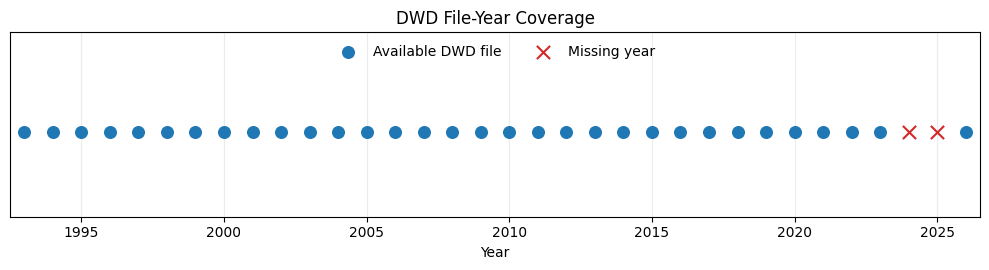

In [31]:

fig, ax = plt.subplots(figsize=(10, 2.8))
if len(file_years) > 0:
    yvals = np.ones(len(file_years))
    ax.scatter(file_years, yvals, s=70, color="#1f77b4", zorder=3, label="Available DWD file")

    if len(missing_years) > 0:
        ax.scatter(missing_years, np.ones(len(missing_years)), s=90, marker="x", color="#d62728", zorder=4, label="Missing year")

    ax.set_xlim(min(expected_years) - 0.5, max(expected_years) + 0.5)
    ax.set_ylim(0.7, 1.35)
    ax.set_yticks([])
    ax.set_xlabel("Year")
    ax.set_title("DWD File-Year Coverage")
    ax.grid(axis="x", alpha=0.25)
    ax.legend(loc="upper center", ncol=2, frameon=False)
else:
    ax.text(0.5, 0.5, "No DWD years found", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()

f1 = os.path.join(diag_dir, "diag_dwd_year_coverage.png")
plt.tight_layout()
plt.savefig(f1, dpi=150, bbox_inches="tight")
# plt.close(fig)

## Ensemble Size by Year

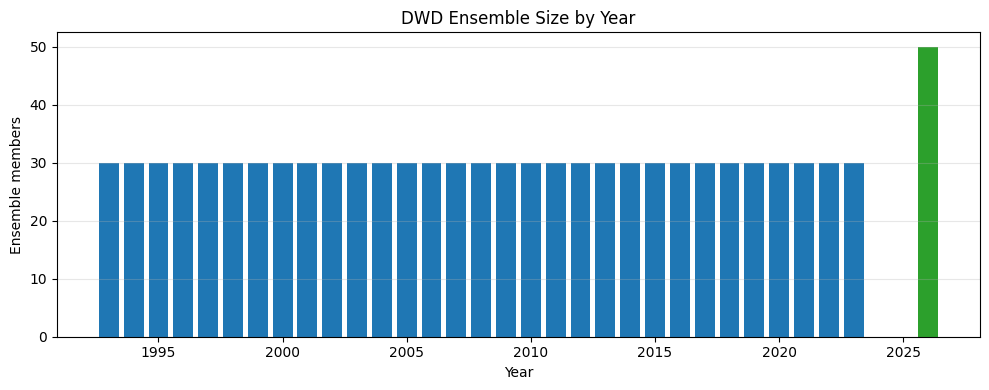

In [32]:
fig, ax = plt.subplots(figsize=(10, 4))
years_ok = [yr for yr in sorted(ens_per_year.keys()) if isinstance(ens_per_year[yr], int)]
if len(years_ok) > 0:
    ens_vals = [ens_per_year[yr] for yr in years_ok]
    colors = ["#2ca02c" if ens_vals[i] == max(ens_vals) else "#1f77b4" for i in range(len(ens_vals))]
    ax.bar(years_ok, ens_vals, color=colors, width=0.8)
    ax.set_xlabel("Year")
    ax.set_ylabel("Ensemble members")
    ax.set_title("DWD Ensemble Size by Year")
    ax.grid(axis="y", alpha=0.3)
else:
    ax.text(0.5, 0.5, "No valid ensemble-size records", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()

f2 = os.path.join(diag_dir, "diag_dwd_ensemble_size_by_year.png")
plt.tight_layout()
plt.savefig(f2, dpi=150, bbox_inches="tight")
# 
# plt.close(fig)

## CHIRPS Domain Climatology (mean annual cycle)

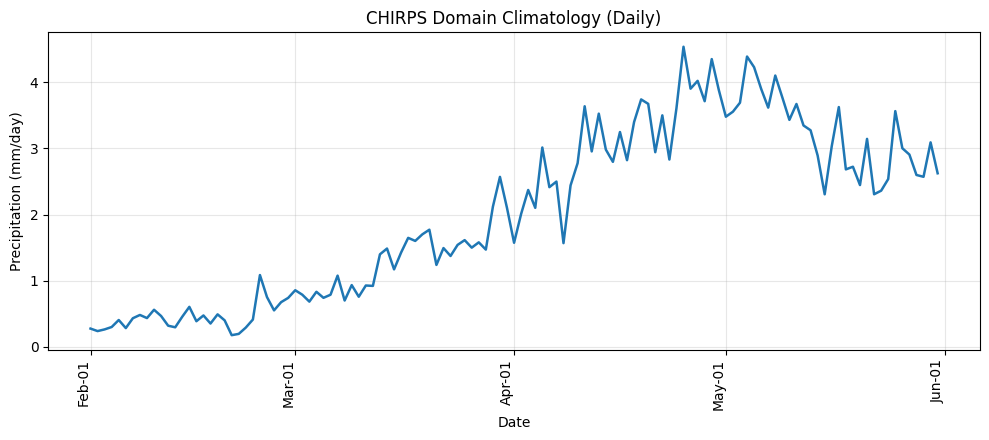

In [33]:
fig, ax = plt.subplots(figsize=(10, 4.5))
if "da_chirps_daily" in globals() and "chirps_years" in globals():
    # Domain average on land pixels only
    land_mask = lm.astype(bool) if "lm" in globals() else np.ones((n_lat, n_lon), dtype=bool)
    ts = np.nanmean(np.where(land_mask[None, None, :, :], da_chirps_daily, np.nan), axis=(2, 3))
    clim_doy = np.nanmean(ts, axis=0)

    # Use a leap reference year so 366 days are represented on the x-axis
    ref_dates = pd.date_range("2000-01-01", periods=len(clim_doy), freq="D")

    ax.plot(ref_dates, clim_doy, color="#1f77b4", lw=1.8)
    ax.set_xlabel("Date")
    ax.set_ylabel("Precipitation (mm/day)")
    ax.set_title("CHIRPS Domain Climatology (Daily)")
    ax.grid(alpha=0.3)

    # Format as calendar dates instead of DOY
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
    plt.setp(ax.get_xticklabels(), rotation=90, ha="right")
else:
    ax.text(0.5, 0.5, "Missing da_chirps_daily/chirps_years", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()

f3 = os.path.join(diag_dir, "diag_chirps_domain_daily_climatology.png")
plt.tight_layout()
plt.savefig(f3, dpi=150, bbox_inches="tight")
# plt.close(fig)


## CHIRPS annual total time series

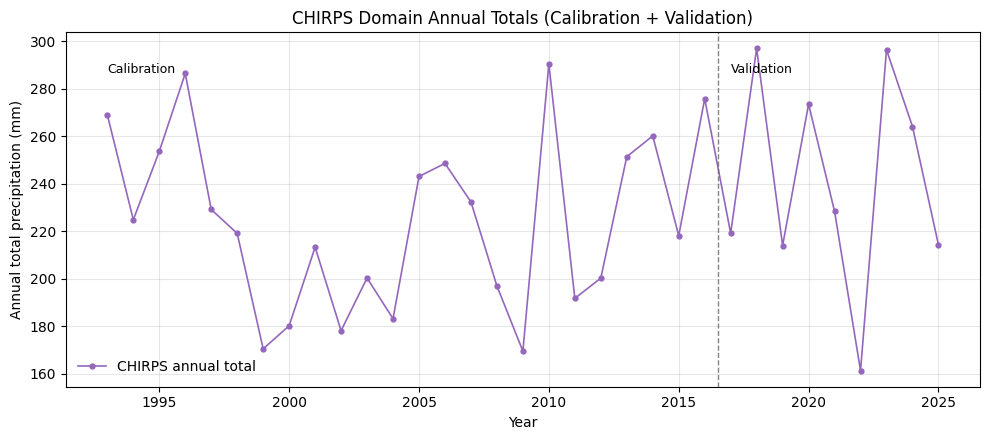

In [34]:

fig, ax = plt.subplots(figsize=(10, 4.5))

def _load_chirps_annual_domain_totals(nc_path, var_name, target_lat, target_lon, land_mask=None):
    ds_tmp = xr.open_dataset(nc_path, decode_times=True)
    try:
        da = ds_tmp[var_name]

        lat_name = "latitude" if "latitude" in da.coords else "lat"
        lon_name = "longitude" if "longitude" in da.coords else "lon"
        da = da.rename({lat_name: "lat", lon_name: "lon"})

        # Ensure ascending coordinates before interpolation
        if float(da.lat.values[0]) > float(da.lat.values[-1]):
            da = da.sortby("lat")
        if float(da.lon.values[0]) > float(da.lon.values[-1]):
            da = da.sortby("lon")

        # Regrid to target grid for consistent domain averaging
        da = da.interp(
            lat=xr.DataArray(target_lat, dims="lat"),
            lon=xr.DataArray(target_lon, dims="lon"),
            method="nearest",
        )

        # Remove physically invalid negatives
        da = da.where(da >= 0)

        # Annual totals (mm/year if source is mm/day)
        annual = da.groupby("time.year").sum("time", skipna=True)

        if land_mask is not None:
            lm_da = xr.DataArray(land_mask.astype(bool), dims=("lat", "lon"), coords={"lat": target_lat, "lon": target_lon})
            annual = annual.where(lm_da)

        domain_mean = annual.mean(("lat", "lon"), skipna=True)
        years = domain_mean["year"].values.astype(int)
        values = domain_mean.values.astype(float)
        return years, values
    finally:
        ds_tmp.close()

def _load_chirps_mean_spatial(nc_path, var_name, target_lat, target_lon, land_mask=None):
    ds_tmp = xr.open_dataset(nc_path, decode_times=True)
    try:
        da = ds_tmp[var_name]

        lat_name = "latitude" if "latitude" in da.coords else "lat"
        lon_name = "longitude" if "longitude" in da.coords else "lon"
        da = da.rename({lat_name: "lat", lon_name: "lon"})

        if float(da.lat.values[0]) > float(da.lat.values[-1]):
            da = da.sortby("lat")
        if float(da.lon.values[0]) > float(da.lon.values[-1]):
            da = da.sortby("lon")

        da = da.interp(
            lat=xr.DataArray(target_lat, dims="lat"),
            lon=xr.DataArray(target_lon, dims="lon"),
            method="nearest",
        )
        da = da.where(da >= 0)

        mean_map = da.mean("time", skipna=True)
        if land_mask is not None:
            lm_da = xr.DataArray(land_mask.astype(bool), dims=("lat", "lon"), coords={"lat": target_lat, "lon": target_lon})
            mean_map = mean_map.where(lm_da)

        return mean_map.values.astype(float)
    finally:
        ds_tmp.close()

try:
    land_mask = lm if "lm" in globals() else None

    cal_years_plot, cal_vals_plot = _load_chirps_annual_domain_totals(
        CHIRPS_CAL_PATH, CHIRPS_VAR, target_lat, target_lon, land_mask
    )
    val_years_plot, val_vals_plot = _load_chirps_annual_domain_totals(
        CHIRPS_VAL_PATH, CHIRPS_VAR, target_lat, target_lon, land_mask
    )

    all_years_plot = np.concatenate([cal_years_plot, val_years_plot])
    all_vals_plot = np.concatenate([cal_vals_plot, val_vals_plot])

    # Sort in chronological order
    order = np.argsort(all_years_plot)
    all_years_plot = all_years_plot[order]
    all_vals_plot = all_vals_plot[order]

    # Keep one value for any duplicate years (prefer validation value when duplicated)
    y2v = {}
    for y, v in zip(all_years_plot, all_vals_plot):
        y2v[int(y)] = float(v)
    plot_years = np.array(sorted(y2v.keys()), dtype=int)
    plot_vals = np.array([y2v[y] for y in plot_years], dtype=float)

    ax.plot(plot_years, plot_vals, marker="o", ms=3.5, lw=1.2, color="#9467bd", label="CHIRPS annual total")

    # Visual split between calibration and validation periods
    if len(cal_years_plot) > 0 and len(val_years_plot) > 0:
        split_x = (int(cal_years_plot.max()) + int(val_years_plot.min())) / 2.0
        ax.axvline(split_x, color="0.4", ls="--", lw=1.0, alpha=0.8)
        ax.text(int(cal_years_plot.min()), np.nanmax(plot_vals) * 0.98, "Calibration", ha="left", va="top", fontsize=9)
        ax.text(int(val_years_plot.min()), np.nanmax(plot_vals) * 0.98, "Validation", ha="left", va="top", fontsize=9)

    ax.set_xlabel("Year")
    ax.set_ylabel("Annual total precipitation (mm)")
    ax.set_title("CHIRPS Domain Annual Totals (Calibration + Validation)")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, loc="best")

except Exception as e:
    ax.text(0.5, 0.5, f"Could not build annual totals from CAL+VAL: {e}", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()

f4 = os.path.join(diag_dir, "diag_chirps_domain_annual_totals.png")
plt.tight_layout()
plt.savefig(f4, dpi=150, bbox_inches="tight")
# plt.close(fig)


## Spatial Diagnostic Maps (CAL mean, VAL mean, VAL-CAL difference)

Diagnostic plots saved:
  - data/processed/seasonal_data/outputs_dwd_v3\plots\diagnostics\diag_dwd_year_coverage.png
  - data/processed/seasonal_data/outputs_dwd_v3\plots\diagnostics\diag_dwd_ensemble_size_by_year.png
  - data/processed/seasonal_data/outputs_dwd_v3\plots\diagnostics\diag_chirps_domain_daily_climatology.png
  - data/processed/seasonal_data/outputs_dwd_v3\plots\diagnostics\diag_chirps_domain_annual_totals.png
  - data/processed/seasonal_data/outputs_dwd_v3\plots\diagnostics\diag_chirps_spatial_cal_val_diff.png


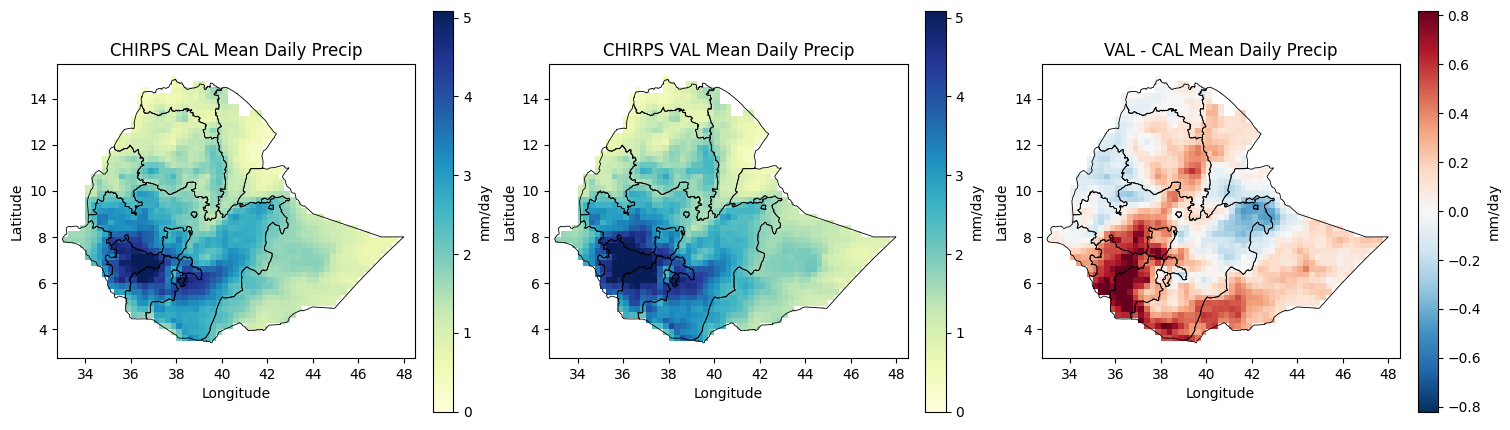

In [35]:

f5 = os.path.join(diag_dir, "diag_chirps_spatial_cal_val_diff.png")
try:
    land_mask = lm if "lm" in globals() else None
    cal_map = _load_chirps_mean_spatial(CHIRPS_CAL_PATH, CHIRPS_VAR, target_lat, target_lon, land_mask)
    val_map = _load_chirps_mean_spatial(CHIRPS_VAL_PATH, CHIRPS_VAR, target_lat, target_lon, land_mask)
    diff_map = val_map - cal_map

    finite_maps = np.concatenate([cal_map[np.isfinite(cal_map)], val_map[np.isfinite(val_map)]])
    vmax = np.nanpercentile(finite_maps, 98) if finite_maps.size else np.nan
    vmin = 0.0

    dabs = np.nanpercentile(np.abs(diff_map), 98) if np.isfinite(diff_map).any() else np.nan
    dv = dabs if np.isfinite(dabs) and dabs > 0 else 1.0

    figm, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

    im0 = axes[0].pcolormesh(target_lon, target_lat, cal_map, shading="auto", cmap="YlGnBu", vmin=vmin, vmax=vmax)
    axes[0].set_title("CHIRPS CAL Mean Daily Precip")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    plt.colorbar(im0, ax=axes[0], shrink=0.85, label="mm/day")

    im1 = axes[1].pcolormesh(target_lon, target_lat, val_map, shading="auto", cmap="YlGnBu", vmin=vmin, vmax=vmax)
    axes[1].set_title("CHIRPS VAL Mean Daily Precip")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    plt.colorbar(im1, ax=axes[1], shrink=0.85, label="mm/day")

    im2 = axes[2].pcolormesh(target_lon, target_lat, diff_map, shading="auto", cmap="RdBu_r", vmin=-dv, vmax=dv)
    axes[2].set_title("VAL - CAL Mean Daily Precip")
    axes[2].set_xlabel("Longitude")
    axes[2].set_ylabel("Latitude")
    plt.colorbar(im2, ax=axes[2], shrink=0.85, label="mm/day")

    if "ethiopia_shp" in globals():
        try:
            for a in axes:
                ethiopia_shp.boundary.plot(ax=a, color="black", linewidth=0.6)
        except Exception:
            pass

    plt.savefig(f5, dpi=150, bbox_inches="tight")
    # plt.close(figm)
except Exception as e:
    print(f"Spatial diagnostics not created: {e}")

print("Diagnostic plots saved:")
for fp in [f1, f2, f3, f4, f5]:
    print(f"  - {fp}")

## DWD GCFS2.1 DAILY INGESTION


Link: [https://cds.climate.copernicus.eu/datasets/seasonal-original-single-levels  # DWD GCFS2.1 product page1+C3S+contribution](https://cds.climate.copernicus.eu/datasets/seasonal-original-single-levels  # DWD GCFS2.1 product page1+C3S+contribution)

**DWD GCFS2.1:**
| Property | DWD GCFS 2.2 |
|---|---|
|Short Name |edzw |
|Time Range |6 month|
|Model ID | GCFS2.1-v20231101 |
|System Value | 4 |
| Members | 30 (hindcast) / 50 (OP 2026) |
| Hindcast years| 1993–2016 (missing 2024, 2025) |
| CAL years | 1993–2016 (24 yrs) |
| VAL years | 2017–2024 (8 yrs only) |
| Native grid| 0.4° |
| Ensemble dim| number |
| Time dim | forecast_period (hours) |




## DWD GCFS2.1 Daily Ingestion & Unit Conversion

**Input:** `tp` — cumulative total precipitation in metres  
`dims = (number, forecast_reference_time, forecast_period, latitude, longitude)`  
`shape = (3, 1, 182, 49, 45)` for hindcast years; `(11, 1, 182, 49, 45)` for 2026

**Conversion steps:**
1. Squeeze `forecast_reference_time` dim (size 1)
2. Trim to `N_MEMBERS=3` (so 2026 matches hindcast dimensions)
3. Differentiate along `forecast_period` axis → daily increments
4. Convert m → mm (×1000) and clip negatives to zero


## DWD GCFS2.1 Model Settings 

In [36]:
N_MEMBERS        = 30     # hindcast ensemble size (use 3 for all years for consistency)
N_FORECAST_DAYS  = 120   # Feb 1 → May 31 

DWD_INIT_MONTH   = 2
DWD_INIT_DAY     = 1

print(f"  DWD settings:")
print(f"    Hindcast members   : {N_MEMBERS}  (1993–2016)")
print(f"    Operational members: 50 → trimmed to {N_MEMBERS}  (2026)")
print(f"    Forecast length    : {N_FORECAST_DAYS} days")
print(f"    Initialisation     : {DWD_INIT_MONTH:02d}-{DWD_INIT_DAY:02d}  (Feb 1)")
print(f"    Precip variable    : '{DWD_VAR}'  (cumulative metres → diff → ×1000 → mm/day)")


  DWD settings:
    Hindcast members   : 30  (1993–2016)
    Operational members: 50 → trimmed to 30  (2026)
    Forecast length    : 120 days
    Initialisation     : 02-01  (Feb 1)
    Precip variable    : 'tp'  (cumulative metres → diff → ×1000 → mm/day)


## Regrids DWD to CHIRPS target grid

In [37]:

# Free large leftovers from previous runs to avoid kernel OOM
for _v in ["dwd_raw", "dwd_raw_native", "da_dwd", "da_dwd_rg", "da_dwd_nn", "dwd_raw_rg"]:
    if _v in globals():
        del globals()[_v]
gc.collect()

print("DWD Ingestion ...")
print(f"  Directory : {DWD_DIR}")
print(f"  Years     : {DWD_AVAILABLE_YEARS[0]}–{DWD_AVAILABLE_YEARS[-1]}  ({len(DWD_AVAILABLE_YEARS)} files)")
print(f"  Members   : {N_MEMBERS}  (hindcast) / 11 (2026, trimmed to {N_MEMBERS})")
print(f"  Forecast days : {N_FORECAST_DAYS}")


def _load_one_dwd_year(year, n_days_target=None):
    """Load one DWD file and convert cumulative metres to daily mm/day."""
    fpath = os.path.join(DWD_DIR, DWD_FILE_PATTERN.format(year=year))
    if not os.path.exists(fpath):
        raise FileNotFoundError(f"Missing: {fpath}")

    ds = xr.open_dataset(fpath, decode_times=False)
    tp = ds[DWD_VAR].values.astype(np.float32)

    # Replace non-finite and extreme fill-like values before differencing
    tp = np.where(np.isfinite(tp), tp, np.nan)
    tp = np.where(np.abs(tp) > 1e10, np.nan, tp)

    # (number, forecast_reference_time, forecast_period, lat, lon) -> (number, day, lat, lon)
    if tp.ndim == 5:
        tp = tp[:, 0, :, :, :]

    tp = tp[:N_MEMBERS, :, :, :]

    lat_name = "latitude" if "latitude" in ds.coords else "lat"
    lon_name = "longitude" if "longitude" in ds.coords else "lon"
    dwd_lat = ds[lat_name].values.astype(np.float64)
    dwd_lon = ds[lon_name].values.astype(np.float64)
    ds.close()

    ndays = tp.shape[1]
    if n_days_target is not None:
        if ndays > n_days_target:
            tp = tp[:, :n_days_target, :, :]
        elif ndays < n_days_target:
            pad_shape = (tp.shape[0], n_days_target - ndays, tp.shape[2], tp.shape[3])
            pad = np.full(pad_shape, np.nan, dtype=tp.dtype)
            tp = np.concatenate([tp, pad], axis=1)

    daily_m = np.empty_like(tp)
    daily_m[:, 0, :, :] = tp[:, 0, :, :]
    daily_m[:, 1:, :, :] = np.diff(tp, axis=1)

    # Convert m→mm and clip to physically plausible daily bounds
    daily_mm = np.clip(daily_m * 1000.0, 0.0, 1000.0).astype(np.float32)
    return daily_mm, dwd_lat, dwd_lon


# ── Load first file to define source shape/grid ────────────────────────────
_sample, _dwd_lat, _dwd_lon = _load_one_dwd_year(int(DWD_AVAILABLE_YEARS[0]))
_nm_dwd, _nd_dwd, _nlat_dwd, _nlon_dwd = _sample.shape
n_dwd_years = len(DWD_AVAILABLE_YEARS)
dwd_years = DWD_AVAILABLE_YEARS.copy()

print(f"  DWD source grid : {_nlat_dwd} lat × {_nlon_dwd} lon")
print(f"  DWD lat range   : {_dwd_lat[0]:.2f} → {_dwd_lat[-1]:.2f}")
print(f"  DWD lon range   : {_dwd_lon[0]:.2f} → {_dwd_lon[-1]:.2f}")
print(f"  DWD grid spacing: {abs(_dwd_lat[1]-_dwd_lat[0]):.4f}°")
print(f"  CHIRPS target   : {abs(target_lat[1]-target_lat[0]):.4f}°")

# ── Pre-allocate native-grid array ──────────────────────────────────────────
dwd_raw_native = np.full((_nm_dwd, n_dwd_years, _nd_dwd, _nlat_dwd, _nlon_dwd),
                         np.nan, np.float32)
dwd_raw_native[:, 0, :, :, :] = _sample

for yi in range(1, n_dwd_years):
    year = int(DWD_AVAILABLE_YEARS[yi])
    if yi % 5 == 0:
        print(f"  {year}  ({yi+1}/{n_dwd_years}) ...", flush=True)
    try:
        mm, _, _ = _load_one_dwd_year(year, _nd_dwd)
        dwd_raw_native[:, yi, :, :, :] = mm
    except FileNotFoundError as e:
        print(f"  MISSING: {e}")

# ── Regrid to CHIRPS target grid in memory-safe chunks ──────────────────────
print("  Regridding DWD to CHIRPS target grid (nearest-neighbor, year-wise) ...")
lat_idx = np.array([int(np.argmin(np.abs(_dwd_lat - lt))) for lt in target_lat], dtype=int)
lon_idx = np.array([int(np.argmin(np.abs(_dwd_lon - ln))) for ln in target_lon], dtype=int)

n_tlat = len(target_lat)
n_tlon = len(target_lon)

# Use float16 to reduce memory footprint for large 5-D arrays
dwd_raw = np.full((_nm_dwd, n_dwd_years, _nd_dwd, n_tlat, n_tlon), np.nan, dtype=np.float16)

for yi in range(n_dwd_years):
    block = dwd_raw_native[:, yi, :, :, :]                 # (member, day, lat, lon)
    block_rg = block[:, :, lat_idx, :]                     # (member, day, tlat, lon)
    block_rg = block_rg[:, :, :, lon_idx]                  # (member, day, tlat, tlon)
    block_rg = np.where(np.isfinite(block_rg), block_rg, np.nan)

    if "lm" in globals():
        block_rg = np.where(lm[None, None, :, :], block_rg, np.nan)

    dwd_raw[:, yi, :, :, :] = block_rg.astype(np.float16)

dwd_lat = target_lat.copy()
dwd_lon = target_lon.copy()

# Lightweight diagnostics to avoid high-memory full-array reductions
sample_native_mean = float(np.nanmean(dwd_raw_native[0, 0, :, :, :]))
sample_rg_mean = float(np.nanmean(dwd_raw[0, 0, :, :, :].astype(np.float32)))

print(f"  Regridded shape      : {dwd_raw.shape}  (member, year, day, lat, lon)")
print(f"  Sample native mean   : {sample_native_mean:.3f} mm/day  (member0/year0)")
print(f"  Sample regridded mean: {sample_rg_mean:.3f} mm/day  (member0/year0)")
print("Stage 1B DWD complete ✓")

DWD Ingestion ...
  Directory : data/raw/seasonal_data/dwd_et_precip
  Years     : 1993–2026  (32 files)
  Members   : 30  (hindcast) / 11 (2026, trimmed to 30)
  Forecast days : 120
  DWD source grid : 12 lat × 15 lon
  DWD lat range   : 14.50 → 3.50
  DWD lon range   : 33.50 → 47.50
  DWD grid spacing: 1.0000°
  CHIRPS target   : 0.2500°
  1998  (6/32) ...
  2003  (11/32) ...
  2008  (16/32) ...
  2013  (21/32) ...
  2018  (26/32) ...
  2023  (31/32) ...
  Regridding DWD to CHIRPS target grid (nearest-neighbor, year-wise) ...
  Regridded shape      : (30, 32, 121, 51, 63)  (member, year, day, lat, lon)
  Sample native mean   : 0.880 mm/day  (member0/year0)
  Sample regridded mean: 1.203 mm/day  (member0/year0)
Stage 1B DWD complete ✓


## DWD - Reindex DWD to CHIRPS 0.25° Target Grid


In [38]:
print("\nDWD: Reindexing DWD to CHIRPS 0.25° target grid ...")
print(f"  DWD source : {_nlat_dwd} × {_nlon_dwd}  ")
print(f"  Target     : {n_lat} × {n_lon}  ")
print("  Method     : nearest-neighbour reindex (memory-safe)")


def _reindex_dwd(data_nm_ny_nd_nlat_nlon, src_lat, src_lon, tgt_lat, tgt_lon, out_dtype=np.float16):
    """Memory-safe nearest-neighbour reindex from source grid to target grid."""
    nm, ny, nd, _, _ = data_nm_ny_nd_nlat_nlon.shape
    nlt = len(tgt_lat)
    nln = len(tgt_lon)

    lat_idx = np.array([int(np.argmin(np.abs(src_lat - lat))) for lat in tgt_lat], dtype=int)
    lon_idx = np.array([int(np.argmin(np.abs(src_lon - lon))) for lon in tgt_lon], dtype=int)

    out = np.full((nm, ny, nd, nlt, nln), np.nan, dtype=out_dtype)
    for yi in range(ny):
        block = data_nm_ny_nd_nlat_nlon[:, yi, :, :, :]   # (member, day, lat, lon)
        block_rg = block[:, :, lat_idx, :]                # (member, day, tlat, lon)
        block_rg = block_rg[:, :, :, lon_idx]             # (member, day, tlat, tlon)
        out[:, yi, :, :, :] = block_rg.astype(out_dtype)

    return out


# Select the available input array robustly
if "dwd_raw" in globals() and dwd_raw is not None:
    src_data = dwd_raw
    src_lat = dwd_lat if "dwd_lat" in globals() else _dwd_lat
    src_lon = dwd_lon if "dwd_lon" in globals() else _dwd_lon
elif "dwd_raw_native" in globals() and dwd_raw_native is not None:
    src_data = dwd_raw_native
    src_lat = _dwd_lat
    src_lon = _dwd_lon
else:
    raise NameError("Neither dwd_raw nor dwd_raw_native is available. Run Stage 1B first.")

# If already on target grid, just copy; otherwise reindex
if src_data.shape[-2:] == (len(target_lat), len(target_lon)):
    dwd_rg = src_data.astype(np.float16, copy=True)
else:
    dwd_rg = _reindex_dwd(src_data, src_lat, src_lon, target_lat, target_lon, out_dtype=np.float16)

# Apply Ethiopia land mask
if "lm" in globals():
    dwd_rg = np.where(lm[None, None, None, :, :], dwd_rg, np.nan).astype(np.float16)

print(f"\n  dwd_rg shape  : {dwd_rg.shape}")
print(f"  Sample mean   : {float(np.nanmean(dwd_rg[0, 0, :, :, :].astype(np.float32))):.3f} mm/day")
print(f"  Non-NaN frac  : {np.sum(~np.isnan(dwd_rg[0, 0, :, :, :])) / dwd_rg[0, 0, :, :, :].size:.3f}  (sample member0/year0)")
print("Stage 2B DWD complete ✓")



DWD: Reindexing DWD to CHIRPS 0.25° target grid ...
  DWD source : 12 × 15  
  Target     : 51 × 63  
  Method     : nearest-neighbour reindex (memory-safe)

  dwd_rg shape  : (30, 32, 121, 51, 63)
  Sample mean   : 1.203 mm/day
  Non-NaN frac  : 0.498  (sample member0/year0)
Stage 2B DWD complete ✓


## Daily Ingestion & Unit Conversion

**Input:** `tp` — cumulative total precipitation in metres  
`dims = (number, forecast_reference_time, forecast_period, latitude, longitude)`  
`shape = (3, 1, 182, 49, 45)` for hindcast years; `(11, 1, 182, 49, 45)` for 2026

**Conversion steps:**
1. Squeeze `forecast_reference_time` dim (size 1)
2. Trim to `N_MEMBERS=3` (so 2026 matches hindcast dimensions)
3. Differentiate along `forecast_period` axis → daily increments
4. Convert m → mm (×1000) and clip negatives to zero


In [39]:
print("Stage 1B DWD: CM ACCESS-S2 daily ingestion ...")
print(f"  Directory : {DWD_DIR}")
print(f"  Years     : {DWD_AVAILABLE_YEARS[0]}–{DWD_AVAILABLE_YEARS[-1]}  ({len(DWD_AVAILABLE_YEARS)} files)")
print(f"  Members   : {N_MEMBERS}  (hindcast) / 11 (2026, trimmed to {N_MEMBERS})")
print(f"  Forecast days : {N_FORECAST_DAYS}")


def _load_one_dwd_year(year, n_days_target=None):
    """
    Load one DWD ACCESS-S2 file.
    Convert cumulative tp (metres) to daily mm/day.

    DWD dims: (number, forecast_reference_time, forecast_period, lat, lon)
    Steps:
      1. Squeeze forecast_reference_time (size 1)
      2. Trim to N_MEMBERS (hindcast=3, OP=11 → trimmed to 3)
      3. Optionally trim/pad forecast_period to n_days_target
      4. Diff along forecast_period → daily increments (day 0 = first 24h)
      5. ×1000 m→mm, clip negatives

    Returns
    -------
    daily_mm : (N_MEMBERS, n_days, n_lat_dwd, n_lon_dwd)  float32  mm/day
    dwd_lat  : (n_lat_dwd,)  float64
    dwd_lon  : (n_lon_dwd,)  float64
    """
    fpath = os.path.join(DWD_DIR, DWD_FILE_PATTERN.format(year=year))
    if not os.path.exists(fpath):
        raise FileNotFoundError(f"Missing: {fpath}")

    ds  = xr.open_dataset(fpath, decode_times=False)
    tp  = ds[DWD_VAR].values.astype(np.float64)
    # dims: (number, forecast_reference_time, forecast_period, lat, lon)

    # 1. Squeeze forecast_reference_time (axis 1, size 1)
    if tp.ndim == 5:
        tp = tp[:, 0, :, :, :]          # → (number, forecast_period, lat, lon)

    # 2. Trim to N_MEMBERS (handles 2026 with 11 members)
    tp = tp[:N_MEMBERS, :, :, :]        # → (N_MEMBERS, ndays, lat, lon)

    # 3. Lat/lon
    lat_name = "latitude"  if "latitude"  in ds.coords else "lat"
    lon_name = "longitude" if "longitude" in ds.coords else "lon"
    dwd_lat  = ds[lat_name].values.astype(np.float64)
    dwd_lon  = ds[lon_name].values.astype(np.float64)
    ds.close()

    # 3b. Harmonise number of forecast days across years
    ndays = tp.shape[1]
    if n_days_target is not None:
        if ndays > n_days_target:
            # Trim extra days to match target
            tp = tp[:, :n_days_target, :, :]
            ndays = n_days_target
        elif ndays < n_days_target:
            # Pad missing days with NaNs (will propagate as 0 after clipping)
            pad_shape = (tp.shape[0], n_days_target - ndays, tp.shape[2], tp.shape[3])
            pad = np.full(pad_shape, np.nan, dtype=tp.dtype)
            tp = np.concatenate([tp, pad], axis=1)
            ndays = n_days_target

    # 4. Cumulative → daily increments along forecast_period axis (axis 1)
    daily_m = np.empty_like(tp)
    daily_m[:, 0, :, :] = tp[:, 0, :, :]           # first 24h total
    daily_m[:, 1:, :, :] = np.diff(tp, axis=1)      # subsequent days

    # 5. m → mm, clip negatives from floating-point noise
    daily_mm = np.clip(daily_m * 1000.0, 0.0, None).astype(np.float32)
    return daily_mm, dwd_lat, dwd_lon


# ── Load first file to get source grid dimensions ─────────────────────────
_sample, _dwd_lat, _dwd_lon = _load_one_dwd_year(int(DWD_AVAILABLE_YEARS[0]))
_nm_dwd, _nd_dwd, _nlat_dwd, _nlon_dwd = _sample.shape
n_dwd_years  = len(DWD_AVAILABLE_YEARS)
dwd_years    = DWD_AVAILABLE_YEARS.copy()

print(f"  DWD source grid : {_nlat_dwd} lat × {_nlon_dwd} lon")
print(f"  DWD lat range   : {_dwd_lat[0]:.2f} → {_dwd_lat[-1]:.2f}")
print(f"  DWD lon range   : {_dwd_lon[0]:.2f} → {_dwd_lon[-1]:.2f}")
print(f"  DWD grid spacing: {abs(_dwd_lat[1]-_dwd_lat[0]):.4f}°  (matches CHIRPS 0.25° ✓)")

# ── Pre-allocate raw array ────────────────────────────────────────────────
dwd_raw = np.full((_nm_dwd, n_dwd_years, _nd_dwd, _nlat_dwd, _nlon_dwd),
                  np.nan, np.float32)
dwd_raw[:, 0, :, :, :] = _sample

for yi in range(1, n_dwd_years):
    year = int(DWD_AVAILABLE_YEARS[yi])
    if yi % 5 == 0:
        print(f"  {year}  ({yi+1}/{n_dwd_years}) ...", flush=True)
    try:
        mm, _, _ = _load_one_dwd_year(year, _nd_dwd)
        dwd_raw[:, yi, :, :, :] = mm
    except FileNotFoundError as e:
        print(f"  MISSING: {e}")

dm = np.nanmean(dwd_raw)
print(f"\n  dwd_raw shape : {dwd_raw.shape}")
print(f"  Domain mean   : {dm:.3f} mm/day  (expected ~1–3 mm/day for Feb–Aug)")
print(f"  Negatives     : {int(np.sum(dwd_raw < 0))}  (should be 0)")
print("Stage 1B DWD complete ✓")

Stage 1B DWD: CM ACCESS-S2 daily ingestion ...
  Directory : data/raw/seasonal_data/dwd_et_precip
  Years     : 1993–2026  (32 files)
  Members   : 30  (hindcast) / 11 (2026, trimmed to 30)
  Forecast days : 120
  DWD source grid : 12 lat × 15 lon
  DWD lat range   : 14.50 → 3.50
  DWD lon range   : 33.50 → 47.50
  DWD grid spacing: 1.0000°  (matches CHIRPS 0.25° ✓)
  1998  (6/32) ...
  2003  (11/32) ...
  2008  (16/32) ...
  2013  (21/32) ...
  2018  (26/32) ...
  2023  (31/32) ...

  dwd_raw shape : (30, 32, 121, 12, 15)
  Domain mean   : 0.778 mm/day  (expected ~1–3 mm/day for Feb–Aug)
  Negatives     : 0  (should be 0)
Stage 1B DWD complete ✓


## Reindex DWD to CHIRPS 0.25° Target Grid


In [40]:
print("\nStage 2B DWD: Reindexing DWD to CHIRPS 0.25° target grid ...")
print(f"  DWD source : {_nlat_dwd} × {_nlon_dwd}  (0.25°)")
print(f"  Target     : {n_lat} × {n_lon}  (0.25°)")
print("  Method     : nearest-neighbour reindex  (no interpolation — grids match)")


def _reindex_dwd(data_nm_ny_nd_nlat_nlon, src_lat, src_lon, tgt_lat, tgt_lon):
    """
    Reindex DWD (already 0.25°) onto the CHIRPS target grid by finding
    the nearest source index for each target lat/lon.

    Parameters
    ----------
    data : (n_members, n_years, n_days, n_lat_src, n_lon_src)
    src_lat, src_lon : 1-D source coordinate arrays

    Returns
    -------
    out : (n_members, n_years, n_days, n_lat_tgt, n_lon_tgt)
    """
    nm, ny, nd, _, _ = data_nm_ny_nd_nlat_nlon.shape
    nlt = len(tgt_lat); nln = len(tgt_lon)
    out = np.full((nm, ny, nd, nlt, nln), np.nan, np.float32)

    for i, lat in enumerate(tgt_lat):
        si = int(np.argmin(np.abs(src_lat - lat)))
        for j, lon in enumerate(tgt_lon):
            sj = int(np.argmin(np.abs(src_lon - lon)))
            if 0 <= si < len(src_lat) and 0 <= sj < len(src_lon):
                out[:, :, :, i, j] = data_nm_ny_nd_nlat_nlon[:, :, :, si, sj]
    return out


dwd_rg = _reindex_dwd(dwd_raw, _dwd_lat, _dwd_lon, target_lat, target_lon)

# Apply Kenya land mask
for yi in range(n_dwd_years):
    dwd_rg[:, yi, :, ~lm] = np.nan

del dwd_raw   # free memory

print(f"\n  dwd_rg shape  : {dwd_rg.shape}")
print(f"  Domain mean   : {np.nanmean(dwd_rg):.3f} mm/day")
print(f"  Non-NaN frac  : {np.sum(~np.isnan(dwd_rg))/dwd_rg.size:.3f}")
print("Stage 2B DWD complete ✓")



Stage 2B DWD: Reindexing DWD to CHIRPS 0.25° target grid ...
  DWD source : 12 × 15  (0.25°)
  Target     : 51 × 63  (0.25°)
  Method     : nearest-neighbour reindex  (no interpolation — grids match)

  dwd_rg shape  : (30, 32, 121, 51, 63)
  Domain mean   : 1.055 mm/day
  Non-NaN frac  : 0.498
Stage 2B DWD complete ✓


## DAILY QM-BC, MEMBER-WISE     


- It is a highly effective, computationally efficient statistical technique used to correct systematic distributional biases in climate model simulations by aligning their cumulative distribution functions (CDFs) with observed data. 

- It adjusts both the mean and variance, making it superior to simple scaling for precipitation and temperature.          

In [41]:
print("\n DWD: Daily QM-BC (member-wise) ...")
print(f"  CAL period       : {CAL_YEARS[0]}–{CAL_YEARS[-1]}  ({len(CAL_YEARS)} years)")
print(f"  DOY window       : +/-{QM_DOY_WINDOW} days around each forecast day")
print(f"  Wet-day thresh   : {WET_DAY_THRESH} mm/day")
print(f"  Transform        : cube-root (power={BC_TRANSFORM_POWER:.4f})")
print(f"  Land pixels      : {int(lm.sum())}")

# Use actual calendar dates for the forecast window definition.
_ref_year = 2001  # non-leap reference for display only
WIN_START_DATE = datetime.date(_ref_year, DWD_INIT_MONTH, DWD_INIT_DAY)
WIN_END_DATE = WIN_START_DATE + datetime.timedelta(days=_nd_dwd - 1)
WIN_DOY_START = WIN_START_DATE.timetuple().tm_yday
WIN_DOY_END = WIN_END_DATE.timetuple().tm_yday

# Ensure dwd_rg exists even if it was deleted by a previous run.
if "dwd_rg" not in globals() or dwd_rg is None:
    if "dwd_raw" in globals() and dwd_raw is not None:
        if dwd_raw.shape[-2:] == (len(target_lat), len(target_lon)):
            dwd_rg = dwd_raw.copy()
        else:
            lat_idx = np.array([int(np.argmin(np.abs(_dwd_lat - lt))) for lt in target_lat], dtype=int)
            lon_idx = np.array([int(np.argmin(np.abs(_dwd_lon - ln))) for ln in target_lon], dtype=int)
            dwd_rg = np.full((dwd_raw.shape[0], dwd_raw.shape[1], dwd_raw.shape[2], len(target_lat), len(target_lon)), np.nan, dtype=np.float16)
            for yi in range(dwd_raw.shape[1]):
                blk = dwd_raw[:, yi, :, :, :]
                blk = blk[:, :, lat_idx, :]
                blk = blk[:, :, :, lon_idx]
                dwd_rg[:, yi, :, :, :] = blk
    elif "dwd_raw_native" in globals() and dwd_raw_native is not None:
        lat_idx = np.array([int(np.argmin(np.abs(_dwd_lat - lt))) for lt in target_lat], dtype=int)
        lon_idx = np.array([int(np.argmin(np.abs(_dwd_lon - ln))) for ln in target_lon], dtype=int)
        dwd_rg = np.full((dwd_raw_native.shape[0], dwd_raw_native.shape[1], dwd_raw_native.shape[2], len(target_lat), len(target_lon)), np.nan, dtype=np.float16)
        for yi in range(dwd_raw_native.shape[1]):
            blk = dwd_raw_native[:, yi, :, :, :]
            blk = blk[:, :, lat_idx, :]
            blk = blk[:, :, :, lon_idx]
            dwd_rg[:, yi, :, :, :] = blk
    else:
        raise NameError("No DWD source array found. Run Stage 1B/2B before Stage 3B.")

    if "lm" in globals():
        dwd_rg[:, :, :, ~lm] = np.nan

# Keep sanitization in-place and lightweight to avoid large allocations.
np.clip(dwd_rg, 0.0, 1000.0, out=dwd_rg)


 DWD: Daily QM-BC (member-wise) ...
  CAL period       : 1993–2016  (24 years)
  DOY window       : +/-15 days around each forecast day
  Wet-day thresh   : 0.1 mm/day
  Transform        : cube-root (power=0.3333)
  Land pixels      : 1601


array([[[[[nan, nan, nan, ..., nan, nan, nan],
          [nan, nan, nan, ..., nan, nan, nan],
          [nan, nan, nan, ..., nan, nan, nan],
          ...,
          [nan, nan, nan, ..., nan, nan, nan],
          [nan, nan, nan, ..., nan, nan, nan],
          [nan, nan, nan, ..., nan, nan, nan]],

         [[nan, nan, nan, ..., nan, nan, nan],
          [nan, nan, nan, ..., nan, nan, nan],
          [nan, nan, nan, ..., nan, nan, nan],
          ...,
          [nan, nan, nan, ..., nan, nan, nan],
          [nan, nan, nan, ..., nan, nan, nan],
          [nan, nan, nan, ..., nan, nan, nan]],

         [[nan, nan, nan, ..., nan, nan, nan],
          [nan, nan, nan, ..., nan, nan, nan],
          [nan, nan, nan, ..., nan, nan, nan],
          ...,
          [nan, nan, nan, ..., nan, nan, nan],
          [nan, nan, nan, ..., nan, nan, nan],
          [nan, nan, nan, ..., nan, nan, nan]],

         ...,

         [[nan, nan, nan, ..., nan, nan, nan],
          [nan, nan, nan, ..., nan, nan, 

In [42]:


print("\n Daily QM-BC (member-wise) ...")
print(f"  CAL period       : {CAL_YEARS[0]}–{CAL_YEARS[-1]}")
print(f"  DOY window       : +/-{QM_DOY_WINDOW} days around each forecast day")
print(f"  Wet-day thresh   : {WET_DAY_THRESH} mm/day")
print(f"  Transform        : cube-root (power={BC_TRANSFORM_POWER:.4f})")
print(f"  Land pixels      : {int(lm.sum())}")
print(f"  Forecast window  : {WIN_START_DATE.strftime('%b %d')} – {WIN_END_DATE.strftime('%b %d')} ({_nd_dwd} days)")


def _build_qm_transfer(c_pool, s_pool):
    c_wet = c_pool[c_pool > WET_DAY_THRESH]
    s_wet = s_pool[s_pool > WET_DAY_THRESH]

    if len(c_wet) < 5 or len(s_wet) < 5:
        return lambda x: x

    f_c = len(c_wet) / max(len(c_pool), 1)
    f_s = len(s_wet) / max(len(s_pool), 1)
    if f_s > f_c and len(s_wet) > 1:
        n_clip = int(round((f_s - f_c) * len(s_pool)))
        if n_clip > 0:
            cutoff = np.sort(s_wet)[min(n_clip, len(s_wet) - 1)]
            s_wet = s_wet[s_wet >= cutoff]
    if len(s_wet) < 3:
        return lambda x: x

    power = BC_TRANSFORM_POWER
    c_tr = np.sort(c_wet ** power)
    s_tr = np.sort(s_wet ** power)
    n_c, n_s = len(c_tr), len(s_wet)
    p_s = (np.arange(1, n_s + 1) - 0.5) / n_s
    p_c = (np.arange(1, n_c + 1) - 0.5) / n_c

    def transfer(x_raw):
        if x_raw <= WET_DAY_THRESH:
            return 0.0
        x_t = max(x_raw, 0.0) ** power
        p_hat = float(np.interp(x_t, s_tr, p_s, left=p_s[0], right=p_s[-1]))
        x_c_t = float(np.interp(p_hat, p_c, c_tr, left=c_tr[0], right=c_tr[-1]))
        return float(max(x_c_t, 0.0) ** (1.0 / power))

    return transfer


dwd_bc = dwd_rg.copy()
land_pixels = np.argwhere(lm)
n_land = len(land_pixels)

# CAL masks aligned to CHIRPS and DWD year axes
cal_mask_c_dwd = np.isin(CHIRPS_FULL_YEARS, CAL_YEARS)
cal_mask_s_dwd = np.isin(dwd_years, CAL_YEARS)
cal_idx_c_dwd = np.where(cal_mask_c_dwd)[0]

for pix_num, (pi, pj) in enumerate(land_pixels):
    if (pix_num + 1) % 100 == 0:
        print(f"  Pixel {pix_num+1:4d} / {n_land}  ({100*(pix_num+1)/n_land:.0f}%)", flush=True)

    transfer_fns = [None] * _nd_dwd
    for d in range(_nd_dwd):
        c_pool = []

        # Build CHIRPS pool using actual dates (year-aware leap handling).
        for ci in cal_idx_c_dwd:
            yr = int(CHIRPS_FULL_YEARS[ci])
            base_date = datetime.date(yr, DWD_INIT_MONTH, DWD_INIT_DAY) + datetime.timedelta(days=d)
            for off in range(-QM_DOY_WINDOW, QM_DOY_WINDOW + 1):
                sample_date = base_date + datetime.timedelta(days=off)
                doy_k = sample_date.timetuple().tm_yday
                v = da_chirps_daily[ci, doy_k - 1, pi, pj]
                if not np.isnan(v):
                    c_pool.append(float(v))

        c_pool = np.array(c_pool, dtype=np.float32)

        # DWD pool: CAL years, forecast day d, all members
        s_pool = dwd_rg[:, cal_mask_s_dwd, d, pi, pj].ravel()
        s_pool = s_pool[~np.isnan(s_pool)]

        transfer_fns[d] = _build_qm_transfer(c_pool, s_pool)

    for m in range(_nm_dwd):
        for yi in range(n_dwd_years):
            for d in range(_nd_dwd):
                raw = float(dwd_rg[m, yi, d, pi, pj])
                if (not np.isfinite(raw)) or np.isnan(raw):
                    continue
                dwd_bc[m, yi, d, pi, pj] = float(transfer_fns[d](raw))

# In-place cap to keep output bounded without creating a large temporary copy.
np.clip(dwd_bc, 0.0, 1000.0, out=dwd_bc)

del dwd_rg

# QC with actual-date window per year
bc_cal_dwd = dwd_bc[:, cal_mask_s_dwd, :, :, :]
bc_mean = float(np.nanmean(bc_cal_dwd))

chirps_vals = []
for ci in cal_idx_c_dwd:
    yr = int(CHIRPS_FULL_YEARS[ci])
    for d in range(_nd_dwd):
        sample_date = datetime.date(yr, DWD_INIT_MONTH, DWD_INIT_DAY) + datetime.timedelta(days=d)
        doy_k = sample_date.timetuple().tm_yday
        arr = da_chirps_daily[ci, doy_k - 1, :, :]
        chirps_vals.append(arr[lm])

chirps_vals = np.concatenate(chirps_vals) if len(chirps_vals) > 0 else np.array([np.nan], dtype=np.float32)
chirps_win_mean = float(np.nanmean(chirps_vals))

print(f"\n  dwd_bc shape        : {dwd_bc.shape}")
print(f"  dwd BC CAL mean     : {bc_mean:.3f} mm/day")
print(f"  CHIRPS CAL win mean : {chirps_win_mean:.3f} mm/day")
print(f"  Ratio (should be ~1): {bc_mean/chirps_win_mean:.3f}")
print(f"  Negatives           : {int(np.sum(dwd_bc < 0))}  (should be 0)")
print("Stage 3B dwd complete ✓")


 Daily QM-BC (member-wise) ...
  CAL period       : 1993–2016
  DOY window       : +/-15 days around each forecast day
  Wet-day thresh   : 0.1 mm/day
  Transform        : cube-root (power=0.3333)
  Land pixels      : 1601
  Forecast window  : Feb 01 – Jun 01 (121 days)
  Pixel  100 / 1601  (6%)
  Pixel  200 / 1601  (12%)
  Pixel  300 / 1601  (19%)
  Pixel  400 / 1601  (25%)
  Pixel  500 / 1601  (31%)
  Pixel  600 / 1601  (37%)
  Pixel  700 / 1601  (44%)
  Pixel  800 / 1601  (50%)
  Pixel  900 / 1601  (56%)
  Pixel 1000 / 1601  (62%)
  Pixel 1100 / 1601  (69%)
  Pixel 1200 / 1601  (75%)
  Pixel 1300 / 1601  (81%)
  Pixel 1400 / 1601  (87%)
  Pixel 1500 / 1601  (94%)
  Pixel 1600 / 1601  (100%)

  dwd_bc shape        : (30, 32, 121, 51, 63)
  dwd BC CAL mean     : 1.865 mm/day
  CHIRPS CAL win mean : 2.024 mm/day
  Ratio (should be ~1): 0.921
  Negatives           : 0  (should be 0)
Stage 3B dwd complete ✓


### Save QM-BC corrected and parameters

In [43]:
print(f"\n  Saving dwd_bc to {OUT_DWD_BC} ...")
xr.DataArray(
    dwd_bc,
    dims=["member", "year", "day", "lat", "lon"],
    coords={
        "member" : np.arange(1, _nm_dwd + 1),
        "year"   : dwd_years,
        "day"    : np.arange(_nd_dwd),
        "lat"    : target_lat,
        "lon"    : target_lon,
    },
    attrs={
        "long_name"          : "DWD GCFS2.1 daily precipitation — QM-BC corrected",
        "units"              : "mm/day",
        "source_model"       : "DWD GCFS2.1 via C3S",
        "bias_correction"    : "member-wise empirical QM, cube-root transform",
        "wet_day_threshold"  : f"{WET_DAY_THRESH} mm/day",
        "doy_window"         : f"+/-{QM_DOY_WINDOW} days",
        "calibration_period" : f"{CAL_YEARS[0]}-{CAL_YEARS[-1]}",
        "n_members"          : _nm_dwd,
    }
).to_netcdf(OUT_DWD_BC)
print(f"  Saved -> {OUT_DWD_BC}")
print("\n DWD complete ✓")
print(f"  dwd_bc  : {dwd_bc.shape}  — ready for Stage 4B Dunning detection")



  Saving dwd_bc to data/processed/seasonal_data/outputs_dwd_v3\DWD_bc_daily_all_years.nc ...
  Saved -> data/processed/seasonal_data/outputs_dwd_v3\DWD_bc_daily_all_years.nc

 DWD complete ✓
  dwd_bc  : (30, 32, 121, 51, 63)  — ready for Stage 4B Dunning detection


## Helper Function

In [44]:
plt.rcParams.update({
    "figure.dpi"       : 150,
    "figure.facecolor" : "white",
    "font.family"      : "DejaVu Sans",
    "font.size"        : 10,
    "axes.titlesize"   : 10,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 9,
    "savefig.bbox"     : "tight",
    "savefig.dpi"      : 150,
})

DIAG_DIR = os.path.join(PLOT_DIR, "stage3B_diagnostics")
os.makedirs(DIAG_DIR, exist_ok=True)

# ── Colours ────────────────────────────────────────────────────────────────
COL_CHIRPS = "#1E6B45"    # green  — CHIRPS (truth)
COL_RAW    = "#E05C3A"    # orange — SEAS5 raw (uncorrected)
COL_BC     = "#1B5EA6"    # blue   — SEAS5 bias corrected

# ── Helpers ────────────────────────────────────────────────────────────────
def _doy_to_date(doy, year=2000):
    try:
        return (datetime.date(year, 1, 1) +
                datetime.timedelta(days=int(round(float(doy))) - 1)
                ).strftime("%d %b")
    except Exception:
        return "?"

def _save(fig, name):
    p = os.path.join(DIAG_DIR, f"{name}.png")
    fig.savefig(p, bbox_inches="tight", dpi=150)
    print(f"  Saved -> {p}")

def _pcm(ax, data2d, cmap, vmin, vmax):
    masked   = np.ma.array(data2d, mask=np.isnan(data2d))
    lon_edge = np.append(target_lon - 0.125, target_lon[-1] + 0.125)
    lat_edge = np.append(target_lat - 0.125, target_lat[-1] + 0.125)
    LON, LAT = np.meshgrid(lon_edge, lat_edge)
    return ax.pcolormesh(LON, LAT, masked, cmap=cmap, vmin=vmin, vmax=vmax,
                         transform=ccrs.PlateCarree(), zorder=1, shading="flat")

def _base_map(ax):
    # Dynamic map extent from the active target grid (Ethiopia domain in this notebook).
    lat_pad = float(np.abs(target_lat[1] - target_lat[0]) / 2.0) if len(target_lat) > 1 else 0.2
    lon_pad = float(np.abs(target_lon[1] - target_lon[0]) / 2.0) if len(target_lon) > 1 else 0.2
    x0 = float(np.nanmin(target_lon) - lon_pad)
    x1 = float(np.nanmax(target_lon) + lon_pad)
    y0 = float(np.nanmin(target_lat) - lat_pad)
    y1 = float(np.nanmax(target_lat) + lat_pad)
    ax.set_extent([x0, x1, y0, y1], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN,     facecolor="#EAF4FB", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="#333", zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle="--",
                   edgecolor="#555", zorder=3)

    shape_gdf = None
    if "kenya_shp" in globals():
        shape_gdf = kenya_shp
    elif "ethiopia_shp" in globals():
        shape_gdf = ethiopia_shp
    if shape_gdf is not None:
        shape_gdf.boundary.plot(ax=ax, linewidth=1.2, edgecolor="black",
                                transform=ccrs.PlateCarree(), zorder=4)

    gl = ax.gridlines(draw_labels=True, linewidth=0.35, color="gray",
                      alpha=0.4, linestyle="--")
    gl.top_labels   = False
    gl.right_labels = False

    # Choose readable ticks from the current domain bounds.
    x_ticks = np.arange(np.floor(x0), np.ceil(x1) + 0.001, 2.0)
    y_ticks = np.arange(np.floor(y0), np.ceil(y1) + 0.001, 2.0)
    gl.xlocator = mticker.FixedLocator(x_ticks.tolist())
    gl.ylocator = mticker.FixedLocator(y_ticks.tolist())
    gl.xlabel_style = {"size": 6}
    gl.ylabel_style = {"size": 6}

# ── Representative sites (targets) ────────────────────────────────────────
SITES = [
    {"name": "North Highlands", "lat": 12.0, "lon": 39.0},
    {"name": "Central Plateau", "lat":  9.0, "lon": 38.0},
    {"name": "Western Zone",    "lat": 10.0, "lon": 35.5},
    {"name": "Eastern Lowland", "lat":  8.0, "lon": 42.0},
    {"name": "Southern Zone",   "lat":  6.0, "lon": 38.0},
]

# Build forecast-window DOYs from actual dates so downstream plots share Stage 3B semantics.
if "WIN_START_DATE" in globals():
    _win_start = WIN_START_DATE
else:
    _win_start = datetime.date(2001, DWD_INIT_MONTH, DWD_INIT_DAY)
WIN_DOYS = np.array([
    (_win_start + datetime.timedelta(days=d)).timetuple().tm_yday
    for d in range(_nd_dwd)
], dtype=int)
WIN_DOY_START = int(WIN_DOYS[0]) if WIN_DOYS.size else 1
WIN_DOY_END = int(WIN_DOYS[-1]) if WIN_DOYS.size else WIN_DOY_START

# ── Pre-compute CHIRPS window-mean daily cycle per pixel ──────────────────
# Shape (n_win, n_lat, n_lon): mean over all CAL years for each window DOY
print("Pre-computing CHIRPS window climatology ...")
cal_mask_c = np.isin(chirps_years, CAL_YEARS)
cal_mask_dwd = np.isin(dwd_years,  CAL_YEARS)

chirps_win_clim = np.full((_nd_dwd, n_lat, n_lon), np.nan, np.float32)
for k, doy in enumerate(WIN_DOYS):
    d_idx = doy - 1
    v = da_chirps_daily[cal_mask_c, d_idx, :, :]
    chirps_win_clim[k] = np.nanmean(v, axis=0)
chirps_win_clim[:, ~lm] = np.nan

# DWD BC ensemble-mean window climatology (CAL)
bc_ens_mean_clim = np.nanmean(
    dwd_bc[:, cal_mask_dwd, :, :, :], axis=(0, 1))   # (_nd_dwd, n_lat, n_lon)
bc_ens_mean_clim[:, ~lm] = np.nan

# Map each site target to a unique valid pixel with finite CHIRPS climatology.
site_valid_mask = lm & np.isfinite(np.nanmean(chirps_win_clim, axis=0))
cand = np.argwhere(site_valid_mask)
if cand.size == 0:
    cand = np.argwhere(lm)

cand_lat = target_lat[cand[:, 0]]
cand_lon = target_lon[cand[:, 1]]
used = set()

for s in SITES:
    d2 = (cand_lat - s["lat"])**2 + (cand_lon - s["lon"])**2
    order = np.argsort(d2)
    chosen = None
    for oi in order:
        key = (int(cand[oi, 0]), int(cand[oi, 1]))
        if key not in used:
            chosen = key
            break
    if chosen is None:
        chosen = (int(cand[order[0], 0]), int(cand[order[0], 1]))
    used.add(chosen)
    s["i"], s["j"] = chosen

print("  Done.")

Pre-computing CHIRPS window climatology ...
  Done.


## Mean Daily Cycle: CHIRPS vs DWD BC (5 sites)


Fig 1: Mean daily cycle comparison ...
  Saved -> data/processed/seasonal_data/outputs_dwd_v3\plots\stage3B_diagnostics\dwd_fig1_mean_daily_cycle.png


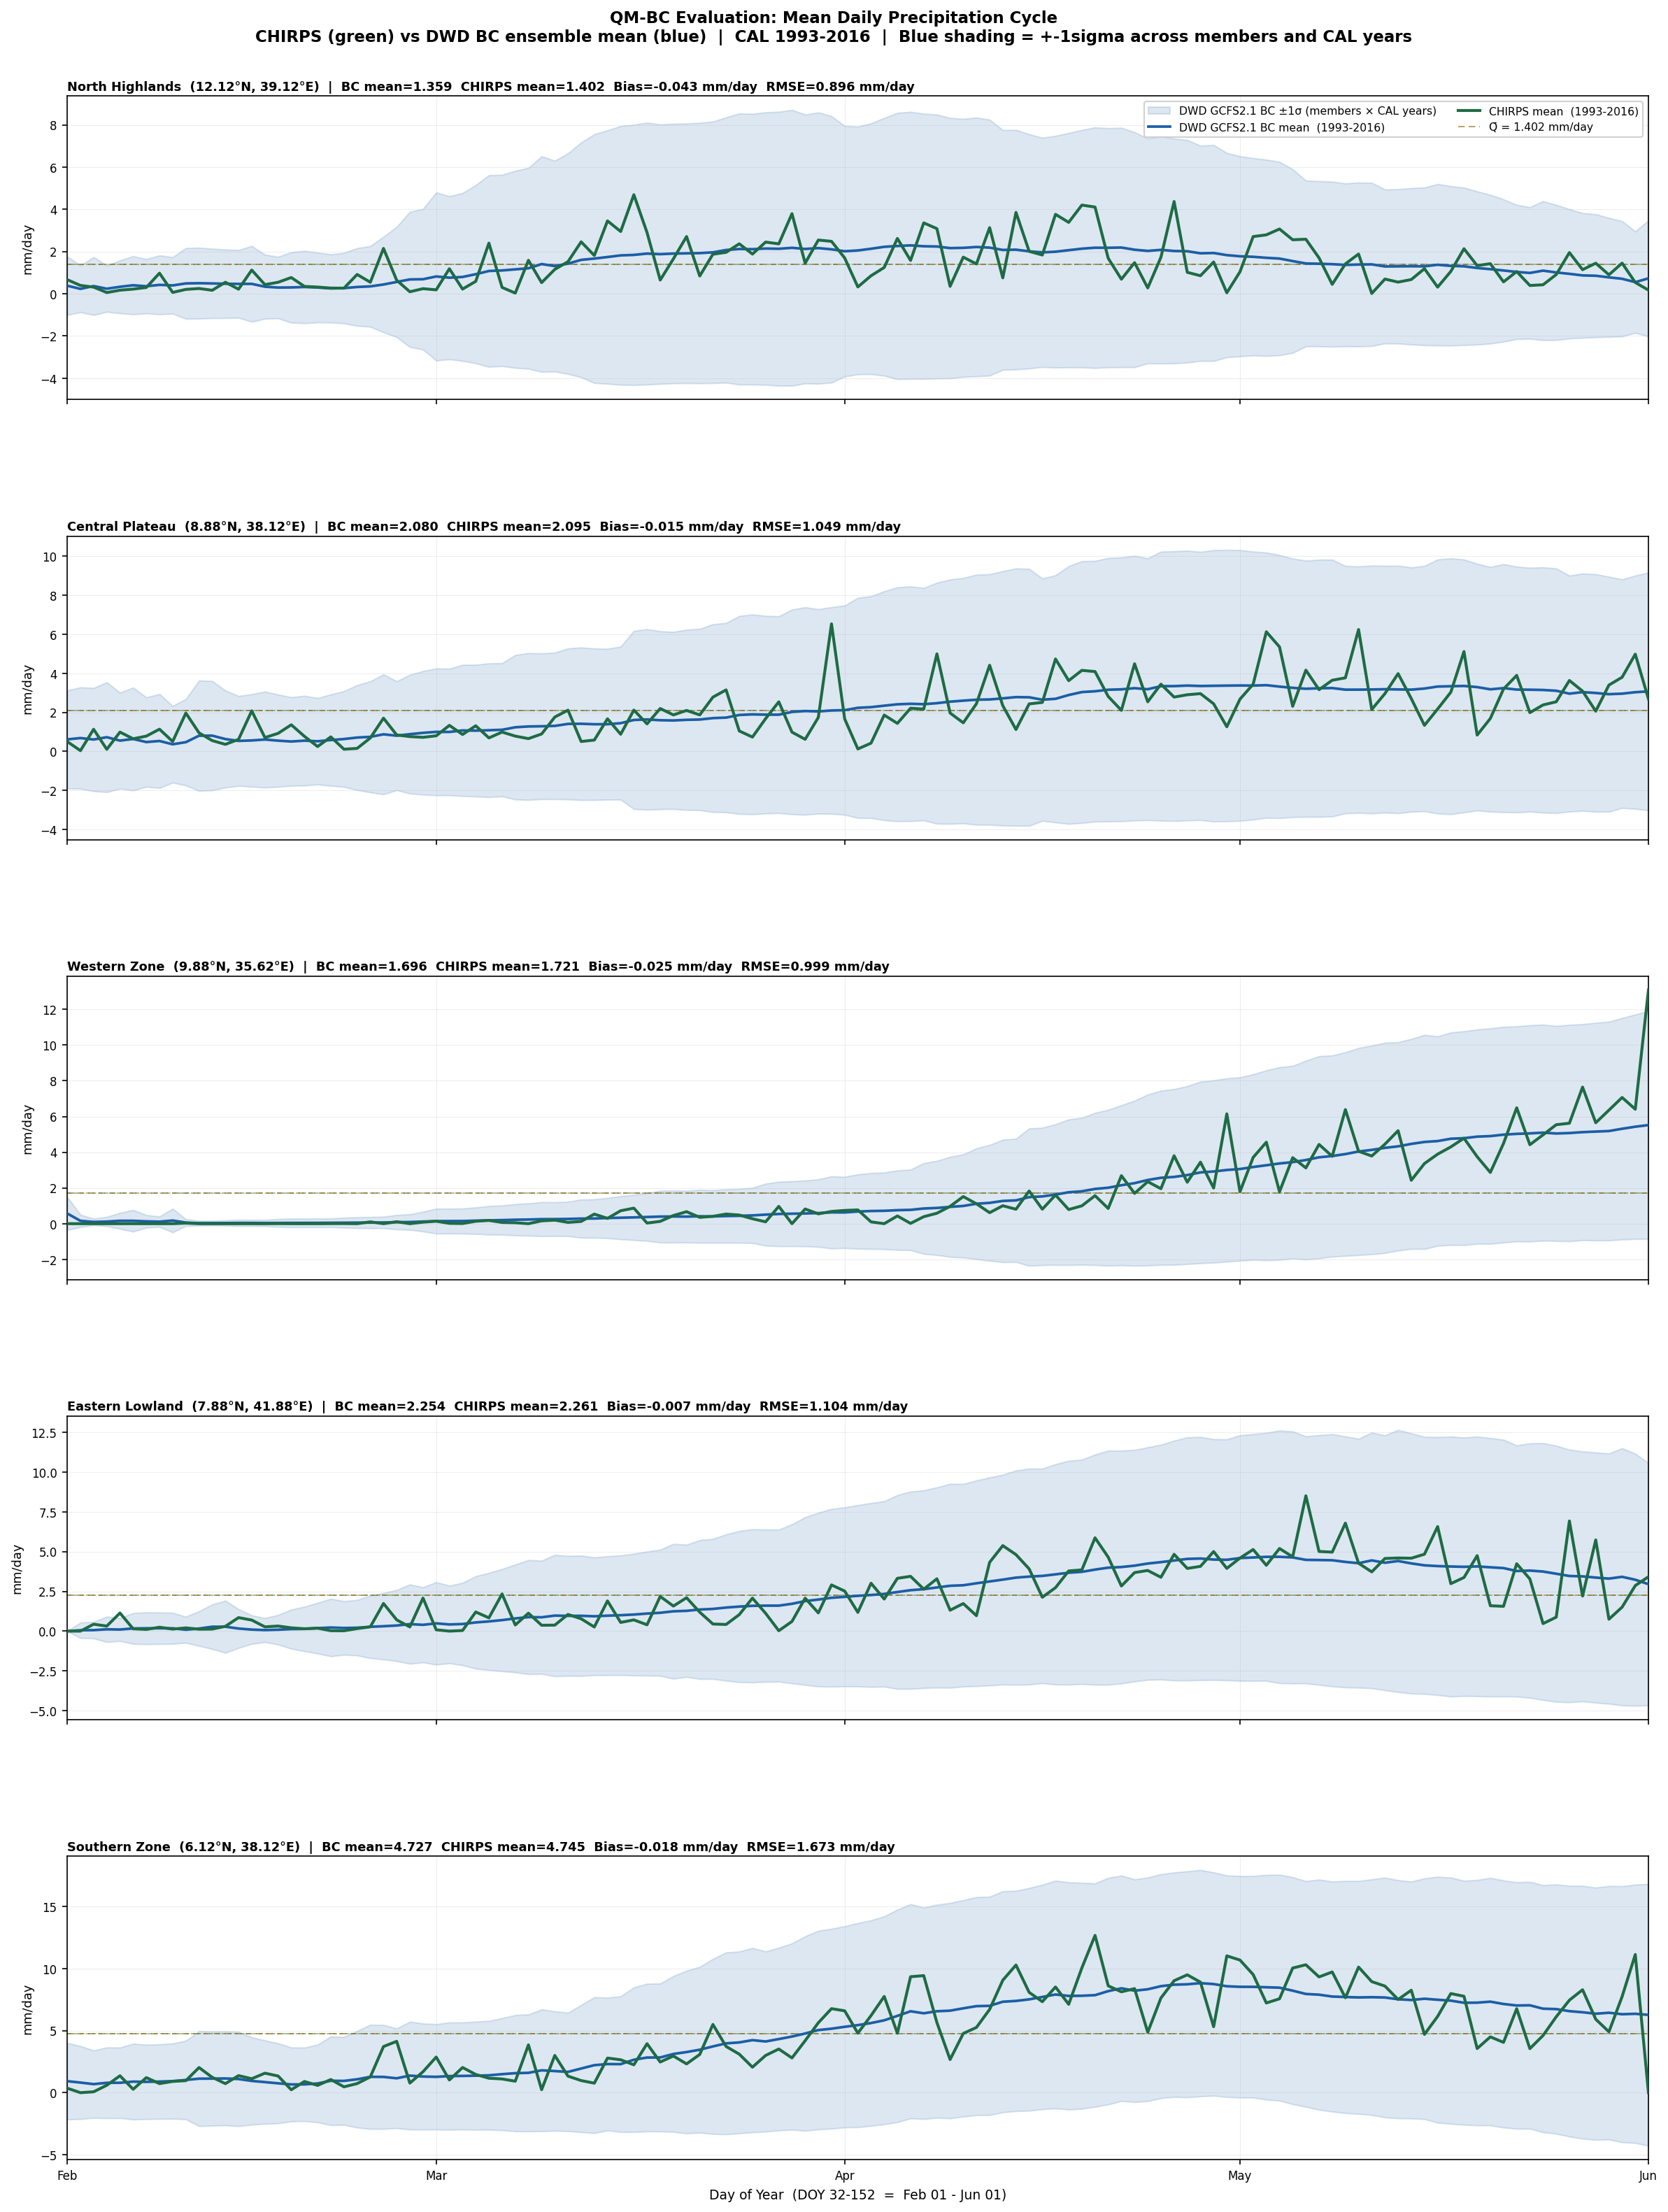

In [45]:
print("\nFig 1: Mean daily cycle comparison ...")

# Month tick helpers
MONTH_TICKS  = [d for d in [32, 60, 91, 121, 152, 182, 213]
                if WIN_DOY_START <= d <= WIN_DOY_END]
MONTH_LABELS = ["Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug"][:len(MONTH_TICKS)]

# Use precomputed Q_bar when available; otherwise use CHIRPS window mean per pixel as fallback.
if "Q_bar" in globals() and Q_bar is not None:
    qbar_ref = Q_bar
else:
    qbar_ref = np.nanmean(chirps_win_clim, axis=0)

fig1, axes1 = plt.subplots(len(SITES), 1, figsize=(16, 4.2 * len(SITES)),
                            sharex=True)

for row, (ax, s) in enumerate(zip(axes1, SITES)):
    ii, jj = s["i"], s["j"]

    # CHIRPS CAL daily mean (limited to available DWD forecast days)
    ch_mean = chirps_win_clim[:, ii, jj]

    # DWD BC: ensemble mean over CAL years, per day
    bc_all = dwd_bc[:, cal_mask_dwd, :, ii, jj]           # (n_mem, n_cal, _nd_dwd)
    bc_mean_1d = np.nanmean(bc_all, axis=(0, 1))          # (_nd_dwd,)

    # DWD BC: ±1 std across members × CAL years
    bc_std = np.nanstd(bc_all.reshape(-1, _nd_dwd), axis=0)

    # Use only the first _nd_dwd DOYs so x and y lengths match
    x_doys = WIN_DOYS[:_nd_dwd]

    ax.fill_between(x_doys, bc_mean_1d - bc_std, bc_mean_1d + bc_std,
                    color=COL_BC, alpha=0.15, zorder=1,
                    label="DWD GCFS2.1 BC ±1σ (members × CAL years)")
    ax.plot(x_doys, bc_mean_1d, color=COL_BC, lw=1.8, zorder=3,
            label=f"DWD GCFS2.1 BC mean  ({CAL_YEARS[0]}-{CAL_YEARS[-1]})")
    ax.plot(x_doys, ch_mean, color=COL_CHIRPS, lw=2.0, ls="-", zorder=4,
            label=f"CHIRPS mean  ({CAL_YEARS[0]}-{CAL_YEARS[-1]})")
    ax.axhline(float(np.nanmean(ch_mean)), color=COL_CHIRPS, lw=0.8,
               ls="--", alpha=0.50, zorder=2)

    # Q_bar reference (fallback is CHIRPS mean per pixel when Q_bar is not defined)
    ax.axhline(float(qbar_ref[ii, jj]), color="#92680A", lw=0.9,
               ls=(0, (5, 3)), alpha=0.65, zorder=2,
               label=f"Q̄ = {qbar_ref[ii, jj]:.3f} mm/day")

    ax.set_xlim(WIN_DOY_START, WIN_DOY_END)
    ax.set_xticks(MONTH_TICKS)
    ax.set_xticklabels(MONTH_LABELS, fontsize=8.5)
    ax.set_ylabel("mm/day", fontsize=8.5)
    ax.grid(True, lw=0.3, alpha=0.35)
    ax.tick_params(labelsize=8)

    rmse = float(np.sqrt(np.nanmean((bc_mean_1d - ch_mean)**2)))
    bias = float(np.nanmean(bc_mean_1d - ch_mean))
    ax.set_title(
        f"{s['name']}  ({target_lat[ii]:.2f}°N, {target_lon[jj]:.2f}°E)  |  "
        f"BC mean={np.nanmean(bc_mean_1d):.3f}  CHIRPS mean={np.nanmean(ch_mean):.3f}  "
        f"Bias={bias:+.3f} mm/day  RMSE={rmse:.3f} mm/day",
        fontsize=8.5, loc="left", pad=4)

    if row == 0:
        ax.legend(fontsize=7.5, loc="upper right", framealpha=0.90,
                  ncol=2, handlelength=2.0)

axes1[-1].set_xlabel(
    f"Day of Year  (DOY {WIN_DOY_START}-{WIN_DOY_END}  =  {WIN_START_DATE.strftime('%b %d')} - {WIN_END_DATE.strftime('%b %d')})",
    fontsize=9)
fig1.suptitle(
    "QM-BC Evaluation: Mean Daily Precipitation Cycle\n"
    "CHIRPS (green) vs DWD BC ensemble mean (blue)  |  CAL 1993-2016  |  "
    "Blue shading = +-1sigma across members and CAL years",
    fontsize=11, fontweight="bold", y=1.002)
plt.tight_layout()
fig1.subplots_adjust(hspace=0.45)
_save(fig1, "dwd_fig1_mean_daily_cycle")
plt.show()

## Empirical CDFs: CHIRPS vs SEAS5 BC (5 sites × 3 representative days)


Fig 2: Empirical CDFs ...
  Saved -> data/processed/seasonal_data/outputs_dwd_v3\plots\stage3B_diagnostics\dwd_fig2_empirical_cdfs.png


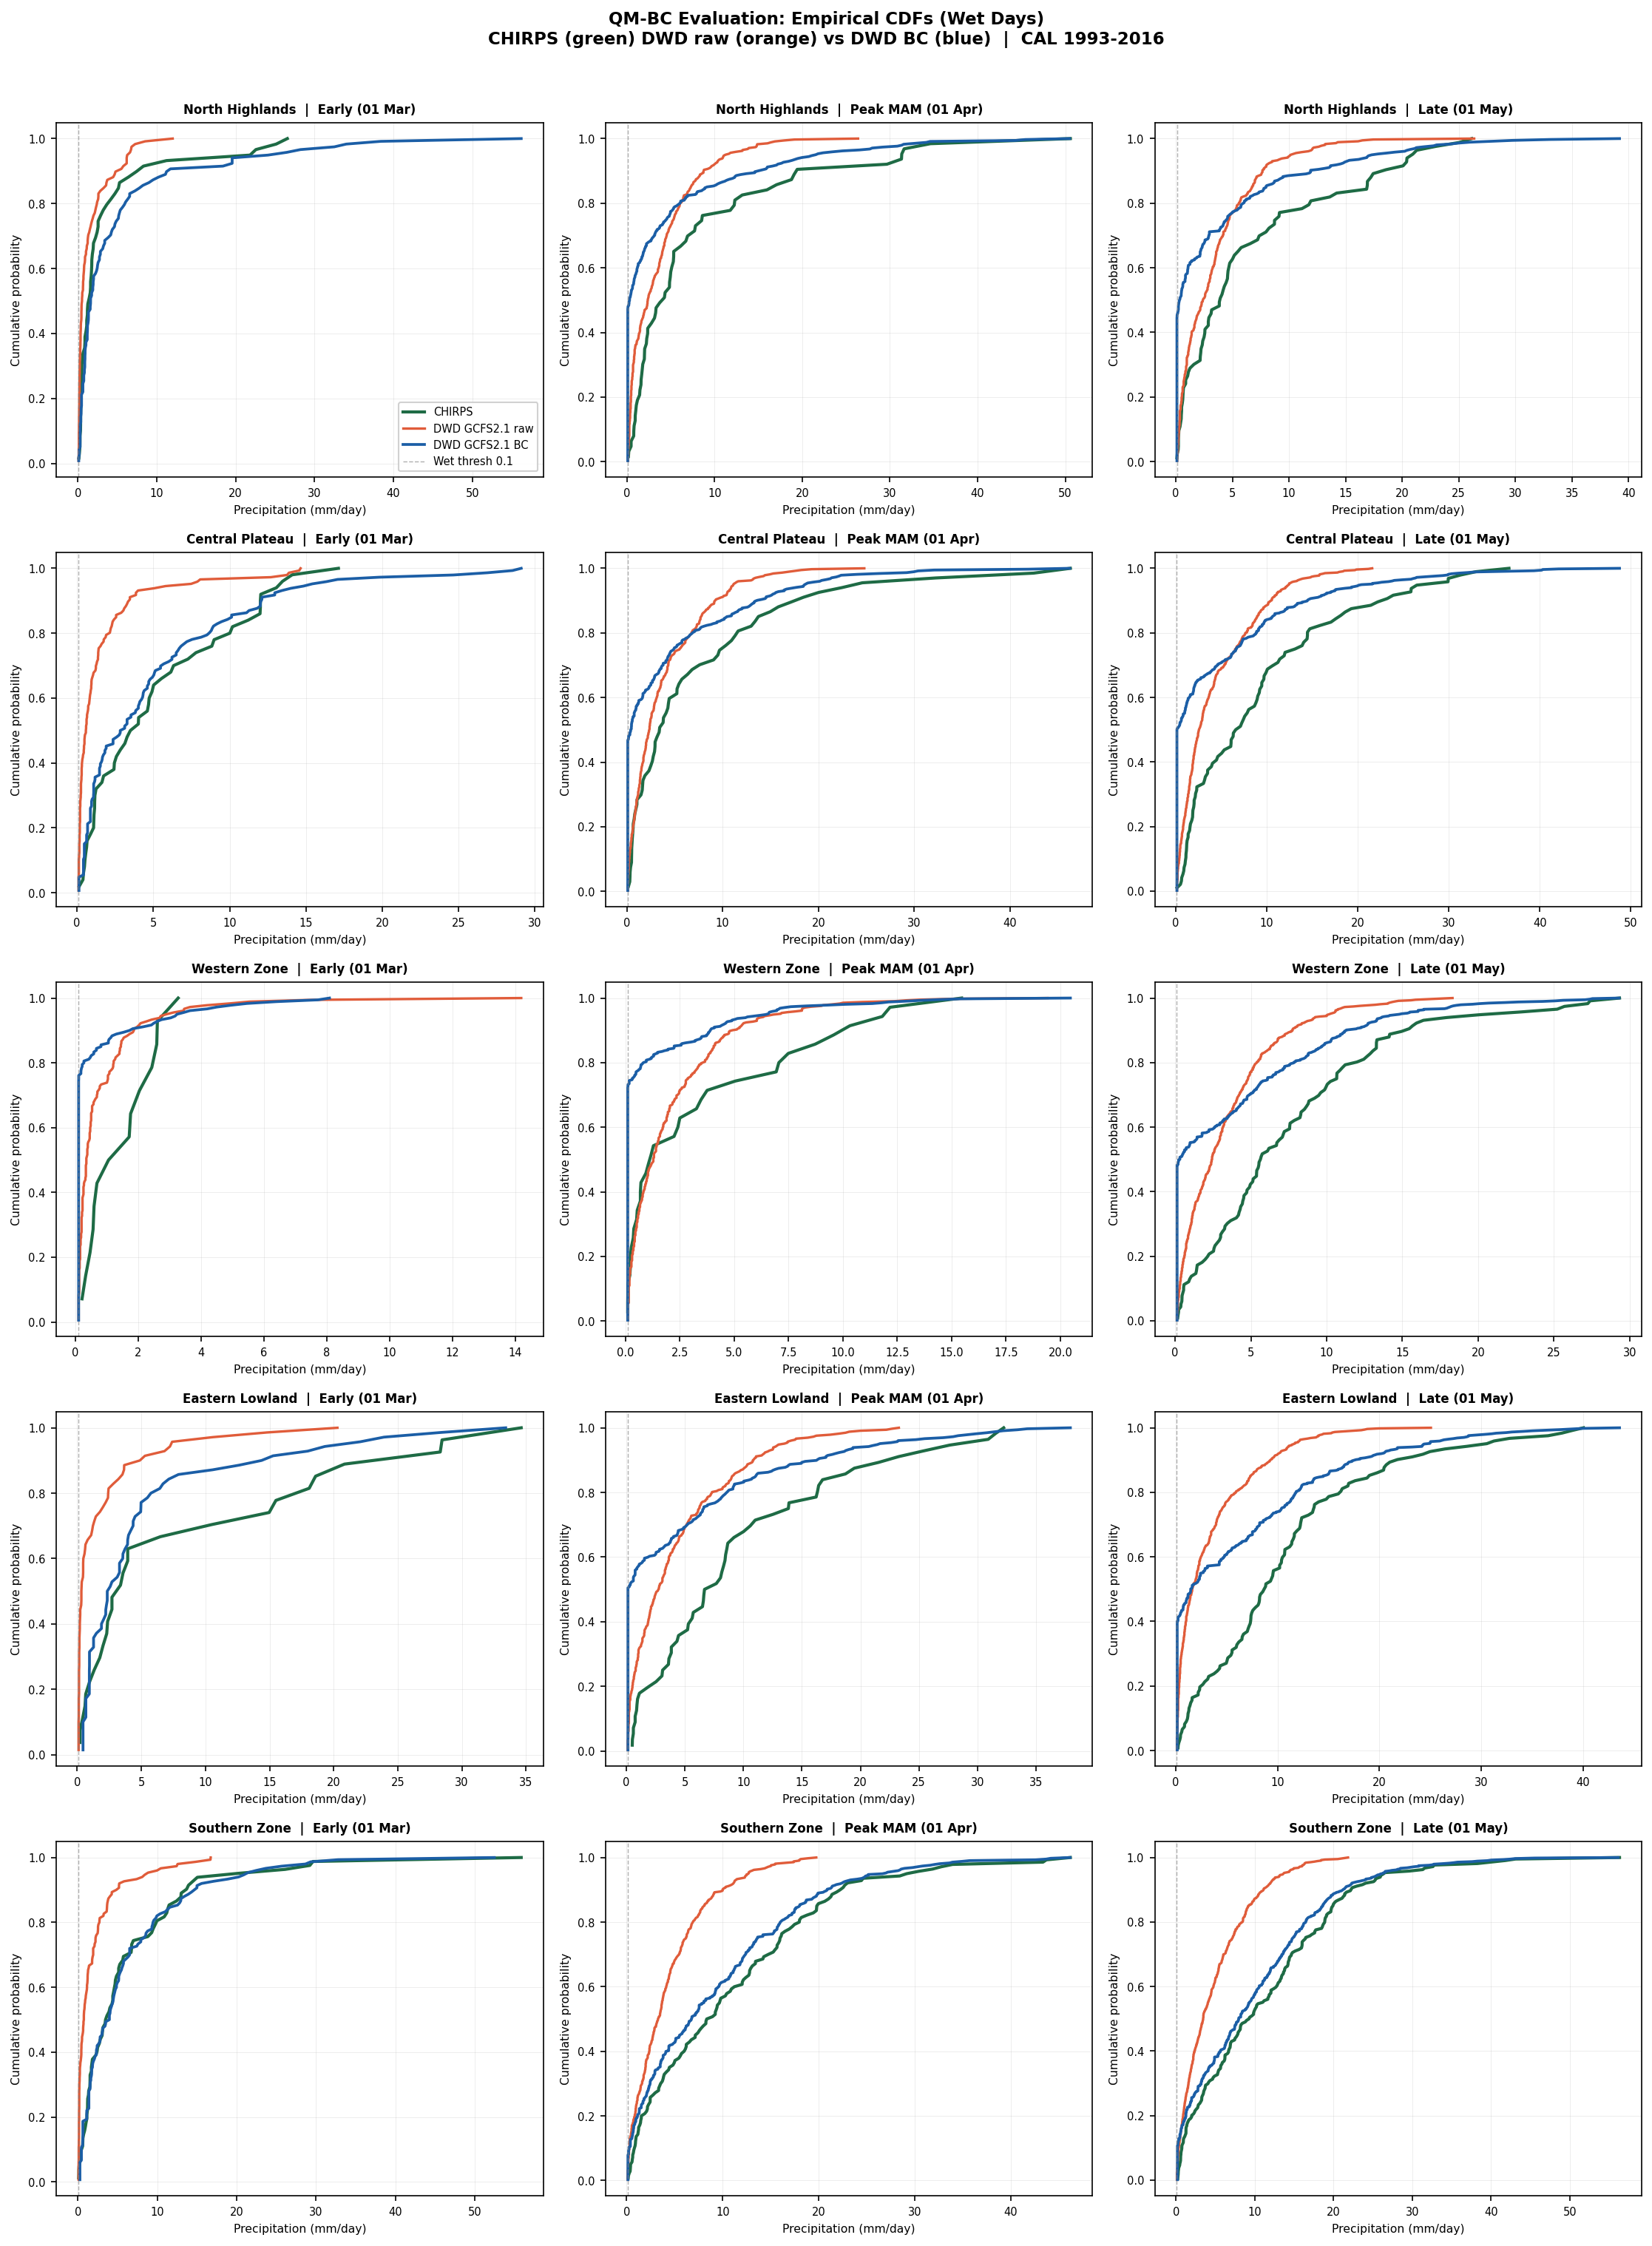

In [46]:
print("\nFig 2: Empirical CDFs ...")

# Pick 3 representative forecast days: early-window (Mar), peak-MAM (Apr), late (May)
FOCAL_DAYS = {
    "Early (01 Mar)": int(np.where(WIN_DOYS == 60)[0][0])
    if 60 in WIN_DOYS else 28,
    "Peak MAM (01 Apr)": int(np.where(WIN_DOYS == 91)[0][0])
    if 91 in WIN_DOYS else 59,
    "Late (01 May)": int(np.where(WIN_DOYS == 121)[0][0])
    if 121 in WIN_DOYS else 89,
}
FOCAL_DAY_KEYS = list(FOCAL_DAYS.keys())

fig2, axes2 = plt.subplots(len(SITES), len(FOCAL_DAYS),
                            figsize=(5 * len(FOCAL_DAYS), 4 * len(SITES)),
                            sharey=False)

for row, s in enumerate(SITES):
    ii, jj = s["i"], s["j"]
    for col, (dlabel, d_idx) in enumerate(FOCAL_DAYS.items()):
        ax = axes2[row, col]

        # CHIRPS: all CAL years, ±5 days around d_idx for more samples
        doy_d  = WIN_DOYS[d_idx]
        c_vals = []
        for ci in np.where(cal_mask_c)[0]:
            for off in range(-5, 6):
                idx2 = doy_d - 1 + off
                if 0 <= idx2 < da_chirps_daily.shape[1]:
                    v = da_chirps_daily[ci, idx2, ii, jj]
                    if not np.isnan(v):
                        c_vals.append(float(v))
        c_vals = np.array(c_vals)

        # DWD BC: all members, CAL years, day d_idx
        bc_vals = dwd_bc[:, cal_mask_dwd, d_idx, ii, jj].ravel()
        bc_vals = bc_vals[~np.isnan(bc_vals)]

        # DWD RAW fallback chain:
        # 1) use dwd_rg if available,
        # 2) otherwise sample from dwd_raw_native at nearest native-grid point.
        raw_vals = None
        if "dwd_rg" in globals() and dwd_rg is not None:
            rv = dwd_rg[:, cal_mask_dwd, d_idx, ii, jj].ravel()
            rv = rv[~np.isnan(rv)]
            raw_vals = rv
        elif "dwd_raw_native" in globals() and dwd_raw_native is not None:
            pt_lat = float(target_lat[ii])
            pt_lon = float(target_lon[jj])
            src_i = int(np.argmin(np.abs(_dwd_lat - pt_lat)))
            src_j = int(np.argmin(np.abs(_dwd_lon - pt_lon)))
            rv = dwd_raw_native[:, cal_mask_dwd, d_idx, src_i, src_j].ravel()
            rv = rv[~np.isnan(rv)]
            raw_vals = rv

        # Plot empirical CDFs (wet days only for clarity)
        series = [
            (c_vals[c_vals > WET_DAY_THRESH],   COL_CHIRPS, "CHIRPS",    2.0),
        ]
        if raw_vals is not None and raw_vals.size > 2:
            series.append(
                (raw_vals[raw_vals > WET_DAY_THRESH], COL_RAW, "DWD GCFS2.1 raw", 1.6),
            )
        series.append(
            (bc_vals[bc_vals > WET_DAY_THRESH], COL_BC, "DWD GCFS2.1 BC", 1.8),
        )

        for vals, col_c, label, lw in series:
            if len(vals) > 2:
                sv  = np.sort(vals)
                cdf = np.arange(1, len(sv) + 1) / len(sv)
                ax.plot(sv, cdf, color=col_c, lw=lw, label=label)

        ax.axvline(WET_DAY_THRESH, color="gray", lw=0.7, ls="--",
                   alpha=0.60, label=f"Wet thresh {WET_DAY_THRESH}")
        ax.set_xlabel("Precipitation (mm/day)", fontsize=7.5)
        ax.set_ylabel("Cumulative probability", fontsize=7.5)
        ax.set_title(f"{s['name']}  |  {dlabel}", fontsize=8)
        ax.grid(True, lw=0.3, alpha=0.35)
        ax.tick_params(labelsize=7)
        if row == 0 and col == 0:
            ax.legend(fontsize=7, framealpha=0.90)

fig2.suptitle(
    "QM-BC Evaluation: Empirical CDFs (Wet Days)\n"
    "CHIRPS (green) DWD raw (orange) vs DWD BC (blue)  |  CAL 1993-2016",
    fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout()
_save(fig2, "dwd_fig2_empirical_cdfs")
plt.show()

## CHIRPS CAL and DWD BC CAL Diffrence


In [49]:
# Ensure spatial means exist even if the map cell has not been run yet.
if "chirps_spatial_mean" not in globals() or chirps_spatial_mean is None:
    if "chirps_win_clim" in globals() and chirps_win_clim is not None:
        chirps_spatial_mean = np.nanmean(chirps_win_clim, axis=0)
    else:
        raise NameError("chirps_spatial_mean is missing and chirps_win_clim is unavailable.")

if "bc_spatial_mean" not in globals() or bc_spatial_mean is None:
    if "bc_ens_mean_clim" in globals() and bc_ens_mean_clim is not None:
        bc_spatial_mean = np.nanmean(bc_ens_mean_clim, axis=0)
    else:
        raise NameError("bc_spatial_mean is missing and bc_ens_mean_clim is unavailable.")

a = chirps_spatial_mean.astype(np.float64)
b = bc_spatial_mean.astype(np.float64)
m = lm & np.isfinite(a) & np.isfinite(b)

if not np.any(m):
    print("No overlapping finite land pixels to compare.")
else:
    av = a[m]
    bv = b[m]
    diff = bv - av

    rmse = float(np.sqrt(np.mean(diff**2)))
    mae = float(np.mean(np.abs(diff)))
    bias = float(np.mean(diff))
    corr = float(np.corrcoef(av, bv)[0, 1]) if av.size > 1 else np.nan
    same_tol = float(np.mean(np.abs(diff) < 0.10) * 100.0)
    max_abs = float(np.max(np.abs(diff)))

    print("Fig 4 panel check (land pixels):")
    print(f"  n pixels                  : {av.size}")
    print(f"  CHIRPS mean (domain avg)  : {float(np.mean(av)):.3f} mm/day")
    print(f"  DWD BC mean (domain avg)  : {float(np.mean(bv)):.3f} mm/day")
    print(f"  Mean bias (BC-CHIRPS)     : {bias:+.3f} mm/day")
    print(f"  MAE                       : {mae:.3f} mm/day")
    print(f"  RMSE                      : {rmse:.3f} mm/day")
    print(f"  Spatial correlation       : {corr:.4f}")
    print(f"  Pixels |diff| < 0.10 mm/d : {same_tol:.1f}%")
    print(f"  Max |diff|                : {max_abs:.3f} mm/day")

    # Relative bias summary where CHIRPS is not near-zero
    rel_m = m & (a > 0.1)
    if np.any(rel_m):
        rel = 100.0 * (b[rel_m] - a[rel_m]) / a[rel_m]
        print(f"  Mean relative bias        : {float(np.mean(rel)):+.2f}%")
        print(f"  Median relative bias      : {float(np.median(rel)):+.2f}%")

Fig 4 panel check (land pixels):
  n pixels                  : 1476
  CHIRPS mean (domain avg)  : 2.028 mm/day
  DWD BC mean (domain avg)  : 1.982 mm/day
  Mean bias (BC-CHIRPS)     : -0.046 mm/day
  MAE                       : 0.082 mm/day
  RMSE                      : 0.145 mm/day
  Spatial correlation       : 0.9928
  Pixels |diff| < 0.10 mm/d : 79.0%
  Max |diff|                : 1.006 mm/day
  Mean relative bias        : -4.24%
  Median relative bias      : -0.31%


## Spatial Maps: CHIRPS mean, DWD BC mean, Absolute bias


Fig 4: Spatial bias maps ...
  Saved -> data/processed/seasonal_data/outputs_dwd_v3\plots\stage3B_diagnostics\dwd_fig4_spatial_bias_maps.png


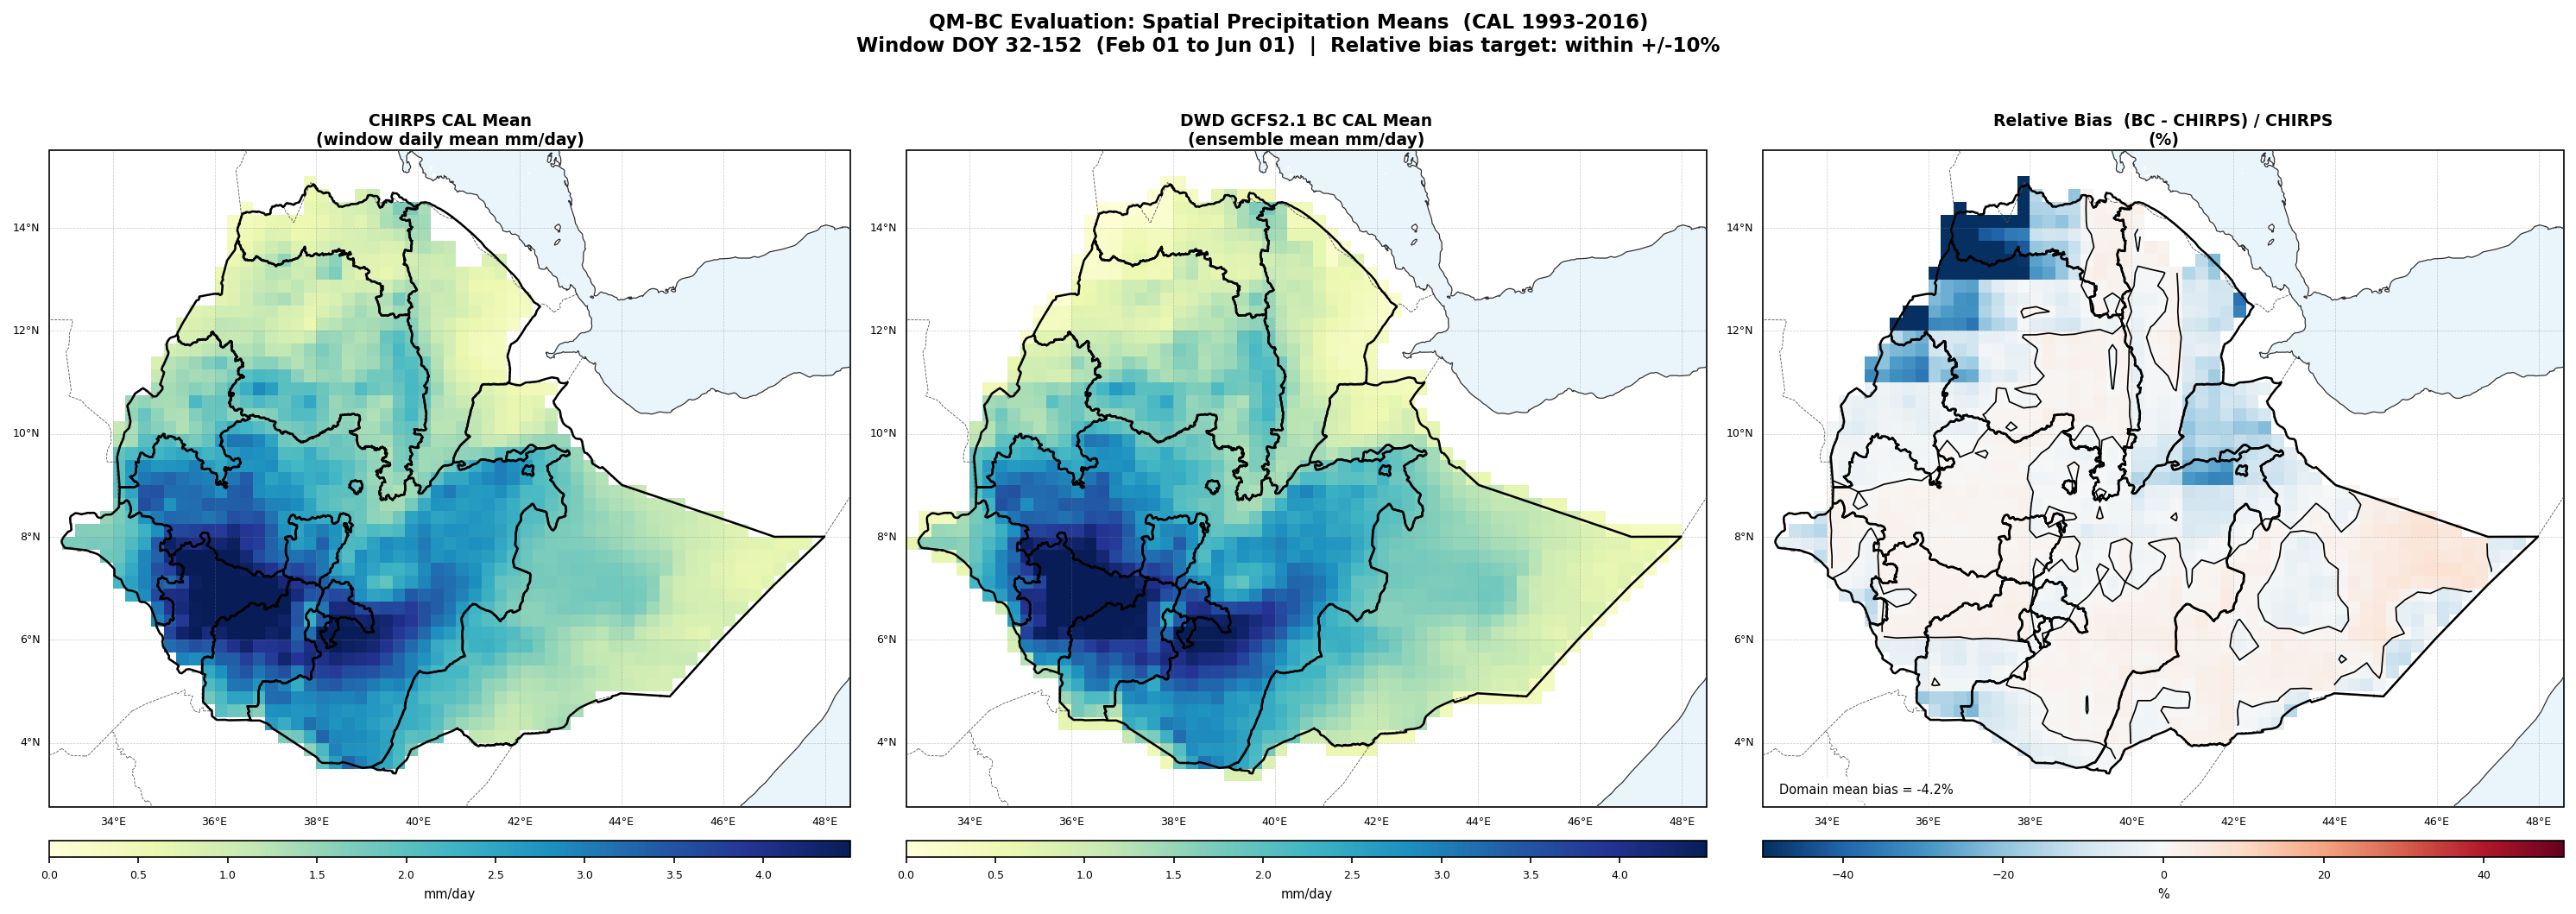

In [50]:
print("\nFig 4: Spatial bias maps ...")

chirps_spatial_mean = np.nanmean(
    chirps_win_clim, axis=0)             # mean over window DOYs
bc_spatial_mean     = np.nanmean(
    bc_ens_mean_clim, axis=0)            # mean over window DOYs
abs_bias            = bc_spatial_mean - chirps_spatial_mean
rel_bias            = np.where(
    chirps_spatial_mean > 0.1,
    100.0 * abs_bias / chirps_spatial_mean, np.nan)

fig4, axes4 = plt.subplots(1, 3, figsize=(20, 7),
                            subplot_kw={"projection": ccrs.PlateCarree()})

vmax_mm = float(np.nanpercentile(chirps_spatial_mean[lm], 97))

# First pass: draw maps and record colorbar info
panel_info = []

for ax, arr, cmap, vmin, vmax, title, cblabel in [
    (axes4[0], chirps_spatial_mean, "YlGnBu",
     0, vmax_mm,
     "CHIRPS CAL Mean\n(window daily mean mm/day)", "mm/day"),
    (axes4[1], bc_spatial_mean,    "YlGnBu",
     0, vmax_mm,
     "DWD GCFS2.1 BC CAL Mean\n(ensemble mean mm/day)",    "mm/day"),
    (axes4[2], rel_bias,           "RdBu_r",
     -50, 50,
     "Relative Bias  (BC - CHIRPS) / CHIRPS\n(%)",   "%"),
]:
    _base_map(ax)
    im = _pcm(ax, arr, cmap, vmin, vmax)
    ax.set_title(title, fontsize=9, pad=3)
    panel_info.append((ax, im, cblabel, title))

    # Zero contour on bias panel
    if "Bias" in title:
        ax.contour(target_lon, target_lat,
                   np.where(lm, rel_bias, np.nan),
                   levels=[0], colors=["black"], linewidths=[0.8],
                   transform=ccrs.PlateCarree(), zorder=5)
        mn_bias = float(np.nanmean(rel_bias[lm]))
        ax.text(0.02, 0.02, f"Domain mean bias = {mn_bias:+.1f}%",
                transform=ax.transAxes, fontsize=7,
                bbox=dict(fc="white", alpha=0.80, lw=0))

# Use the current active window values instead of hard-coded DOYs.
window_line = (
    f"Window DOY {WIN_DOY_START}-{WIN_DOY_END}  "
    f"({WIN_START_DATE.strftime('%b %d')} to {WIN_END_DATE.strftime('%b %d')})  "
    "|  Relative bias target: within +/-10%"
 )
fig4.suptitle(
    "QM-BC Evaluation: Spatial Precipitation Means  (CAL 1993-2016)\n" + window_line,
    fontsize=11, fontweight="bold", y=1.01)

# Apply tight_layout before positioning colorbars so they align with panels
plt.tight_layout(rect=[0, 0.06, 1, 1])

# Second pass: add colorbars using final panel positions
for ax, im, cblabel, title in panel_info:
    pos = ax.get_position()
    cax = fig4.add_axes([pos.x0, pos.y0 - 0.055, pos.width, 0.018])
    cb  = fig4.colorbar(im, cax=cax, orientation="horizontal")
    cb.set_label(cblabel, fontsize=7)
    cb.ax.tick_params(labelsize=6)

_save(fig4, "dwd_fig4_spatial_bias_maps")
plt.show()


## Bias-corrected members

  Saved -> data/processed/seasonal_data/outputs_dwd_v3\plots\stage3B_diagnostics\dwd_fig5_bc_individual_members_spatial.png


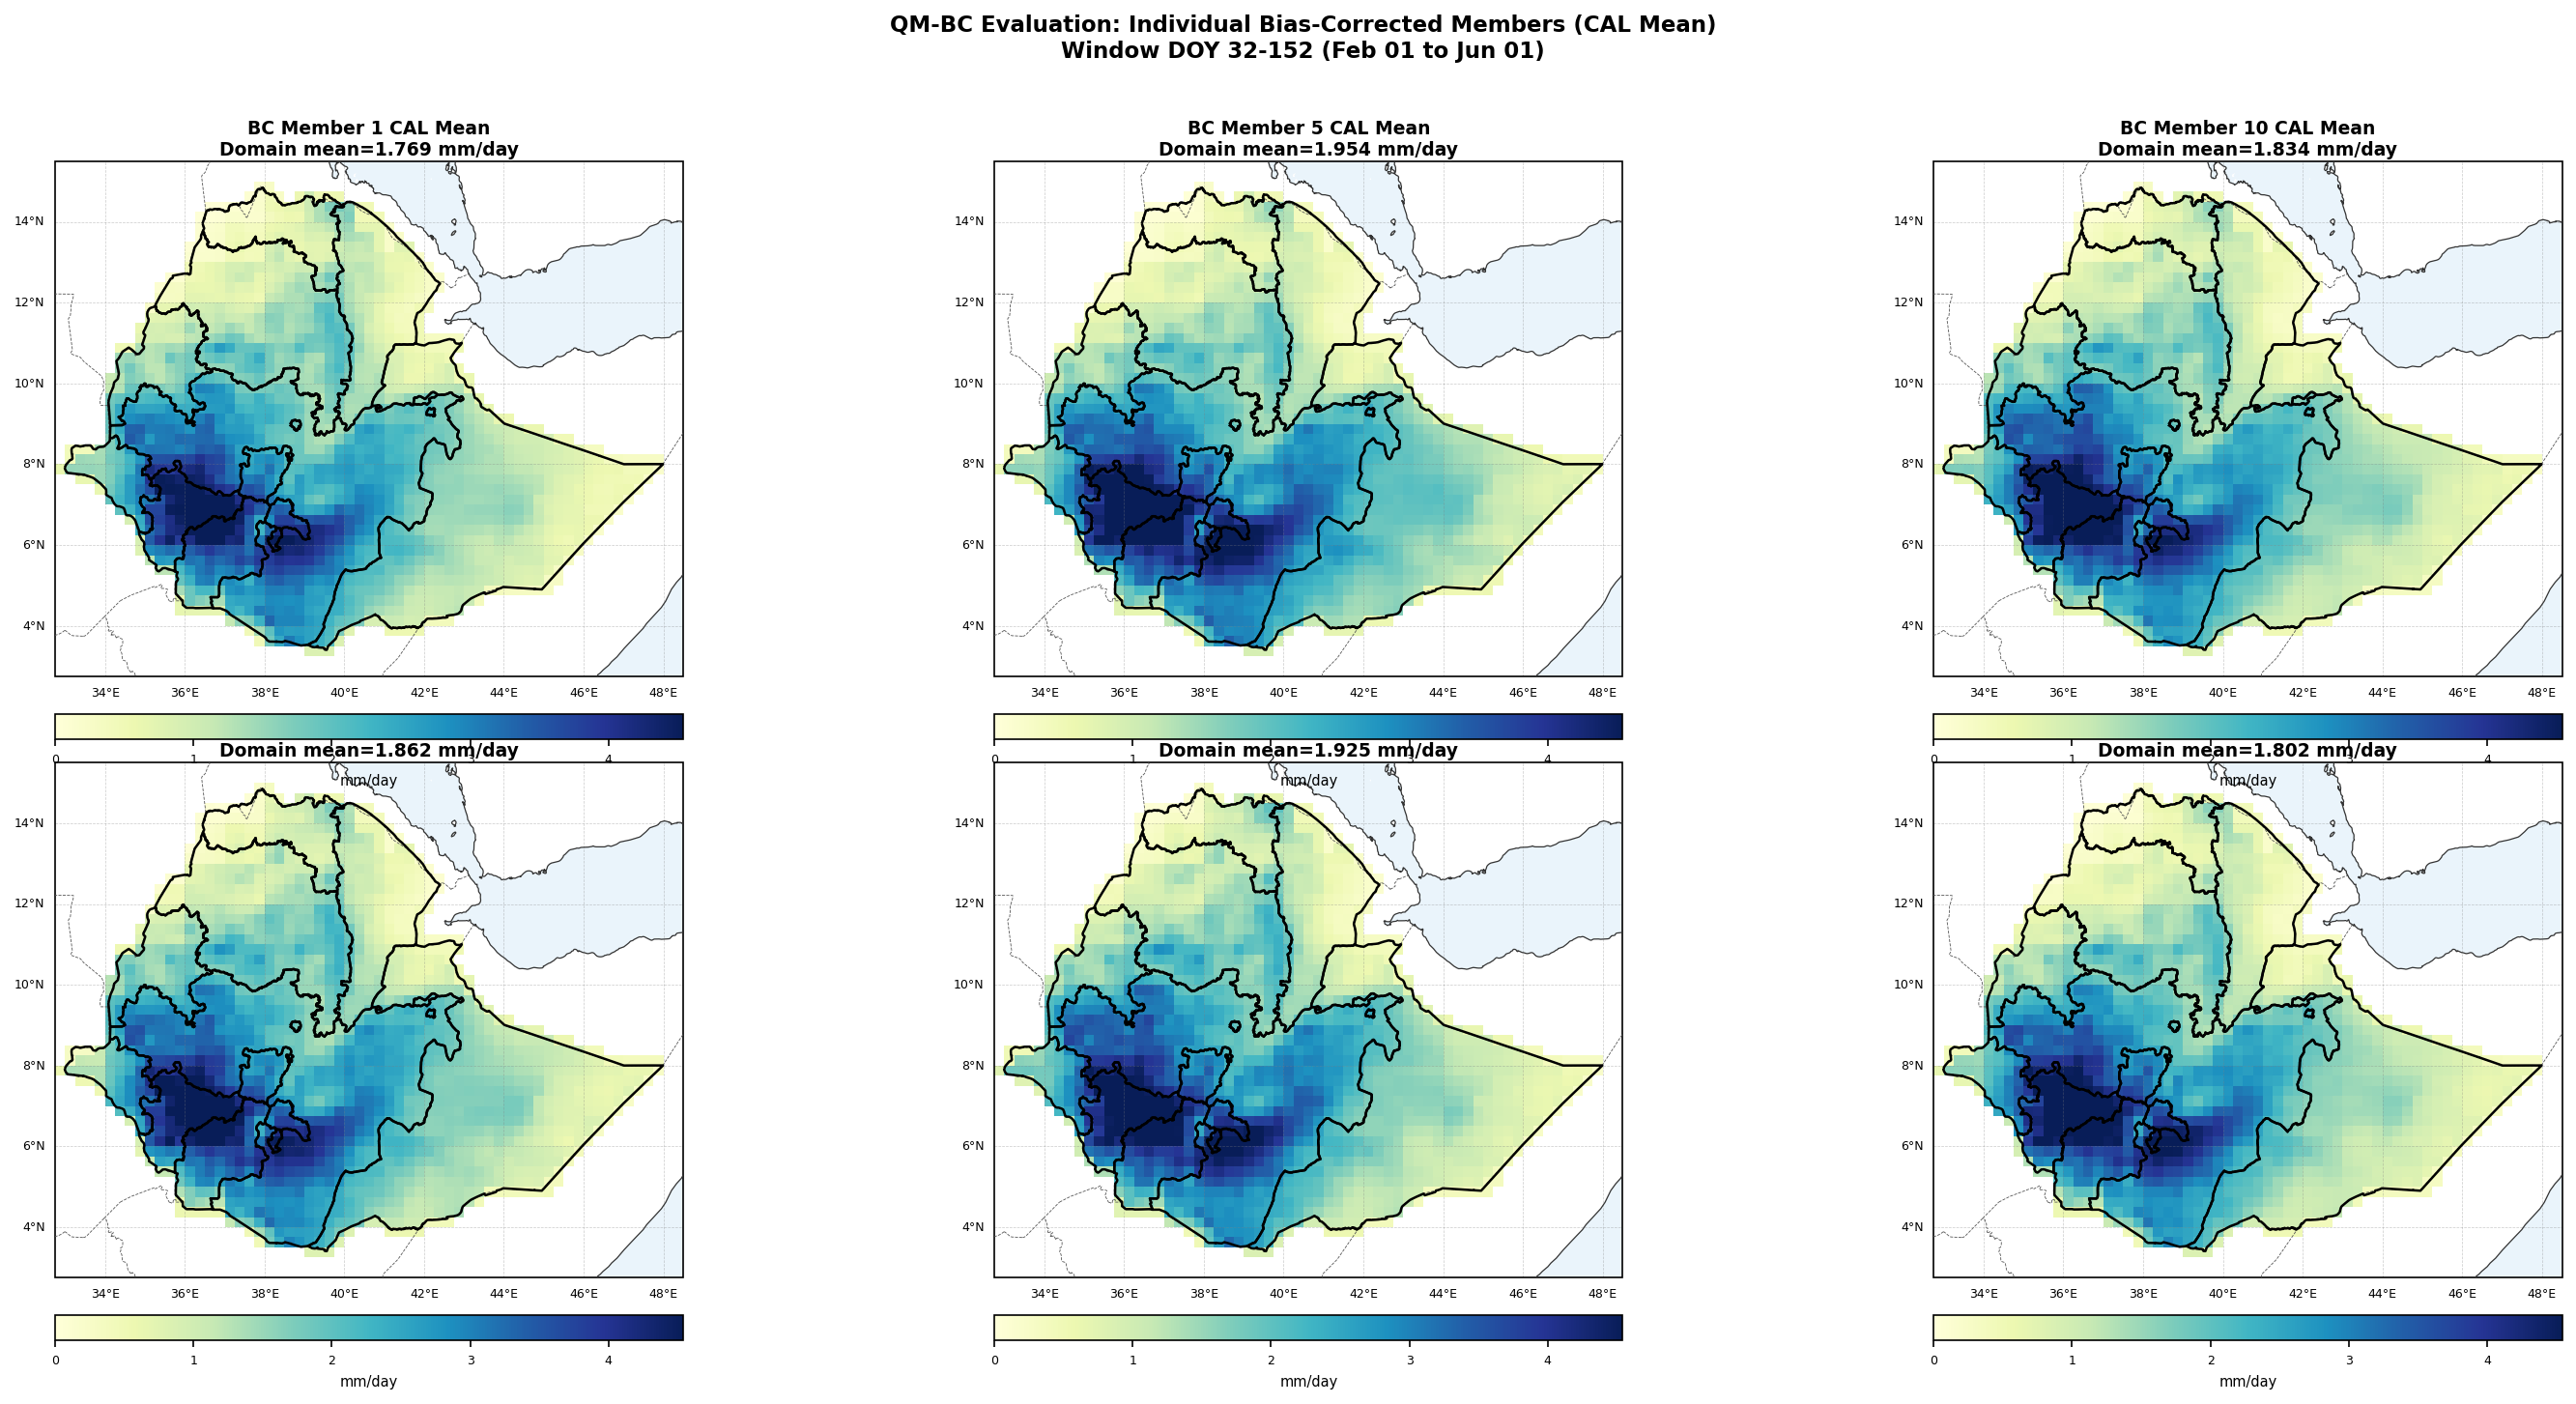

In [51]:
# Ensure we have CAL-year mask for DWD years.
if "cal_mask_dwd" in globals():
    _cal_mask = cal_mask_dwd
else:
    _cal_mask = np.isin(dwd_years, CAL_YEARS)

# Select a spread of members across the ensemble.
n_members_total = dwd_bc.shape[0]
req_members_1based = [1, 5, 10, 15, 20, 30]
member_idx = sorted({m - 1 for m in req_members_1based if 1 <= m <= n_members_total})

# Fallback for smaller ensembles.
if len(member_idx) == 0:
    member_idx = list(range(min(6, n_members_total)))

# CAL seasonal mean map for each selected member.
member_maps = []
for mi in member_idx:
    m_map = np.nanmean(dwd_bc[mi, _cal_mask, :, :, :], axis=(0, 1))
    m_map = np.where(lm, m_map, np.nan)
    member_maps.append(m_map)

# Shared color scale for comparability.
all_vals = np.concatenate([m[np.isfinite(m)] for m in member_maps if np.isfinite(m).any()])
vmax = float(np.nanpercentile(all_vals, 97)) if all_vals.size else 5.0

ncols = 3
nrows = int(np.ceil(len(member_maps) / ncols))
figm, axes = plt.subplots(
    nrows, ncols, figsize=(6.6 * ncols, 4.8 * nrows),
    subplot_kw={"projection": ccrs.PlateCarree()}
 )
axes = np.atleast_1d(axes).ravel()

# First pass: draw maps only, then colorbars after layout is finalized.
panel_info = []
for ax, mi, m_map in zip(axes, member_idx, member_maps):
    _base_map(ax)
    im = _pcm(ax, m_map, "YlGnBu", 0, vmax)
    domain_mean = float(np.nanmean(m_map[lm]))
    ax.set_title(
        f"BC Member {mi + 1} CAL Mean\nDomain mean={domain_mean:.3f} mm/day",
        fontsize=9, pad=3
    )
    panel_info.append((ax, im))

# Hide any unused panels.
for ax in axes[len(member_maps):]:
    ax.set_visible(False)

figm.suptitle(
    "QM-BC Evaluation: Individual Bias-Corrected Members (CAL Mean)\n"
    f"Window DOY {WIN_DOY_START}-{WIN_DOY_END} ({WIN_START_DATE.strftime('%b %d')} to {WIN_END_DATE.strftime('%b %d')})",
    fontsize=11, fontweight="bold", y=1.01
 )

# Apply layout first so colorbars can be aligned to final panel positions.
plt.tight_layout(rect=[0, 0.07, 1, 1])

# Second pass: add aligned colorbars with consistent spacing below each panel.
for ax, im in panel_info:
    pos = ax.get_position()
    cax = figm.add_axes([pos.x0, pos.y0 - 0.045, pos.width, 0.018])
    cb = figm.colorbar(im, cax=cax, orientation="horizontal")
    cb.set_label("mm/day", fontsize=7)
    cb.ax.tick_params(labelsize=6)

_save(figm, "dwd_fig5_bc_individual_members_spatial")
plt.show()

## Member Anomaly Maps

- member minus ensemble mean for each selected member.

- This shows spatial spread patterns much more clearly than absolute maps.


Fig 6: Member anomaly maps (BC member - BC ensemble mean) ...
  Saved -> data/processed/seasonal_data/outputs_dwd_v3\plots\stage3B_diagnostics\dwd_fig6_bc_member_anomaly_maps.png


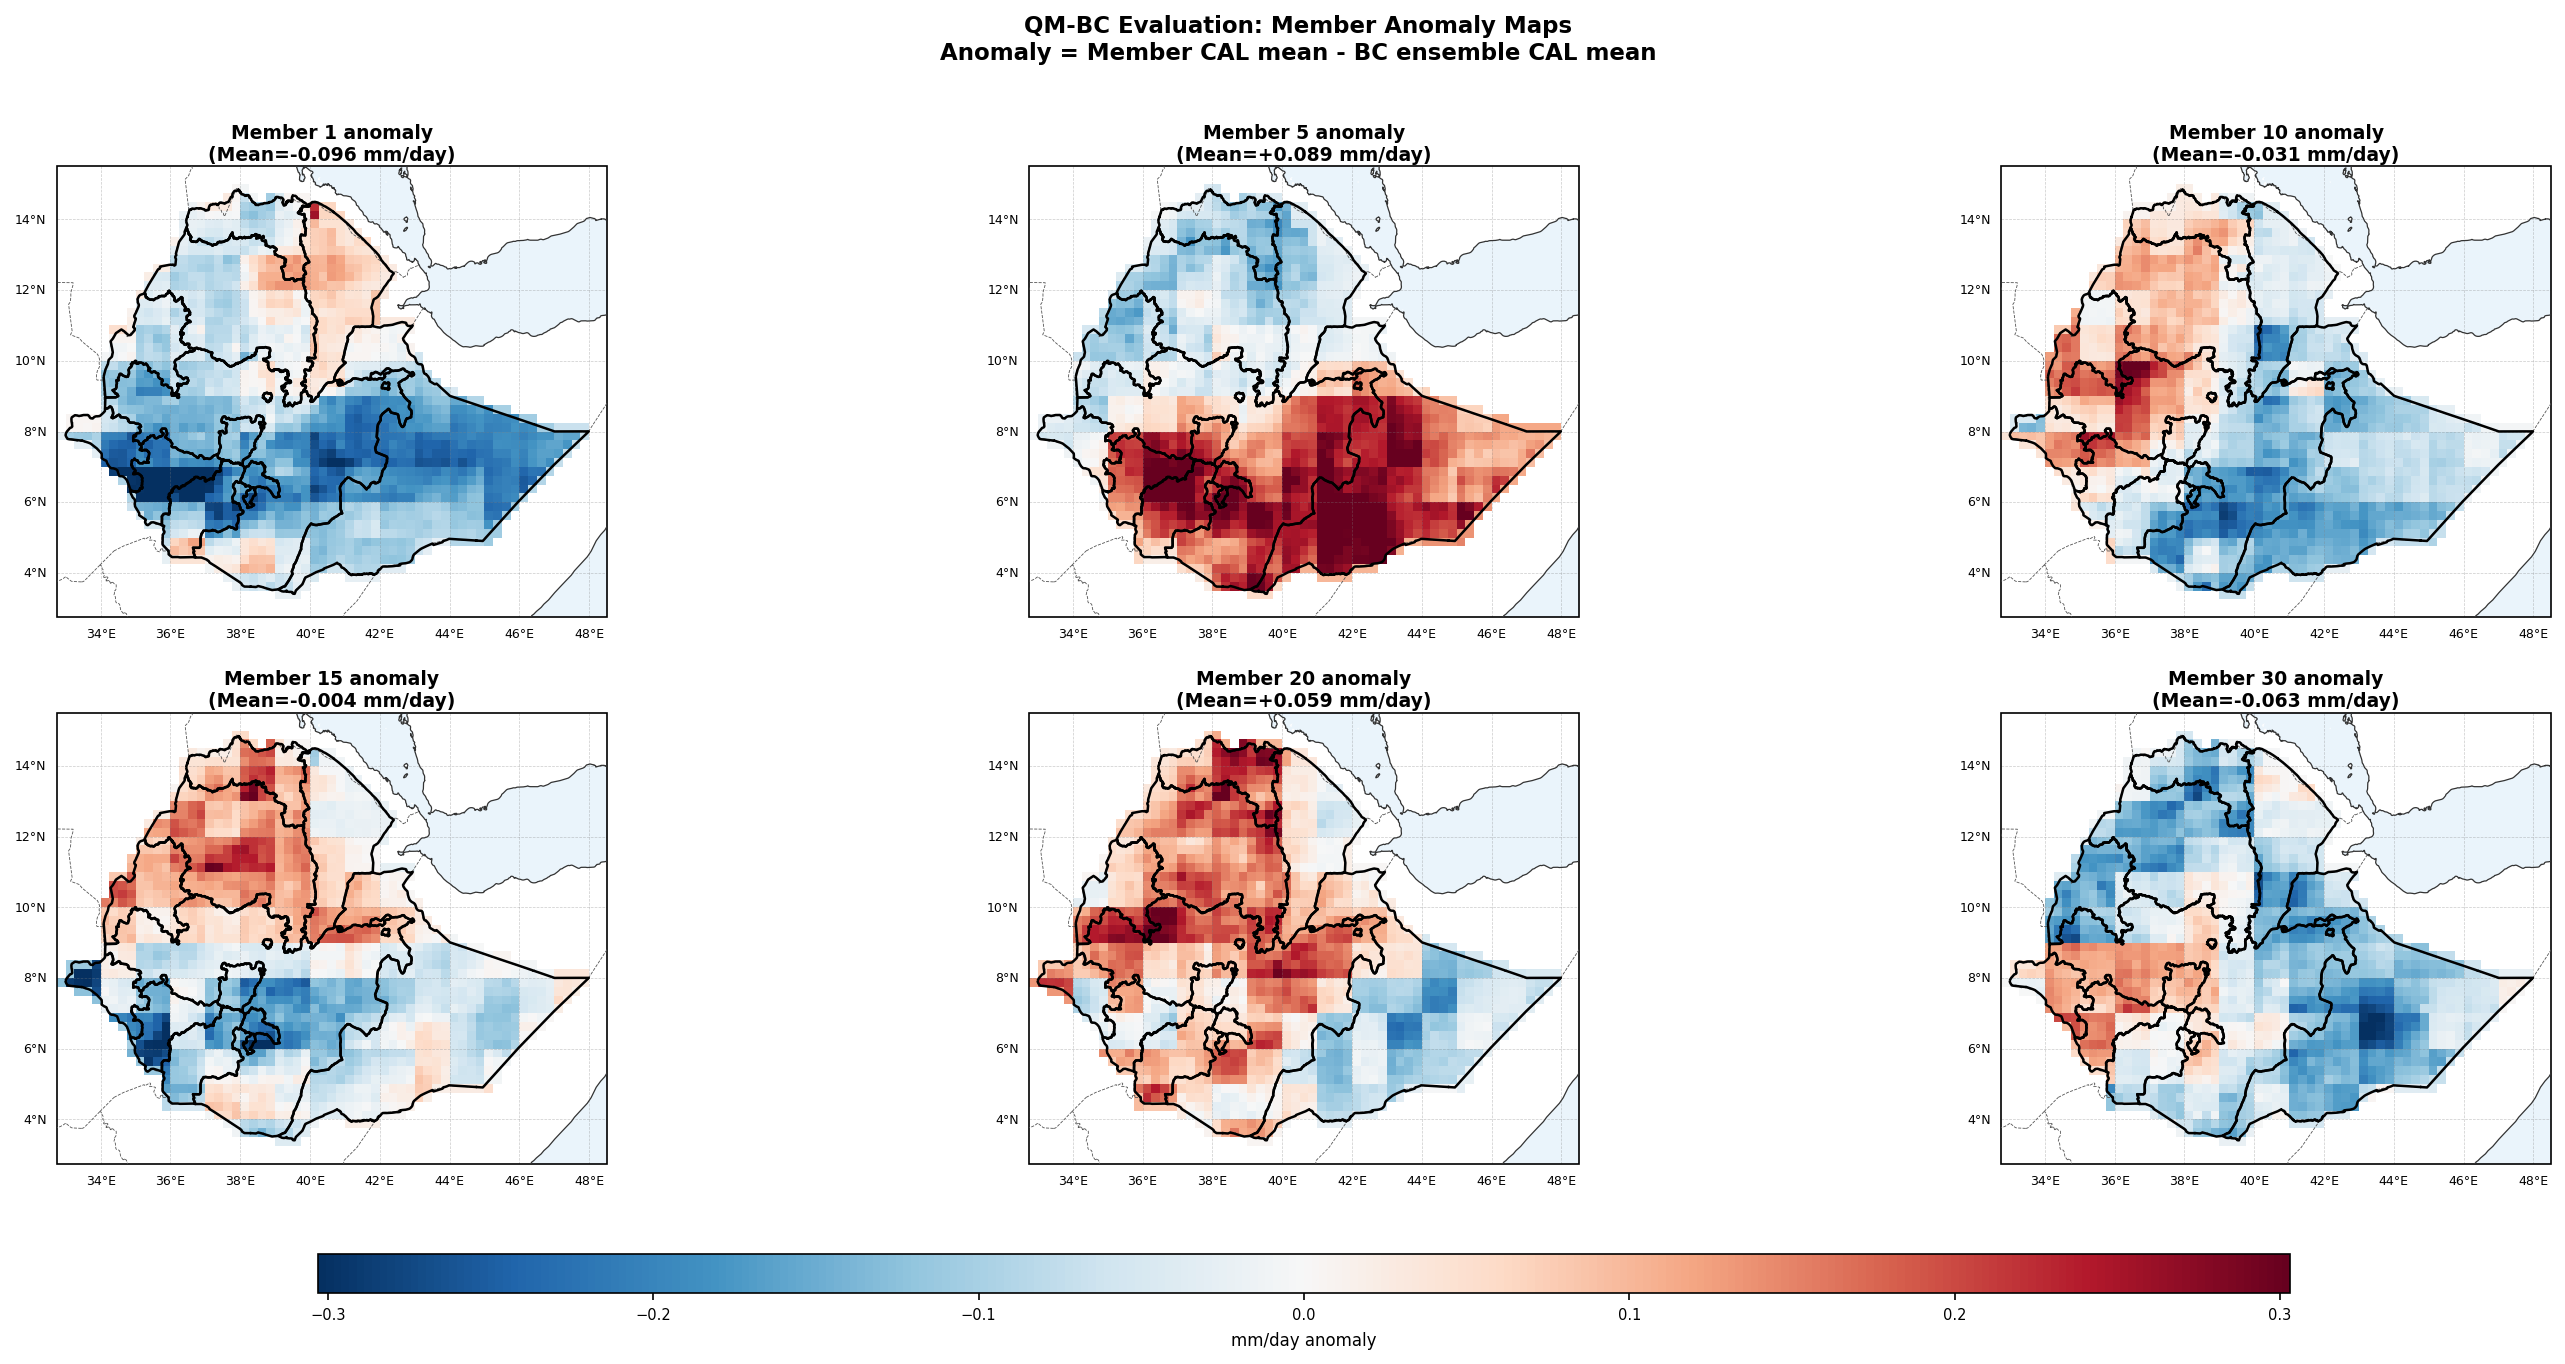

In [52]:
print("\nFig 6: Member anomaly maps (BC member - BC ensemble mean) ...")

# Ensure we have CAL-year mask for DWD years.
if "cal_mask_dwd" in globals():
    _cal_mask = cal_mask_dwd
else:
    _cal_mask = np.isin(dwd_years, CAL_YEARS)

# Select representative members across ensemble.
n_members_total = dwd_bc.shape[0]
req_members_1based = [1, 5, 10, 15, 20, 30]
member_idx = sorted({m - 1 for m in req_members_1based if 1 <= m <= n_members_total})
if len(member_idx) == 0:
    member_idx = list(range(min(6, n_members_total)))

# Ensemble reference map for anomalies (CAL mean).
if "bc_spatial_mean" in globals():
    ens_map = bc_spatial_mean.astype(np.float64)
else:
    ens_map = np.nanmean(np.nanmean(dwd_bc[:, _cal_mask, :, :, :], axis=0), axis=0).astype(np.float64)
ens_map = np.where(lm, ens_map, np.nan)

# Build anomaly maps: member CAL mean - ensemble CAL mean.
anom_maps = []
for mi in member_idx:
    m_map = np.nanmean(dwd_bc[mi, _cal_mask, :, :, :], axis=(0, 1)).astype(np.float64)
    m_map = np.where(lm, m_map, np.nan)
    anom_maps.append(m_map - ens_map)

# Symmetric color scale centered at zero.
all_anom = np.concatenate([a[np.isfinite(a)] for a in anom_maps if np.isfinite(a).any()])
vabs = float(np.nanpercentile(np.abs(all_anom), 98)) if all_anom.size else 0.5
vabs = max(vabs, 0.1)

ncols = 3
nrows = int(np.ceil(len(anom_maps) / ncols))
figa, axes = plt.subplots(
    nrows, ncols, figsize=(6.6 * ncols, 4.8 * nrows),
    subplot_kw={"projection": ccrs.PlateCarree()}
 )
axes = np.atleast_1d(axes).ravel()

last_im = None
for ax, mi, amap in zip(axes, member_idx, anom_maps):
    _base_map(ax)
    last_im = _pcm(ax, amap, "RdBu_r", -vabs, vabs)
    dmean = float(np.nanmean(amap[lm]))
    ax.set_title(
        f"Member {mi + 1} anomaly\n(Mean={dmean:+.3f} mm/day)",
        fontsize=9, pad=3
    )

# Hide unused axes.
for ax in axes[len(anom_maps):]:
    ax.set_visible(False)

figa.suptitle(
    "QM-BC Evaluation: Member Anomaly Maps\n"
    "Anomaly = Member CAL mean - BC ensemble CAL mean",
    fontsize=11, fontweight="bold", y=1.01
 )

# Reserve bottom area for one shared colorbar to avoid row overlap.
plt.tight_layout(rect=[0, 0.09, 1, 1], h_pad=2.0)

if last_im is not None:
    cbar = figa.colorbar(last_im, ax=[ax for ax in axes[:len(anom_maps)]],
                         orientation="horizontal", fraction=0.035, pad=0.08, aspect=50)
    cbar.set_label("mm/day anomaly", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

_save(figa, "dwd_fig6_bc_member_anomaly_maps")
plt.show()

## Improvement map (before vs after)

- absolute error raw minus absolute error BC relative to CHIRPS.

- Positive values mean BC improved that grid cell; negative means it got worse.



Fig 7: Improvement map (before vs after) ...
  Domain mean |raw-CHIRPS| : 0.924 mm/day
  Domain mean |bc-CHIRPS|  : 0.082 mm/day
  Mean improvement         : +0.841 mm/day
  Pixels improved          : 91.3%
  Saved -> data/processed/seasonal_data/outputs_dwd_v3\plots\stage3B_diagnostics\dwd_fig7_improvement_map_before_after.png


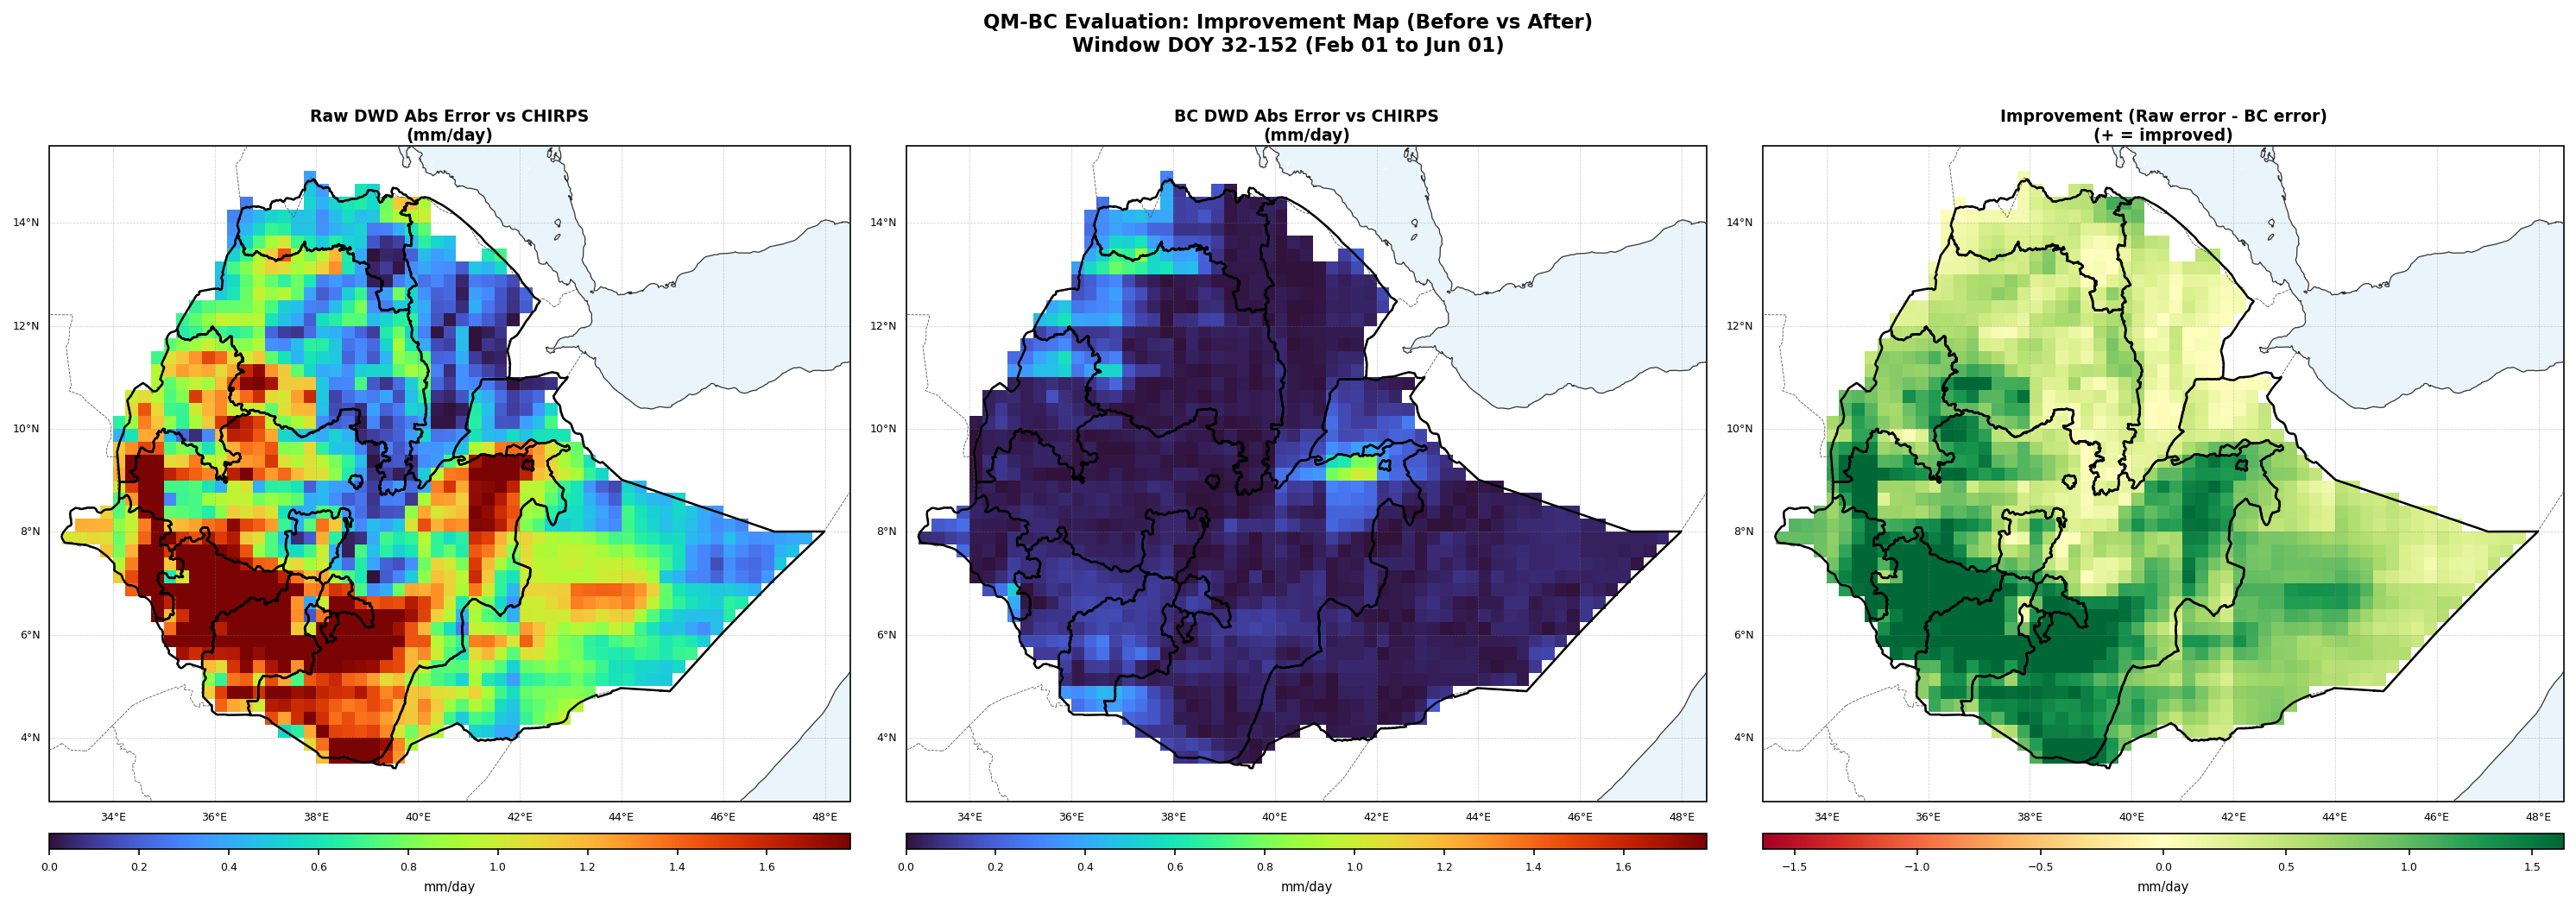

In [53]:
print("\nFig 7: Improvement map (before vs after) ...")

# CAL mask on DWD years.
if "cal_mask_dwd" in globals():
    _cal_mask = cal_mask_dwd
else:
    _cal_mask = np.isin(dwd_years, CAL_YEARS)

# Build a raw (uncorrected) DWD field on target grid for fair comparison.
raw_on_target = None
if "dwd_rg" in globals() and dwd_rg is not None:
    raw_on_target = dwd_rg
elif "dwd_raw" in globals() and dwd_raw is not None and dwd_raw.shape[-2:] == (len(target_lat), len(target_lon)):
    raw_on_target = dwd_raw
elif "dwd_raw_native" in globals() and dwd_raw_native is not None:
    if dwd_raw_native.shape[-2:] == (len(target_lat), len(target_lon)):
        raw_on_target = dwd_raw_native
    elif "_dwd_lat" in globals() and "_dwd_lon" in globals():
        lat_idx = np.array([int(np.argmin(np.abs(_dwd_lat - lt))) for lt in target_lat], dtype=int)
        lon_idx = np.array([int(np.argmin(np.abs(_dwd_lon - ln))) for ln in target_lon], dtype=int)
        raw_on_target = np.full(
            (dwd_raw_native.shape[0], dwd_raw_native.shape[1], dwd_raw_native.shape[2], len(target_lat), len(target_lon)),
            np.nan, dtype=np.float32
        )
        for yi in range(dwd_raw_native.shape[1]):
            blk = dwd_raw_native[:, yi, :, :, :]
            blk = blk[:, :, lat_idx, :]
            blk = blk[:, :, :, lon_idx]
            raw_on_target[:, yi, :, :, :] = blk
    else:
        raise NameError("Need native DWD coordinates (_dwd_lat/_dwd_lon) to regrid raw field. Rerun Stage 1B if needed.")
else:
    raise NameError("No raw DWD field available. Rerun Stage 1B/2B before this plot.")

# Apply land mask.
raw_on_target = np.where(lm[None, None, None, :, :], raw_on_target, np.nan)

# Mean over CAL years and ensemble members for raw and BC.
raw_ens_mean_clim = np.nanmean(raw_on_target[:, _cal_mask, :, :, :], axis=(0, 1))  # (day, lat, lon)
bc_ens_mean_clim_local = np.nanmean(dwd_bc[:, _cal_mask, :, :, :], axis=(0, 1))    # (day, lat, lon)

# CHIRPS window mean over day.
chirps_spatial_mean_local = np.nanmean(chirps_win_clim, axis=0)
raw_spatial_mean = np.nanmean(raw_ens_mean_clim, axis=0)
bc_spatial_mean_local = np.nanmean(bc_ens_mean_clim_local, axis=0)

# Absolute errors against CHIRPS and improvement after BC.
abs_err_raw = np.abs(raw_spatial_mean - chirps_spatial_mean_local)
abs_err_bc = np.abs(bc_spatial_mean_local - chirps_spatial_mean_local)
improve = abs_err_raw - abs_err_bc  # >0 means BC improved error

# Summary metrics.
raw_mae_domain = float(np.nanmean(abs_err_raw[lm]))
bc_mae_domain = float(np.nanmean(abs_err_bc[lm]))
gain_domain = float(np.nanmean(improve[lm]))
improved_frac = float(np.nanmean((improve[lm] > 0).astype(float)) * 100.0)

print(f"  Domain mean |raw-CHIRPS| : {raw_mae_domain:.3f} mm/day")
print(f"  Domain mean |bc-CHIRPS|  : {bc_mae_domain:.3f} mm/day")
print(f"  Mean improvement         : {gain_domain:+.3f} mm/day")
print(f"  Pixels improved          : {improved_frac:.1f}%")

fig7, axes7 = plt.subplots(
    1, 3, figsize=(20, 7), subplot_kw={"projection": ccrs.PlateCarree()}
 )

# Scale choices: tighten ranges and use higher-contrast palettes for readability.
vmax_err = float(np.nanpercentile(np.concatenate([abs_err_raw[lm], abs_err_bc[lm]]), 95))
vmax_imp = float(np.nanpercentile(np.abs(improve[lm]), 90))
vmax_imp = max(vmax_imp, 0.20)

panel_info = []
for ax, arr, cmap, vmin, vmax, title, cblabel in [
    (axes7[0], abs_err_raw, "turbo", 0, vmax_err, "Raw DWD Abs Error vs CHIRPS\n(mm/day)", "mm/day"),
    (axes7[1], abs_err_bc, "turbo", 0, vmax_err, "BC DWD Abs Error vs CHIRPS\n(mm/day)", "mm/day"),
    (axes7[2], improve, "RdYlGn", -vmax_imp, vmax_imp, "Improvement (Raw error - BC error)\n(+ = improved)", "mm/day"),
]:
    _base_map(ax)
    im = _pcm(ax, arr, cmap, vmin, vmax)
    ax.set_title(title, fontsize=9, pad=3)
    panel_info.append((ax, im, cblabel))

fig7.suptitle(
    "QM-BC Evaluation: Improvement Map (Before vs After)\n"
    f"Window DOY {WIN_DOY_START}-{WIN_DOY_END} ({WIN_START_DATE.strftime('%b %d')} to {WIN_END_DATE.strftime('%b %d')})",
    fontsize=11, fontweight="bold", y=1.01
 )

plt.tight_layout(rect=[0, 0.07, 1, 1])

for ax, im, cblabel in panel_info:
    pos = ax.get_position()
    cax = fig7.add_axes([pos.x0, pos.y0 - 0.052, pos.width, 0.017])
    cb = fig7.colorbar(im, cax=cax, orientation="horizontal")
    cb.set_label(cblabel, fontsize=7)
    cb.ax.tick_params(labelsize=6)

_save(fig7, "dwd_fig7_improvement_map_before_after")
plt.show()

## Time series spaghetti at a few key sites:

- all BC members plus CHIRPS and ensemble mean.

- Good for seeing temporal coherence and member spread day by day.


Fig 10: Site time-series spaghetti ...
  Saved -> data/processed/seasonal_data/outputs_dwd_v3\plots\stage3B_diagnostics\dwd_fig10_site_spaghetti.png


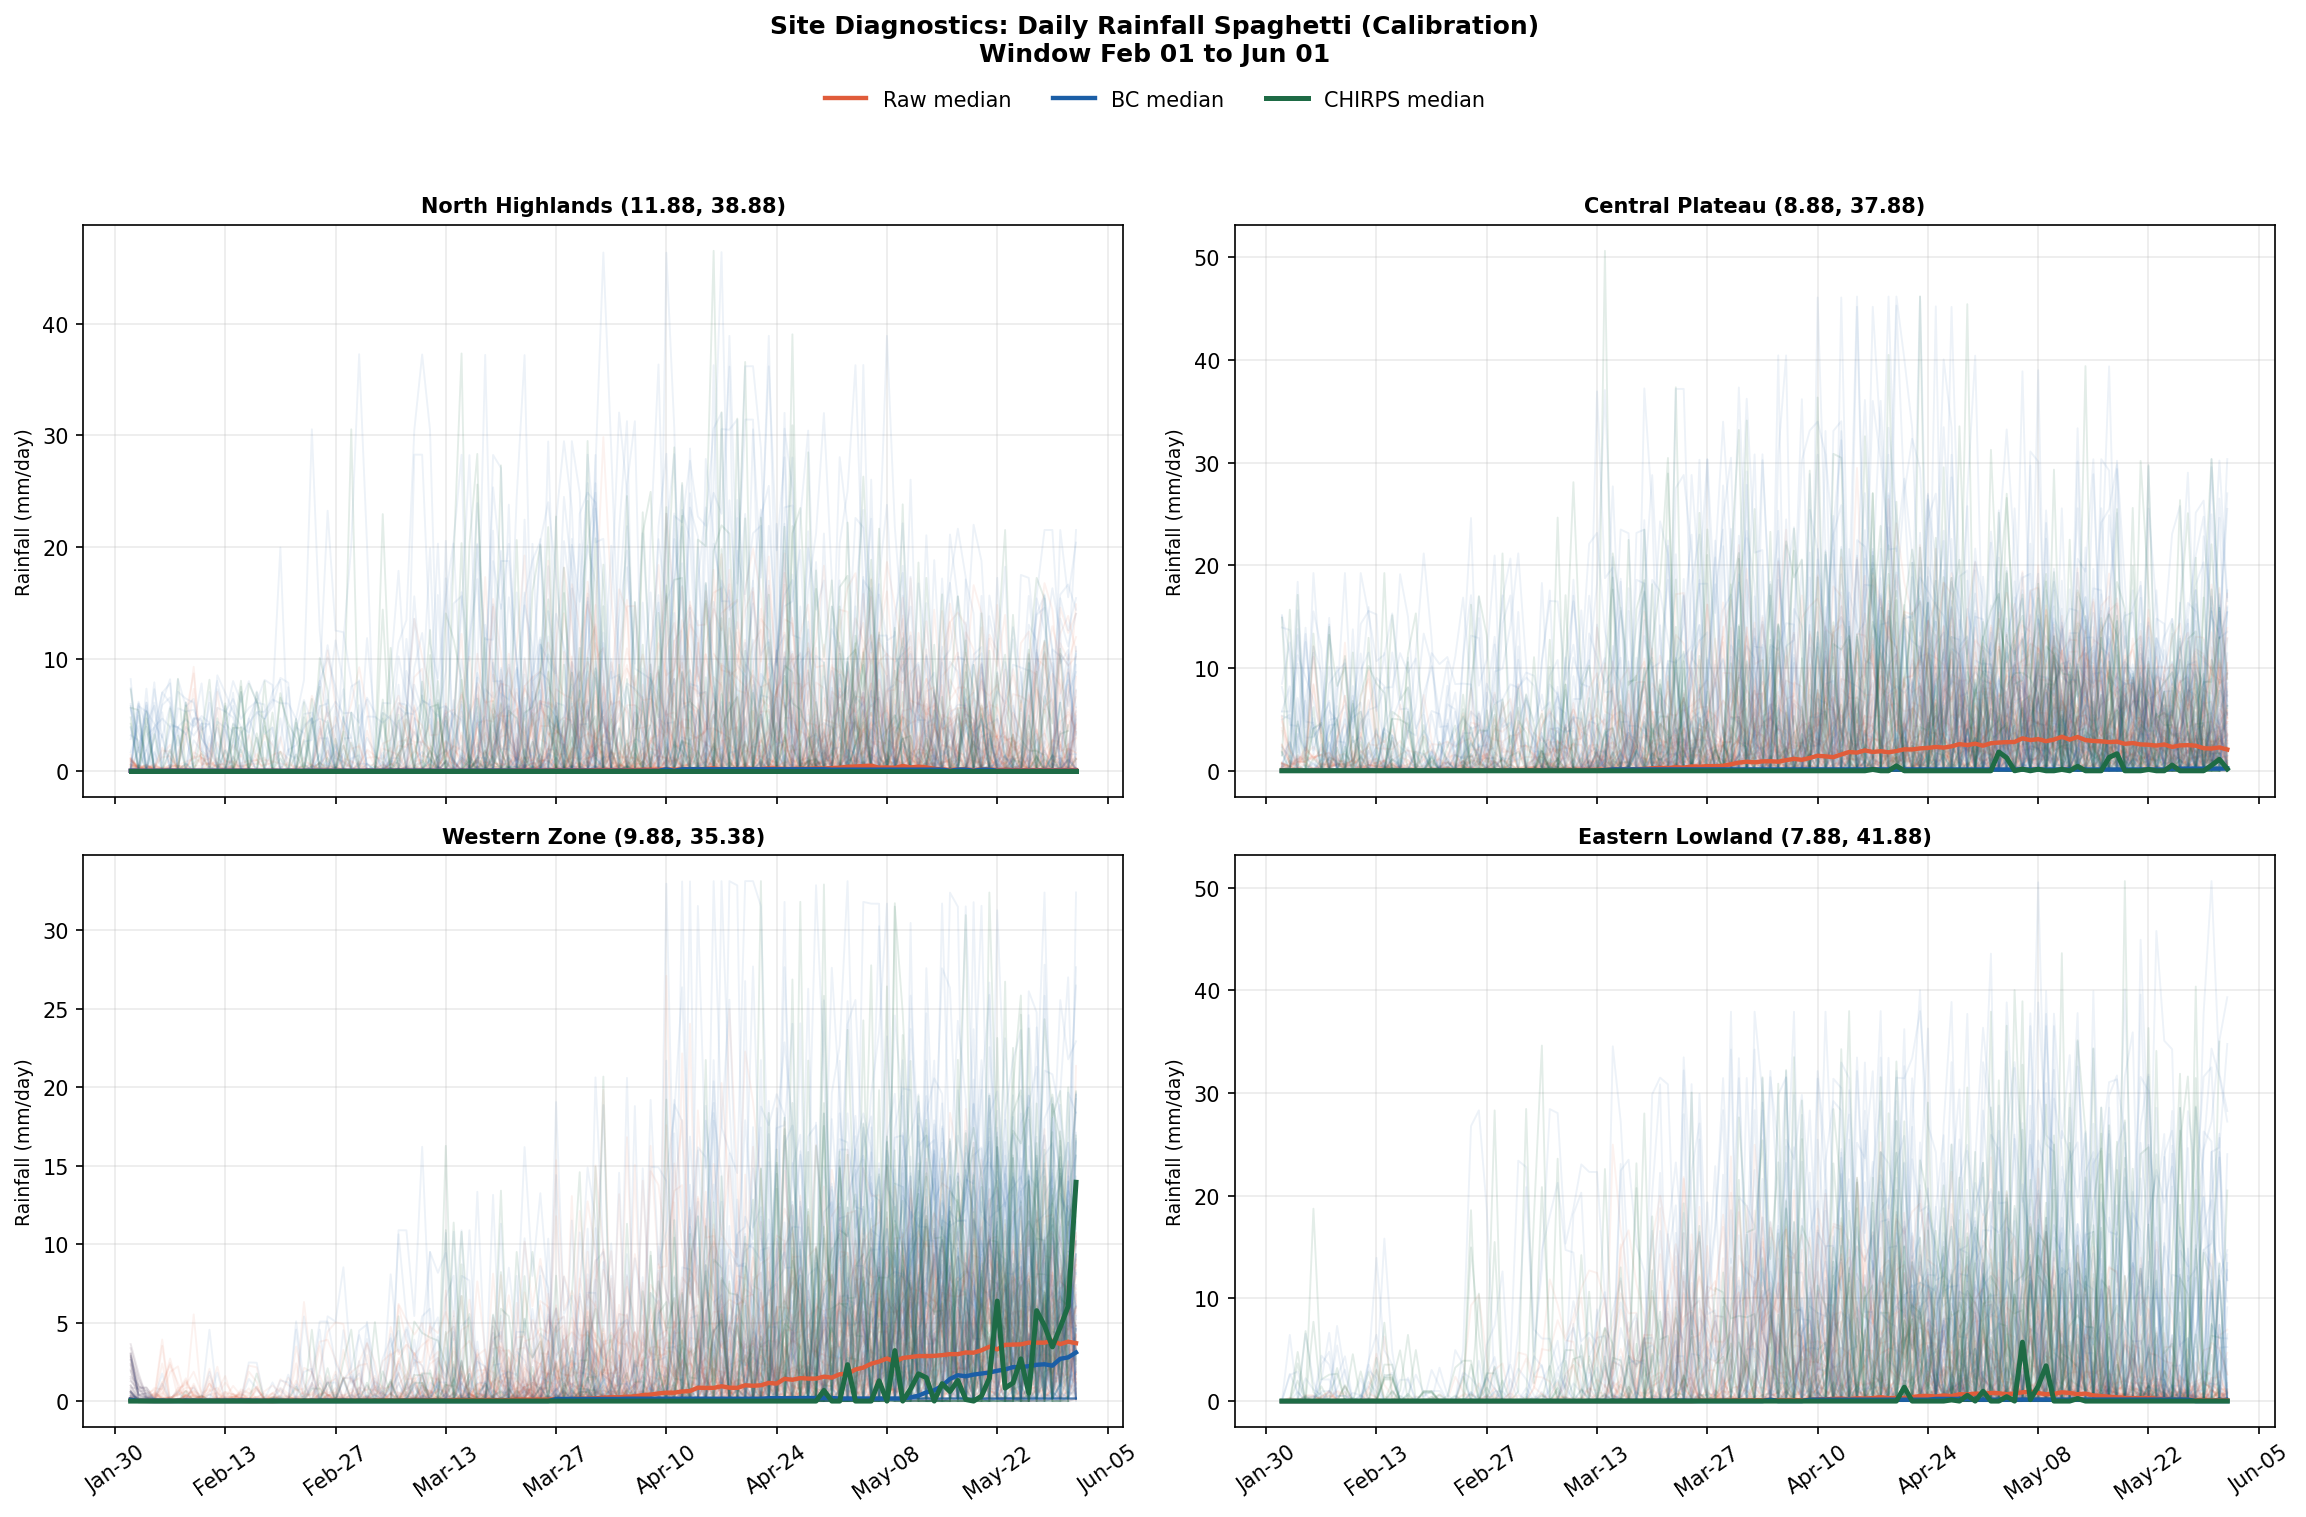

  Saved -> data/processed/seasonal_data/outputs_dwd_v3\plots\diagnostics\dwd_fig10_site_spaghetti.png


In [54]:
print("\nFig 10: Site time-series spaghetti ...")

import datetime as _dt
import matplotlib.dates as mdates

# Calibration masks
if "cal_mask_dwd" in globals():
    _cal_mask_dwd = cal_mask_dwd
else:
    _cal_mask_dwd = np.isin(dwd_years, CAL_YEARS)

if "cal_mask_c" in globals():
    _cal_mask_chirps = cal_mask_c
else:
    _cal_mask_chirps = np.isin(chirps_years, CAL_YEARS)

# Build/recover raw field on target grid
_raw_target = None
if "dwd_rg" in globals() and dwd_rg is not None:
    _raw_target = dwd_rg
elif "dwd_raw" in globals() and dwd_raw is not None and dwd_raw.shape[-2:] == (len(target_lat), len(target_lon)):
    _raw_target = dwd_raw
elif "raw_on_target" in globals() and raw_on_target is not None:
    _raw_target = raw_on_target
elif "dwd_raw_native" in globals() and dwd_raw_native is not None and "_dwd_lat" in globals() and "_dwd_lon" in globals():
    lat_idx = np.array([int(np.argmin(np.abs(_dwd_lat - lt))) for lt in target_lat], dtype=int)
    lon_idx = np.array([int(np.argmin(np.abs(_dwd_lon - ln))) for ln in target_lon], dtype=int)
    _raw_target = np.full(
        (dwd_raw_native.shape[0], dwd_raw_native.shape[1], dwd_raw_native.shape[2], len(target_lat), len(target_lon)),
        np.nan, dtype=np.float32
    )
    for yi in range(dwd_raw_native.shape[1]):
        blk = dwd_raw_native[:, yi, :, :, :]
        blk = blk[:, :, lat_idx, :]
        blk = blk[:, :, :, lon_idx]
        _raw_target[:, yi, :, :, :] = blk
else:
    raise NameError("Raw DWD field is not available. Run Stage 1B/2B first.")

_raw_target = np.where(lm[None, None, None, :, :], _raw_target, np.nan)
_bc_target = np.where(lm[None, None, None, :, :], dwd_bc, np.nan)

def _parse_sites(site_obj):
    out = []
    if not isinstance(site_obj, (list, tuple)):
        return out
    for s in site_obj:
        name, lat, lon = None, None, None
        if isinstance(s, dict):
            name = s.get("name") or s.get("site") or s.get("label") or s.get("city")
            lat = s.get("lat") or s.get("latitude") or s.get("y")
            lon = s.get("lon") or s.get("longitude") or s.get("x")
        elif isinstance(s, (tuple, list)) and len(s) >= 2:
            if len(s) >= 3 and isinstance(s[0], str):
                name, lat, lon = s[0], s[1], s[2]
            elif len(s) >= 3 and isinstance(s[2], str):
                lat, lon, name = s[0], s[1], s[2]
            else:
                lat, lon = s[0], s[1]
                name = f"Site {len(out)+1}"
        try:
            lat = float(lat)
            lon = float(lon)
        except Exception:
            continue
        if name is None:
            name = f"Site {len(out)+1}"
        out.append((str(name), lat, lon))
    return out

site_candidates = _parse_sites(SITES if "SITES" in globals() else [])
if len(site_candidates) < 3:
    site_candidates = [
        ("Addis Ababa", 8.98, 38.79),
        ("Bahir Dar", 11.59, 37.39),
        ("Dire Dawa", 9.60, 41.86),
        ("Hawassa", 7.06, 38.47),
    ]

site_candidates = site_candidates[:4]
n_sites = len(site_candidates)

def _extract_window(arr):
    # Accept both full-year day axis and already windowed day axis.
    nday = arr.shape[2]
    if nday == len(WIN_DOYS):
        return arr
    max_d = int(np.max(WIN_DOYS))
    if nday >= max_d:
        return arr[:, :, WIN_DOYS - 1, :, :]
    # Fallback: clip to available span to avoid hard failure.
    return arr[:, :, :min(nday, len(WIN_DOYS)), :, :]

raw_win = _extract_window(_raw_target)
bc_win = _extract_window(_bc_target)

if da_chirps_daily.shape[1] == len(WIN_DOYS):
    chirps_win = da_chirps_daily
else:
    chirps_win = da_chirps_daily[:, WIN_DOYS - 1, :, :]

# Harmonize day length across sources
n_day_plot = min(raw_win.shape[2], bc_win.shape[2], chirps_win.shape[1])
raw_win = raw_win[:, :, :n_day_plot, :, :]
bc_win = bc_win[:, :, :n_day_plot, :, :]
chirps_win = chirps_win[:, :n_day_plot, :, :]

# Build x-axis as actual dates (dummy calendar year for plotting)
_ref_year = 2001
x_dates = pd.to_datetime([_dt.date(_ref_year, 1, 1) + _dt.timedelta(days=int(d)-1) for d in WIN_DOYS[:n_day_plot]])

def _spaghetti_series(arr_5d, year_mask, i, j):
    # arr_5d: (member, year, day, lat, lon) -> flatten member-year realizations
    vals = arr_5d[:, year_mask, :, i, j]
    vals = np.transpose(vals, (1, 0, 2)).reshape(-1, arr_5d.shape[2])
    return vals

fig10, axes10 = plt.subplots(2, 2, figsize=(15.5, 9.5), sharex=True)
axes10 = np.atleast_1d(axes10).ravel()

for si, (sname, slat, slon) in enumerate(site_candidates):
    ax = axes10[si]
    i = int(np.argmin(np.abs(target_lat - slat)))
    j = int(np.argmin(np.abs(target_lon - slon)))

    raw_spag = _spaghetti_series(raw_win, _cal_mask_dwd, i, j)
    bc_spag = _spaghetti_series(bc_win, _cal_mask_dwd, i, j)
    ch_spag = chirps_win[_cal_mask_chirps][:, :, i, j]

    # Keep finite rows
    raw_spag = raw_spag[np.any(np.isfinite(raw_spag), axis=1)]
    bc_spag = bc_spag[np.any(np.isfinite(bc_spag), axis=1)]
    ch_spag = ch_spag[np.any(np.isfinite(ch_spag), axis=1)]

    # Downsample if too many lines for readability
    max_lines = 90
    if raw_spag.shape[0] > max_lines:
        idx = np.linspace(0, raw_spag.shape[0] - 1, max_lines, dtype=int)
        raw_plot = raw_spag[idx]
    else:
        raw_plot = raw_spag
    if bc_spag.shape[0] > max_lines:
        idx = np.linspace(0, bc_spag.shape[0] - 1, max_lines, dtype=int)
        bc_plot = bc_spag[idx]
    else:
        bc_plot = bc_spag

    # Spaghetti lines
    for r in raw_plot:
        ax.plot(x_dates, r, color=COL_RAW, alpha=0.08, lw=0.9)
    for b in bc_plot:
        ax.plot(x_dates, b, color=COL_BC, alpha=0.08, lw=0.9)
    for c in ch_spag:
        ax.plot(x_dates, c, color=COL_CHIRPS, alpha=0.12, lw=0.9)

    # Central tendency overlays
    ax.plot(x_dates, np.nanmedian(raw_spag, axis=0), color=COL_RAW, lw=2.1, label="Raw median")
    ax.plot(x_dates, np.nanmedian(bc_spag, axis=0), color=COL_BC, lw=2.1, label="BC median")
    ax.plot(x_dates, np.nanmedian(ch_spag, axis=0), color=COL_CHIRPS, lw=2.4, label="CHIRPS median")

    ax.set_title(
        f"{sname} ({target_lat[i]:.2f}, {target_lon[j]:.2f})",
        fontsize=10
    )
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))

# Hide any unused axes
for kk in range(n_sites, len(axes10)):
    axes10[kk].axis("off")

for ax in axes10[:n_sites]:
    ax.set_ylabel("Rainfall (mm/day)")
    ax.tick_params(axis="x", rotation=35)

# Shared legend from first used axis
handles, labels = axes10[0].get_legend_handles_labels()
fig10.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))

fig10.suptitle(
    "Site Diagnostics: Daily Rainfall Spaghetti (Calibration)\n"
    f"Window {WIN_START_DATE.strftime('%b %d')} to {WIN_END_DATE.strftime('%b %d')}",
    fontsize=12, fontweight="bold", y=1.06
)

plt.tight_layout()
_save(fig10, "dwd_fig10_site_spaghetti")
plt.show()

print(f"  Saved -> {diag_dir}\\dwd_fig10_site_spaghetti.png")

In [ ]:
print("\nVECTRI template compatibility check (CHIRPS reference) ...")


# Requested reference template (CHIRPS calibration VECTRI file).
ref_path = Path("data/processed/chirps/chirps_ethiopia_cal_vectri_19930201_20160531.nc")

# Files to check against CHIRPS reference template (calibration-only, no validation).
target_paths = [
    Path("data/processed/era5/era5_ethiopia_cal_vectri_19930201_20160531.nc"),
    Path("data/processed/chirps/chirps_ethiopia_cal_vectri_19930201_20160531.nc"),
]

if not ref_path.exists():
    raise FileNotFoundError(f"Reference not found: {ref_path}")

def _find_coord_name(ds, keys):
    for k in keys:
        if k in ds.coords:
            return k
    for k in keys:
        if k in ds.variables and k in ds.dims:
            return k
    return None

def _find_main_var(ds, tname, yname, xname):
    for vn, da in ds.data_vars.items():
        dset = set(da.dims)
        if tname in dset and yname in dset and xname in dset:
            return vn
    for vn, da in ds.data_vars.items():
        if np.issubdtype(da.dtype, np.number) and da.ndim >= 3:
            return vn
    return None

def _to_dt(arr):
    try:
        return pd.to_datetime(arr)
    except Exception:
        return None

def _res(v):
    if v.size < 2:
        return np.nan
    return float(np.nanmedian(np.abs(np.diff(v.astype(float)))))

def _seasonal_time_ok(t):
    if t is None or len(t) < 2:
        return False, "Time not decodable"
    td = np.diff(t.values.astype("datetime64[D]")).astype(int)
    if np.any(td <= 0):
        return False, "Time is not strictly increasing"
    if np.max(td) > 366:
        return False, "Large time gaps > 366 days found"
    if np.sum(td == 1) == 0:
        return False, "No daily steps found"
    return True, "OK"

with xr.open_dataset(ref_path, decode_times=True) as dsr:
    tr = _find_coord_name(dsr, ["time", "Time", "date", "day"]);
    yr = _find_coord_name(dsr, ["lat", "latitude", "y"]);
    xr_ = _find_coord_name(dsr, ["lon", "longitude", "x"]);
    vr = _find_main_var(dsr, tr, yr, xr_)

    if None in [tr, yr, xr_, vr]:
        raise ValueError("Reference file missing required coords/variable")

    tref = _to_dt(dsr[tr].values)
    yref = dsr[yr].values
    xref = dsr[xr_].values
    dref = dsr[vr].dims
    sref = dsr[vr].shape

    print(f"Reference: {ref_path}")
    print(f"  var={vr}, dims={dref}, shape={sref}")
    print(f"  lat_res={_res(yref):.5f}, lon_res={_res(xref):.5f}")
    print(f"  time range: {tref.min().date()} -> {tref.max().date()} ({len(tref)} steps)")

print("\nTarget checks:")
for tp in target_paths:
    if not tp.exists():
        print(f"- MISSING: {tp}")
        continue

    with xr.open_dataset(tp, decode_times=True) as dst:
        t = _find_coord_name(dst, ["time", "Time", "date", "day"]);
        y = _find_coord_name(dst, ["lat", "latitude", "y"]);
        x = _find_coord_name(dst, ["lon", "longitude", "x"]);
        v = _find_main_var(dst, t, y, x) if (t and y and x) else None

        issues = []
        notes = []

        if None in [t, y, x, v]:
            issues.append("Missing required time/lat/lon/data variable")
            print(f"- FAIL: {tp}")
            for msg in issues:
                print(f"    * {msg}")
            continue

        tt = _to_dt(dst[t].values)
        yy = dst[y].values
        xx = dst[x].values

        if yy.shape != yref.shape or not np.allclose(yy, yref, atol=1e-6, rtol=0):
            issues.append("Latitude coordinates do not match reference")
        if xx.shape != xref.shape or not np.allclose(xx, xref, atol=1e-6, rtol=0):
            issues.append("Longitude coordinates do not match reference")

        if not np.isclose(_res(yy), _res(yref), atol=1e-10, rtol=0):
            issues.append("Latitude resolution mismatch")
        if not np.isclose(_res(xx), _res(xref), atol=1e-10, rtol=0):
            issues.append("Longitude resolution mismatch")

        if set(dst[v].dims) != set(dref):
            issues.append(f"Dimension names mismatch: {dst[v].dims} vs {dref}")
        if dst[v].shape != sref:
            issues.append(f"Shape mismatch: {dst[v].shape} vs {sref}")

        if tt is None or tref is None:
            issues.append("Could not decode time coordinates")
        else:
            if len(tt) != len(tref) or not np.array_equal(tt.values.astype("datetime64[D]"), tref.values.astype("datetime64[D]")):
                issues.append("Time coordinate values differ from reference")
            ok_time, time_msg = _seasonal_time_ok(tt)
            if not ok_time:
                issues.append(f"Time axis issue: {time_msg}")

        for cn_ref, cn_t in [(yr, y), (xr_, x), (tr, t)]:
            for k in ["units", "standard_name", "long_name", "axis"]:
                rv = dsr[cn_ref].attrs.get(k, None)
                tv = dst[cn_t].attrs.get(k, None)
                if rv is not None and tv != rv:
                    notes.append(f"Coord attr diff ({cn_t}.{k}): {tv} vs {rv}")

        v_units = dst[v].attrs.get("units", None)
        if v_units is None:
            notes.append("Data variable missing 'units' attribute")
        if "_FillValue" not in dst[v].encoding:
            notes.append("Data variable encoding missing _FillValue")

        status = "PASS" if len(issues) == 0 else "FAIL"
        print(f"- {status}: {tp}")
        print(f"    var={v}, dims={dst[v].dims}, shape={dst[v].shape}")
        print(f"    lat_res={_res(yy):.5f}, lon_res={_res(xx):.5f}")
        if tt is not None and len(tt):
            print(f"    time: {tt.min().date()} -> {tt.max().date()} ({len(tt)} steps)")

        for msg in issues:
            print(f"    * {msg}")
        for msg in notes:
            print(f"    - NOTE: {msg}")

print("\nInterpretation:")
print("  PASS means the file matches the CHIRPS calibration template structurally for VECTRI ingestion.")
print("  NOTE lines are non-blocking metadata differences.")


VECTRI template compatibility check (CHIRPS reference) ...
Reference: data\processed\chirps\chirps_ethiopia_cal_vectri_19930201_20160531.nc
  var=tp, dims=('time', 'latitude', 'longitude'), shape=(2886, 51, 63)
  lat_res=0.25000, lon_res=0.25000
  time range: 1993-02-01 -> 2016-05-31 (2886 steps)

Target checks:
- PASS: data\processed\era5\era5_ethiopia_cal_vectri_19930201_20160531.nc
    var=t2m, dims=('time', 'latitude', 'longitude'), shape=(2886, 51, 63)
    lat_res=0.25000, lon_res=0.25000
    time: 1993-02-01 -> 2016-05-31 (2886 steps)
- PASS: data\processed\chirps\chirps_ethiopia_cal_vectri_19930201_20160531.nc
    var=tp, dims=('time', 'latitude', 'longitude'), shape=(2886, 51, 63)
    lat_res=0.25000, lon_res=0.25000
    time: 1993-02-01 -> 2016-05-31 (2886 steps)

Interpretation:
  PASS means the file matches the CHIRPS calibration template structurally for VECTRI ingestion.
  NOTE lines are non-blocking metadata differences.


# Apply CAL-fitted BC to validation + operational year

In [56]:

# Ensure corrected field exists (it was produced using CAL-only fitted QM transfer functions).
if "dwd_bc" not in globals() or dwd_bc is None:
    if os.path.exists(OUT_DWD_BC):
        print(f"  Loading existing BC file: {OUT_DWD_BC}")
        with xr.open_dataarray(OUT_DWD_BC) as _da_bc:
            dwd_bc = _da_bc.values.astype(np.float32)
        if "dwd_years" not in globals():
            with xr.open_dataarray(OUT_DWD_BC) as _da_bc2:
                dwd_years = _da_bc2["year"].values.astype(int)
    else:
        raise NameError("dwd_bc not in memory and OUT_DWD_BC not found. Run Stage 3B first.")

if "dwd_years" not in globals():
    raise NameError("dwd_years is missing. Run DWD ingestion/stage 3B first.")

dwd_years = np.array(dwd_years).astype(int)
val_years = np.array(VAL_YEARS).astype(int) if "VAL_YEARS" in globals() else np.array([], dtype=int)
op_year = int(OP_YEAR) if "OP_YEAR" in globals() else None

val_mask = np.isin(dwd_years, val_years) if val_years.size else np.zeros_like(dwd_years, dtype=bool)
op_mask = (dwd_years == op_year) if op_year is not None else np.zeros_like(dwd_years, dtype=bool)

print(f"  Calibration years used to fit QM: {int(CAL_YEARS[0])}-{int(CAL_YEARS[-1])}")
print(f"  Validation years requested      : {val_years.tolist() if val_years.size else 'None'}")
print(f"  Operational year requested      : {op_year}")
print(f"  Years available in dwd_bc       : {int(dwd_years.min())}-{int(dwd_years.max())}")

if not np.any(val_mask):
    print("  WARNING: No validation years found in dwd_bc.")
if not np.any(op_mask):
    print("  WARNING: Operational year not found in dwd_bc.")

out_val = os.path.join(OUT_DIR, "DWD_bc_daily_validation_years.nc")
out_op  = os.path.join(OUT_DIR, f"DWD_bc_daily_operational_{op_year}.nc") if op_year is not None else os.path.join(OUT_DIR, "DWD_bc_daily_operational.nc")

# Save validation subset (CAL-fitted BC applied, no re-fitting).
if np.any(val_mask):
    da_val = xr.DataArray(
        dwd_bc[:, val_mask, :, :, :],
        dims=["member", "year", "day", "lat", "lon"],
        coords={
            "member": np.arange(1, dwd_bc.shape[0] + 1),
            "year": dwd_years[val_mask],
            "day": np.arange(dwd_bc.shape[2]),
            "lat": target_lat,
            "lon": target_lon,
        },
        attrs={
            "long_name": "DWD GCFS2.1 daily precipitation — QM-BC corrected (validation subset)",
            "units": "mm/day",
            "bias_correction": "CAL-fitted empirical QM reused (no refit on validation)",
            "calibration_period": f"{int(CAL_YEARS[0])}-{int(CAL_YEARS[-1])}",
        },
    )
    da_val.to_netcdf(out_val)
    print(f"  Saved validation BC -> {out_val}")
    print(f"    shape: {tuple(da_val.shape)} ; years: {da_val.year.values.tolist()}")

# Save operational subset (CAL-fitted BC applied, no re-fitting).
if np.any(op_mask):
    da_op = xr.DataArray(
        dwd_bc[:, op_mask, :, :, :],
        dims=["member", "year", "day", "lat", "lon"],
        coords={
            "member": np.arange(1, dwd_bc.shape[0] + 1),
            "year": dwd_years[op_mask],
            "day": np.arange(dwd_bc.shape[2]),
            "lat": target_lat,
            "lon": target_lon,
        },
        attrs={
            "long_name": "DWD GCFS2.1 daily precipitation — QM-BC corrected (operational subset)",
            "units": "mm/day",
            "bias_correction": "CAL-fitted empirical QM reused (no refit on operational)",
            "calibration_period": f"{int(CAL_YEARS[0])}-{int(CAL_YEARS[-1])}",
        },
    )
    da_op.to_netcdf(out_op)
    print(f"  Saved operational BC -> {out_op}")
    print(f"    shape: {tuple(da_op.shape)} ; years: {da_op.year.values.tolist()}")

print("\nDone: Validation/operational outputs are extracted from CAL-parameter BC only.")

  Calibration years used to fit QM: 1993-2016
  Validation years requested      : [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
  Operational year requested      : 2026
  Years available in dwd_bc       : 1993-2026
  Saved validation BC -> data/processed/seasonal_data/outputs_dwd_v3\DWD_bc_daily_validation_years.nc
    shape: (30, 7, 121, 51, 63) ; years: [2017, 2018, 2019, 2020, 2021, 2022, 2023]
  Saved operational BC -> data/processed/seasonal_data/outputs_dwd_v3\DWD_bc_daily_operational_2026.nc
    shape: (30, 1, 121, 51, 63) ; years: [2026]

Done: Validation/operational outputs are extracted from CAL-parameter BC only.


## Diagnostic plot for the validation period 

Using validation source: D:\vectri-seasonal\data\processed\seasonal_data\outputs_dwd_v3\DWD_bc_daily_validation_years.nc
Country boundary overlay: D:\vectri-seasonal\ETH_Admins_2024\ETH_Regions.shp


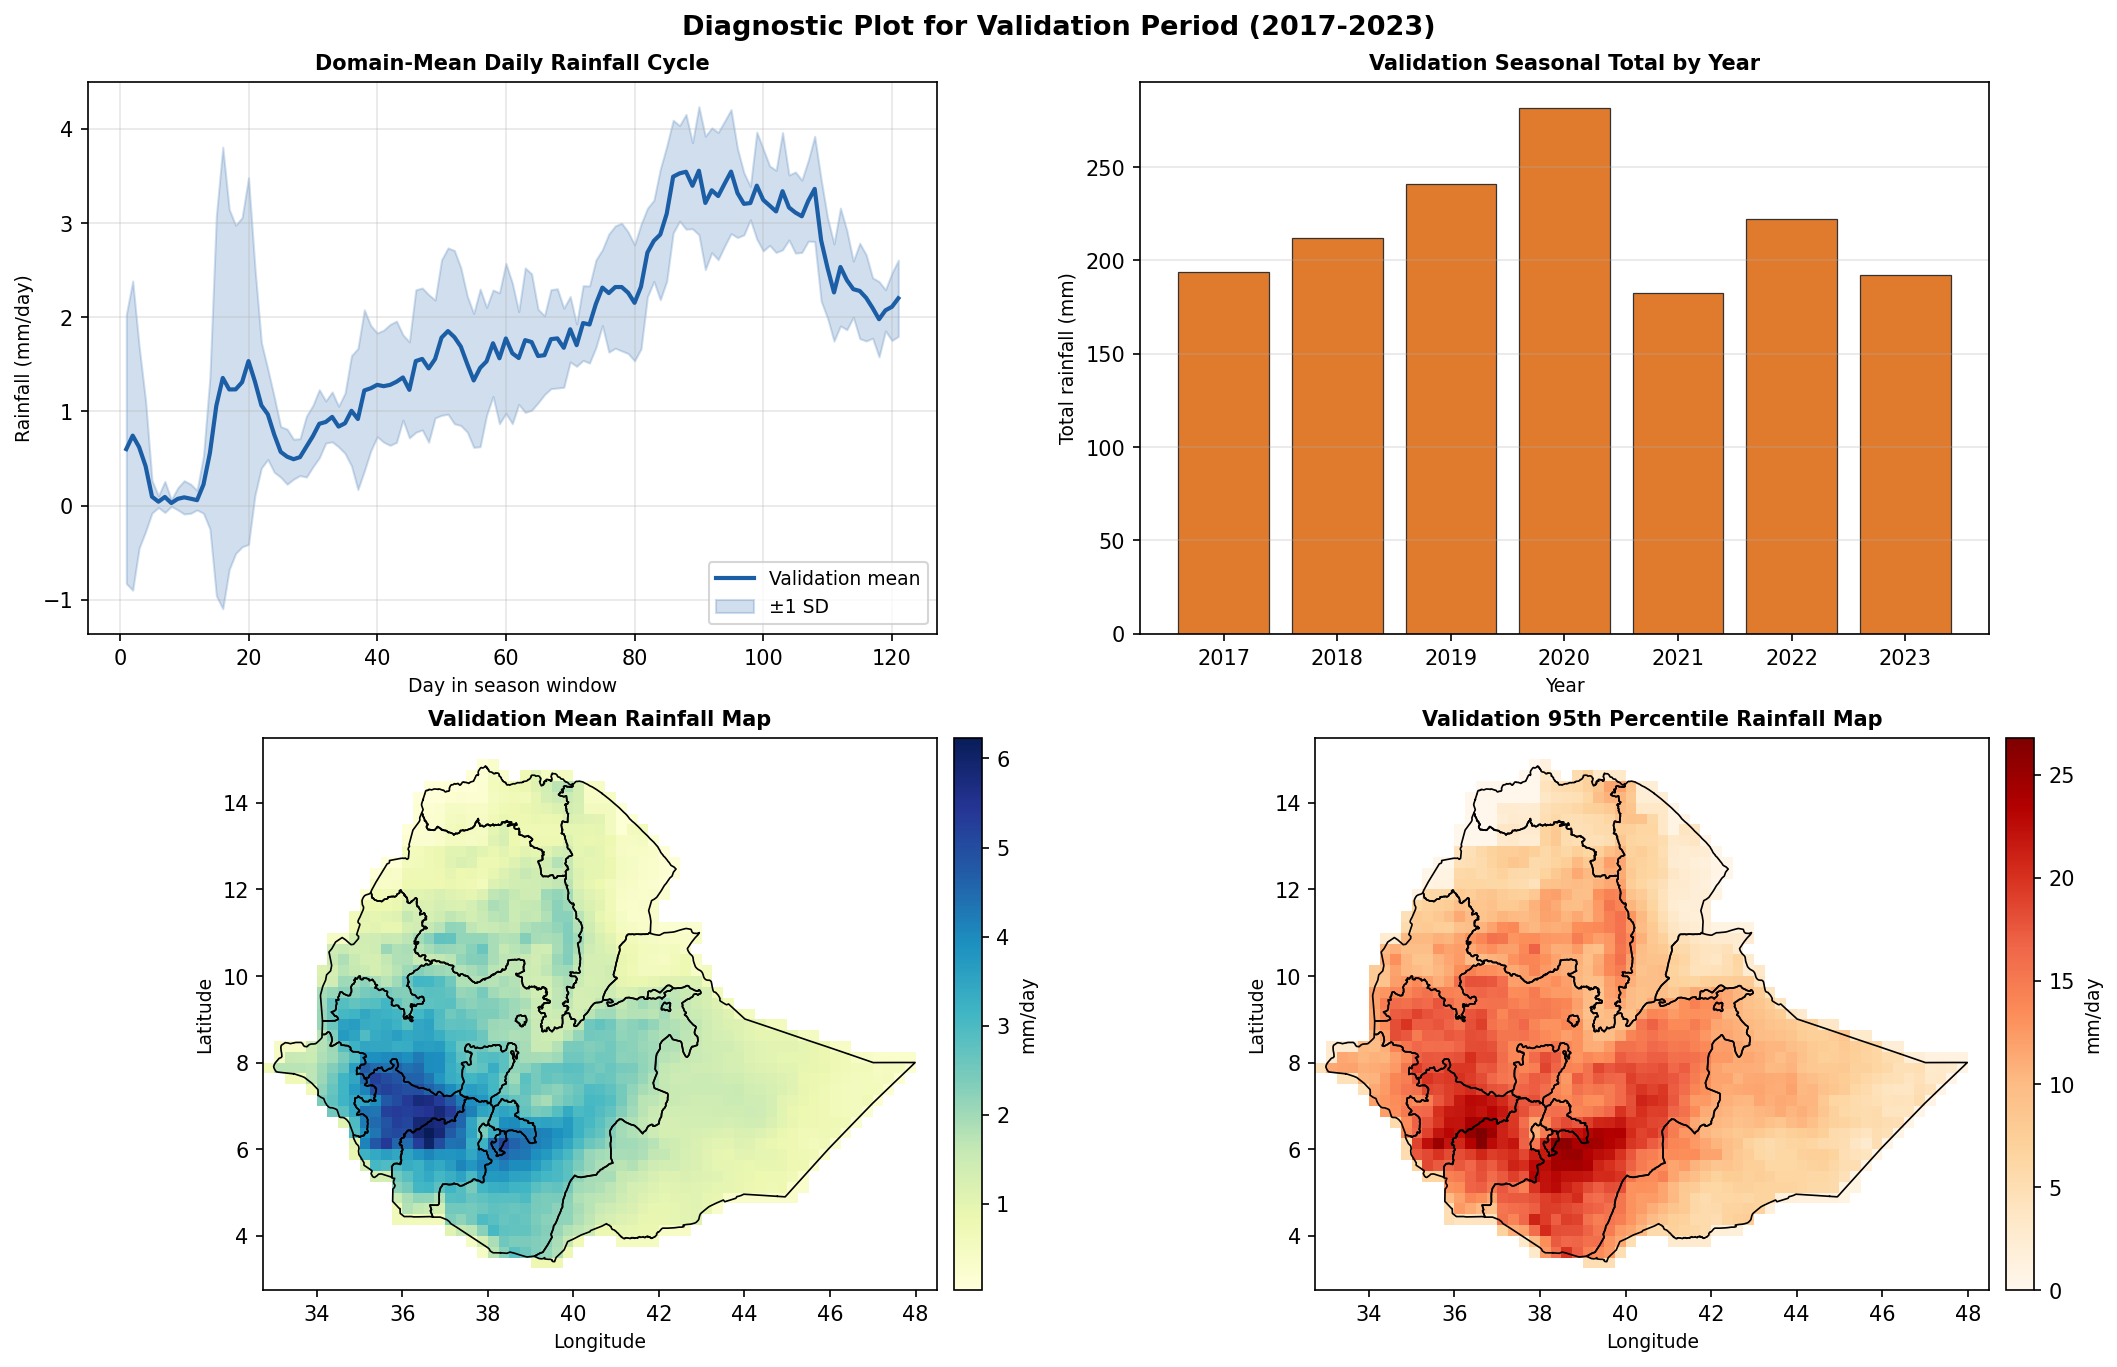

Saved: output_figures\diagnostics\validation_period_diagnostic_panel.png


In [61]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

try:
    import geopandas as gpd
except Exception:
    gpd = None


def resolve_file(relative_candidates):
    search_roots = [Path.cwd(), *Path.cwd().parents]
    for root in search_roots:
        for rel in relative_candidates:
            p = (root / rel).resolve()
            if p.exists():
                return p
    return None


# Validation source (preferred workflow output).
candidate_files = [
    Path("data/processed/seasonal_data/outputs_dwd_v3/DWD_bc_daily_validation_years.nc"),
    Path("outputs/DWD_bc_daily_validation_years.nc"),
]

src = resolve_file(candidate_files)
if src is None:
    raise FileNotFoundError(f"Validation NetCDF not found. Checked: {[str(p) for p in candidate_files]}")

print(f"Using validation source: {src}")

da = xr.open_dataarray(src)

# Expected dimensions: [member, year, day, lat, lon]
required = ["member", "year", "day", "lat", "lon"]
missing = [d for d in required if d not in da.dims]
if missing:
    da.close()
    raise ValueError(f"Missing required dims {missing}; found {da.dims}")

# Resolve country boundary shapefile (Ethiopia)
country_gdf = None
if gpd is not None:
    shp_candidates = [
        Path("ETH_Admins_2024/ETH_Regions.shp"),
        Path("ETH_Admins_2024/ETH_Zones.shp"),
        Path("ETH_Admins_2024/ETH_Woredas.shp"),
    ]
    shp_path = resolve_file(shp_candidates)
    if shp_path is not None:
        try:
            country_gdf = gpd.read_file(shp_path)
            print(f"Country boundary overlay: {shp_path}")
        except Exception as exc:
            print(f"Could not read shapefile ({shp_path}): {exc}")
    else:
        print("No Ethiopia shapefile found for overlay. Plotting without boundaries.")
else:
    print("geopandas is not available. Plotting without shapefile overlay.")

# Domain-mean daily curve per year.
domain_daily = da.mean(dim=["member", "lat", "lon"], skipna=True)  # [year, day]
annual_cycle = domain_daily.mean(dim="year", skipna=True)
annual_std = domain_daily.std(dim="year", skipna=True)

# Seasonal totals by year.
yearly_total = domain_daily.sum(dim="day", skipna=True)

# Spatial diagnostics.
spatial_mean = da.mean(dim=["member", "year", "day"], skipna=True)
spatial_p95 = da.quantile(0.95, dim=["member", "year", "day"], skipna=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

# A) Annual cycle
x_day = np.arange(1, int(domain_daily.sizes["day"]) + 1)
axes[0, 0].plot(x_day, annual_cycle.values, color="#1B5EA6", lw=2.0, label="Validation mean")
axes[0, 0].fill_between(
    x_day,
    (annual_cycle - annual_std).values,
    (annual_cycle + annual_std).values,
    color="#1B5EA6",
    alpha=0.2,
    label="±1 SD",
)
axes[0, 0].set_title("Domain-Mean Daily Rainfall Cycle")
axes[0, 0].set_xlabel("Day in season window")
axes[0, 0].set_ylabel("Rainfall (mm/day)")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend(fontsize=9)

# B) Year totals
years = domain_daily["year"].values.astype(int)
axes[0, 1].bar(years, yearly_total.values, color="#E07A2D", edgecolor="#333333", linewidth=0.6)
axes[0, 1].set_title("Validation Seasonal Total by Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Total rainfall (mm)")
axes[0, 1].grid(axis="y", alpha=0.3)

# C) Spatial mean
im1 = axes[1, 0].pcolormesh(
    da["lon"].values,
    da["lat"].values,
    spatial_mean.values,
    shading="auto",
    cmap="YlGnBu",
)
axes[1, 0].set_title("Validation Mean Rainfall Map")
axes[1, 0].set_xlabel("Longitude")
axes[1, 0].set_ylabel("Latitude")
cb1 = fig.colorbar(im1, ax=axes[1, 0], pad=0.02)
cb1.set_label("mm/day")

# D) Spatial p95
im2 = axes[1, 1].pcolormesh(
    da["lon"].values,
    da["lat"].values,
    spatial_p95.values,
    shading="auto",
    cmap="OrRd",
)
axes[1, 1].set_title("Validation 95th Percentile Rainfall Map")
axes[1, 1].set_xlabel("Longitude")
axes[1, 1].set_ylabel("Latitude")
cb2 = fig.colorbar(im2, ax=axes[1, 1], pad=0.02)
cb2.set_label("mm/day")

# Overlay country boundary on both spatial panels
if country_gdf is not None and len(country_gdf) > 0:
    for ax in [axes[1, 0], axes[1, 1]]:
        country_gdf.boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=5)

fig.suptitle(
    f"Diagnostic Plot for Validation Period ({int(years.min())}-{int(years.max())})",
    fontsize=13,
    fontweight="bold",
)

save_dir = Path("output_figures") / "diagnostics"
save_dir.mkdir(parents=True, exist_ok=True)
out_png = save_dir / "validation_period_diagnostic_panel.png"
fig.savefig(out_png, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")
da.close()

Country boundary overlay: D:\vectri-seasonal\ETH_Admins_2024\ETH_Regions.shp


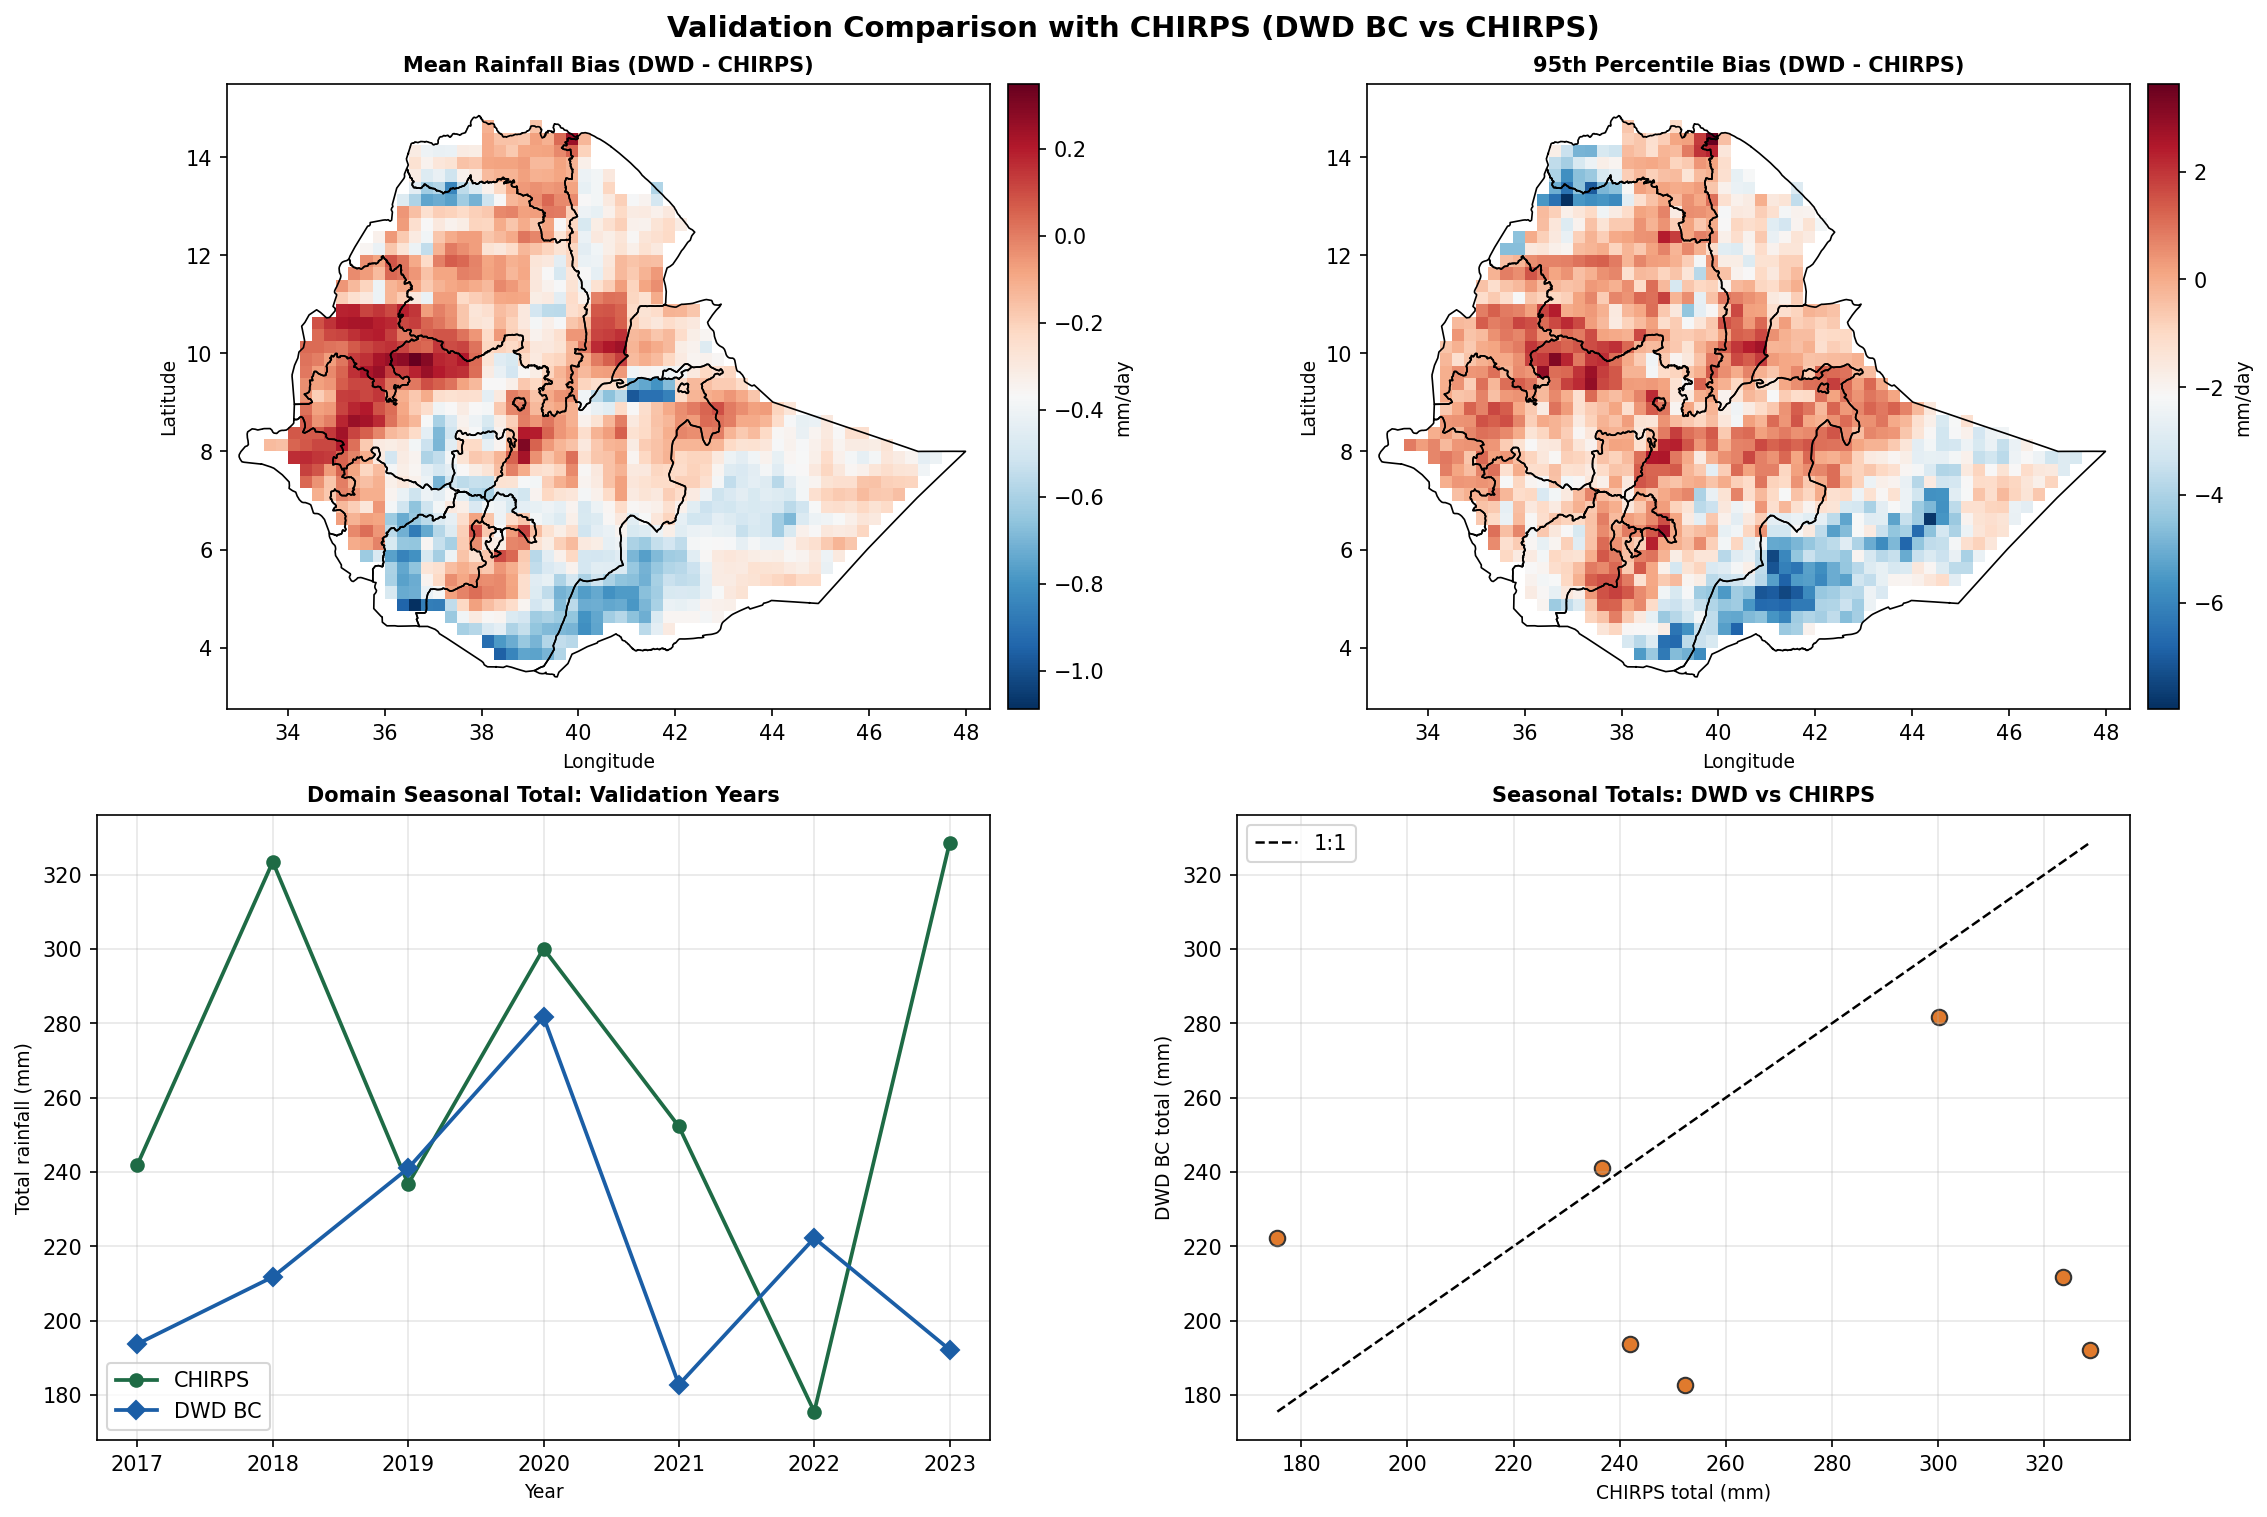

Saved comparison figure: output_figures\diagnostics\validation_dwd_vs_chirps_comparison.png
Validation years compared: [2017, 2018, 2019, 2020, 2021, 2022, 2023]
Domain seasonal total bias (DWD-CHIRPS): -47.60 mm
Domain seasonal total MAE: 62.14 mm


In [62]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

try:
    import geopandas as gpd
except Exception:
    gpd = None


def resolve_file(relative_candidates):
    search_roots = [Path.cwd(), *Path.cwd().parents]
    for root in search_roots:
        for rel in relative_candidates:
            p = (root / rel).resolve()
            if p.exists():
                return p
    return None


# -----------------------------------------------------------------------------
# Validation comparison: DWD BC vs CHIRPS validation data
# -----------------------------------------------------------------------------
dwd_path = resolve_file([
    Path("data/processed/seasonal_data/outputs_dwd_v3/DWD_bc_daily_validation_years.nc"),
])
chirps_path = resolve_file([
    Path("data/processed/chirps/chirps_ethiopia_val_full_20170101_20251231_v1.0.nc"),
])

if not dwd_path:
    raise FileNotFoundError("DWD validation file missing.")
if not chirps_path:
    raise FileNotFoundError("CHIRPS validation file missing.")

# Optional Ethiopia boundary overlay
country_gdf = None
if gpd is not None:
    shp_path = resolve_file([
        Path("ETH_Admins_2024/ETH_Regions.shp"),
        Path("ETH_Admins_2024/ETH_Zones.shp"),
        Path("ETH_Admins_2024/ETH_Woredas.shp"),
    ])
    if shp_path is not None:
        try:
            country_gdf = gpd.read_file(shp_path)
            print(f"Country boundary overlay: {shp_path}")
        except Exception as exc:
            print(f"Could not read shapefile ({shp_path}): {exc}")

# DWD: expected dims [member, year, day, lat, lon]
dwd = xr.open_dataarray(dwd_path)
for dim_name in ["member", "year", "day", "lat", "lon"]:
    if dim_name not in dwd.dims:
        dwd.close()
        raise ValueError(f"Expected dim '{dim_name}' in DWD file, found: {dwd.dims}")

val_years = dwd["year"].values.astype(int)

# CHIRPS: detect variable and coordinates robustly
cds = xr.open_dataset(chirps_path)

chirps_var = None
for v in cds.data_vars:
    vd = cds[v].dims
    if any("time" in d.lower() for d in vd) and any("lat" in d.lower() for d in vd) and any("lon" in d.lower() for d in vd):
        chirps_var = v
        break
if chirps_var is None:
    dwd.close()
    cds.close()
    raise ValueError(f"No CHIRPS variable with time/lat/lon found. Vars: {list(cds.data_vars)}")

ch = cds[chirps_var]
ch_time = next(d for d in ch.dims if "time" in d.lower())
ch_lat = next(d for d in ch.dims if "lat" in d.lower())
ch_lon = next(d for d in ch.dims if "lon" in d.lower())

# Restrict CHIRPS to years available in DWD validation and Belg months (Feb-May)
ch = ch.sel({ch_time: ch[ch_time].dt.year.isin(val_years)})
ch = ch.sel({ch_time: ch[ch_time].dt.month.isin([2, 3, 4, 5])})

# Regrid CHIRPS onto DWD grid for map comparison and standardize dim names
ch_on_dwd = ch.interp({ch_lat: dwd["lat"].values, ch_lon: dwd["lon"].values}, method="linear")
ch_on_dwd = ch_on_dwd.rename({ch_lat: "lat", ch_lon: "lon"})

# --- Climatology maps ---
dwd_mean_map = dwd.mean(dim=["member", "year", "day"], skipna=True)
dwd_p95_map = dwd.quantile(0.95, dim=["member", "year", "day"], skipna=True)

ch_mean_map = ch_on_dwd.mean(dim=ch_time, skipna=True)
ch_p95_map = ch_on_dwd.quantile(0.95, dim=ch_time, skipna=True)

bias_mean_map = dwd_mean_map - ch_mean_map
bias_p95_map = dwd_p95_map - ch_p95_map

# --- Domain seasonal totals by year ---
dwd_domain_daily = dwd.mean(dim=["member", "lat", "lon"], skipna=True)           # [year, day]
dwd_season_total = dwd_domain_daily.sum(dim="day", skipna=True)                      # [year]

ch_domain_daily = ch_on_dwd.mean(dim=["lat", "lon"], skipna=True)                  # [time]
ch_season_total = ch_domain_daily.groupby(f"{ch_time}.year").sum(skipna=True)

common_years = np.intersect1d(dwd_season_total["year"].values.astype(int), ch_season_total["year"].values.astype(int))
dwd_tot_common = dwd_season_total.sel(year=common_years)
ch_tot_common = ch_season_total.sel(year=common_years)

# Summary metrics
mean_bias = float((dwd_tot_common - ch_tot_common).mean().values)
mae = float(np.abs(dwd_tot_common - ch_tot_common).mean().values)

# -----------------------------------------------------------------------------
# Plot comparison panel
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

# A) Mean map bias
im_a = axes[0, 0].pcolormesh(
    dwd["lon"].values,
    dwd["lat"].values,
    bias_mean_map.values,
    cmap="RdBu_r",
    shading="auto",
)
axes[0, 0].set_title("Mean Rainfall Bias (DWD - CHIRPS)")
axes[0, 0].set_xlabel("Longitude")
axes[0, 0].set_ylabel("Latitude")
cb_a = fig.colorbar(im_a, ax=axes[0, 0], pad=0.02)
cb_a.set_label("mm/day")

# B) 95th percentile bias
im_b = axes[0, 1].pcolormesh(
    dwd["lon"].values,
    dwd["lat"].values,
    bias_p95_map.values,
    cmap="RdBu_r",
    shading="auto",
)
axes[0, 1].set_title("95th Percentile Bias (DWD - CHIRPS)")
axes[0, 1].set_xlabel("Longitude")
axes[0, 1].set_ylabel("Latitude")
cb_b = fig.colorbar(im_b, ax=axes[0, 1], pad=0.02)
cb_b.set_label("mm/day")

# Overlay country boundary on the spatial panels
if country_gdf is not None and len(country_gdf) > 0:
    for ax in [axes[0, 0], axes[0, 1]]:
        country_gdf.boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=5)

# C) Year-by-year seasonal totals
axes[1, 0].plot(common_years, ch_tot_common.values, "o-", lw=1.8, color="#1E6B45", label="CHIRPS")
axes[1, 0].plot(common_years, dwd_tot_common.values, "D-", lw=1.8, color="#1B5EA6", label="DWD BC")
axes[1, 0].set_title("Domain Seasonal Total: Validation Years")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Total rainfall (mm)")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# D) Scatter with 1:1 line
xmin = float(min(np.nanmin(ch_tot_common.values), np.nanmin(dwd_tot_common.values)))
xmax = float(max(np.nanmax(ch_tot_common.values), np.nanmax(dwd_tot_common.values)))
axes[1, 1].scatter(ch_tot_common.values, dwd_tot_common.values, s=55, color="#E07A2D", edgecolor="#333333")
axes[1, 1].plot([xmin, xmax], [xmin, xmax], "k--", lw=1.2, label="1:1")
axes[1, 1].set_title("Seasonal Totals: DWD vs CHIRPS")
axes[1, 1].set_xlabel("CHIRPS total (mm)")
axes[1, 1].set_ylabel("DWD BC total (mm)")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

fig.suptitle(
    "Validation Comparison with CHIRPS (DWD BC vs CHIRPS)",
    fontsize=14,
    fontweight="bold",
)

save_dir = Path("output_figures") / "diagnostics"
save_dir.mkdir(parents=True, exist_ok=True)
out_cmp = save_dir / "validation_dwd_vs_chirps_comparison.png"
fig.savefig(out_cmp, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved comparison figure: {out_cmp}")
print(f"Validation years compared: {common_years.tolist()}")
print(f"Domain seasonal total bias (DWD-CHIRPS): {mean_bias:.2f} mm")
print(f"Domain seasonal total MAE: {mae:.2f} mm")

# Keep opened objects tidy
dwd.close()
cds.close()

## Interpretation of the 4th Validation Map (95th Percentile Rainfall)

- This map highlights where **high-intensity rainfall events** are most likely during the validation period.
- The strongest extremes are concentrated in the **southwestern to central-western corridor** (roughly longitudes 35-40E and latitudes 4-8N), consistent with the wettest core seen in the mean map.
- Eastern and northeastern areas show lower 95th percentile values, indicating fewer or weaker extreme daily rainfall events.
- Because percentile maps can be sensitive to missing or masked cells, interpret isolated tiny patches cautiously and focus on broad spatial patterns.

In practical terms, this panel helps identify where heavy-rainfall-driven mosquito habitat pulses are most likely during validation years.

## Plot Operational Year Dataset (Bias-Corrected)

This section plots the **operational year** precipitation dataset after bias correction, including:
- Spatial diagnostics (mean and 95th percentile maps)
- Time-series diagnostics (domain-mean daily rainfall and ensemble spread)

## Operational-year diagnostics from bias-corrected dataset

Using operational BC source: D:\vectri-seasonal\data\processed\seasonal_data\outputs_dwd_v3\DWD_bc_daily_operational_2026.nc
Country boundary overlay: D:\vectri-seasonal\ETH_Admins_2024\ETH_Regions.shp


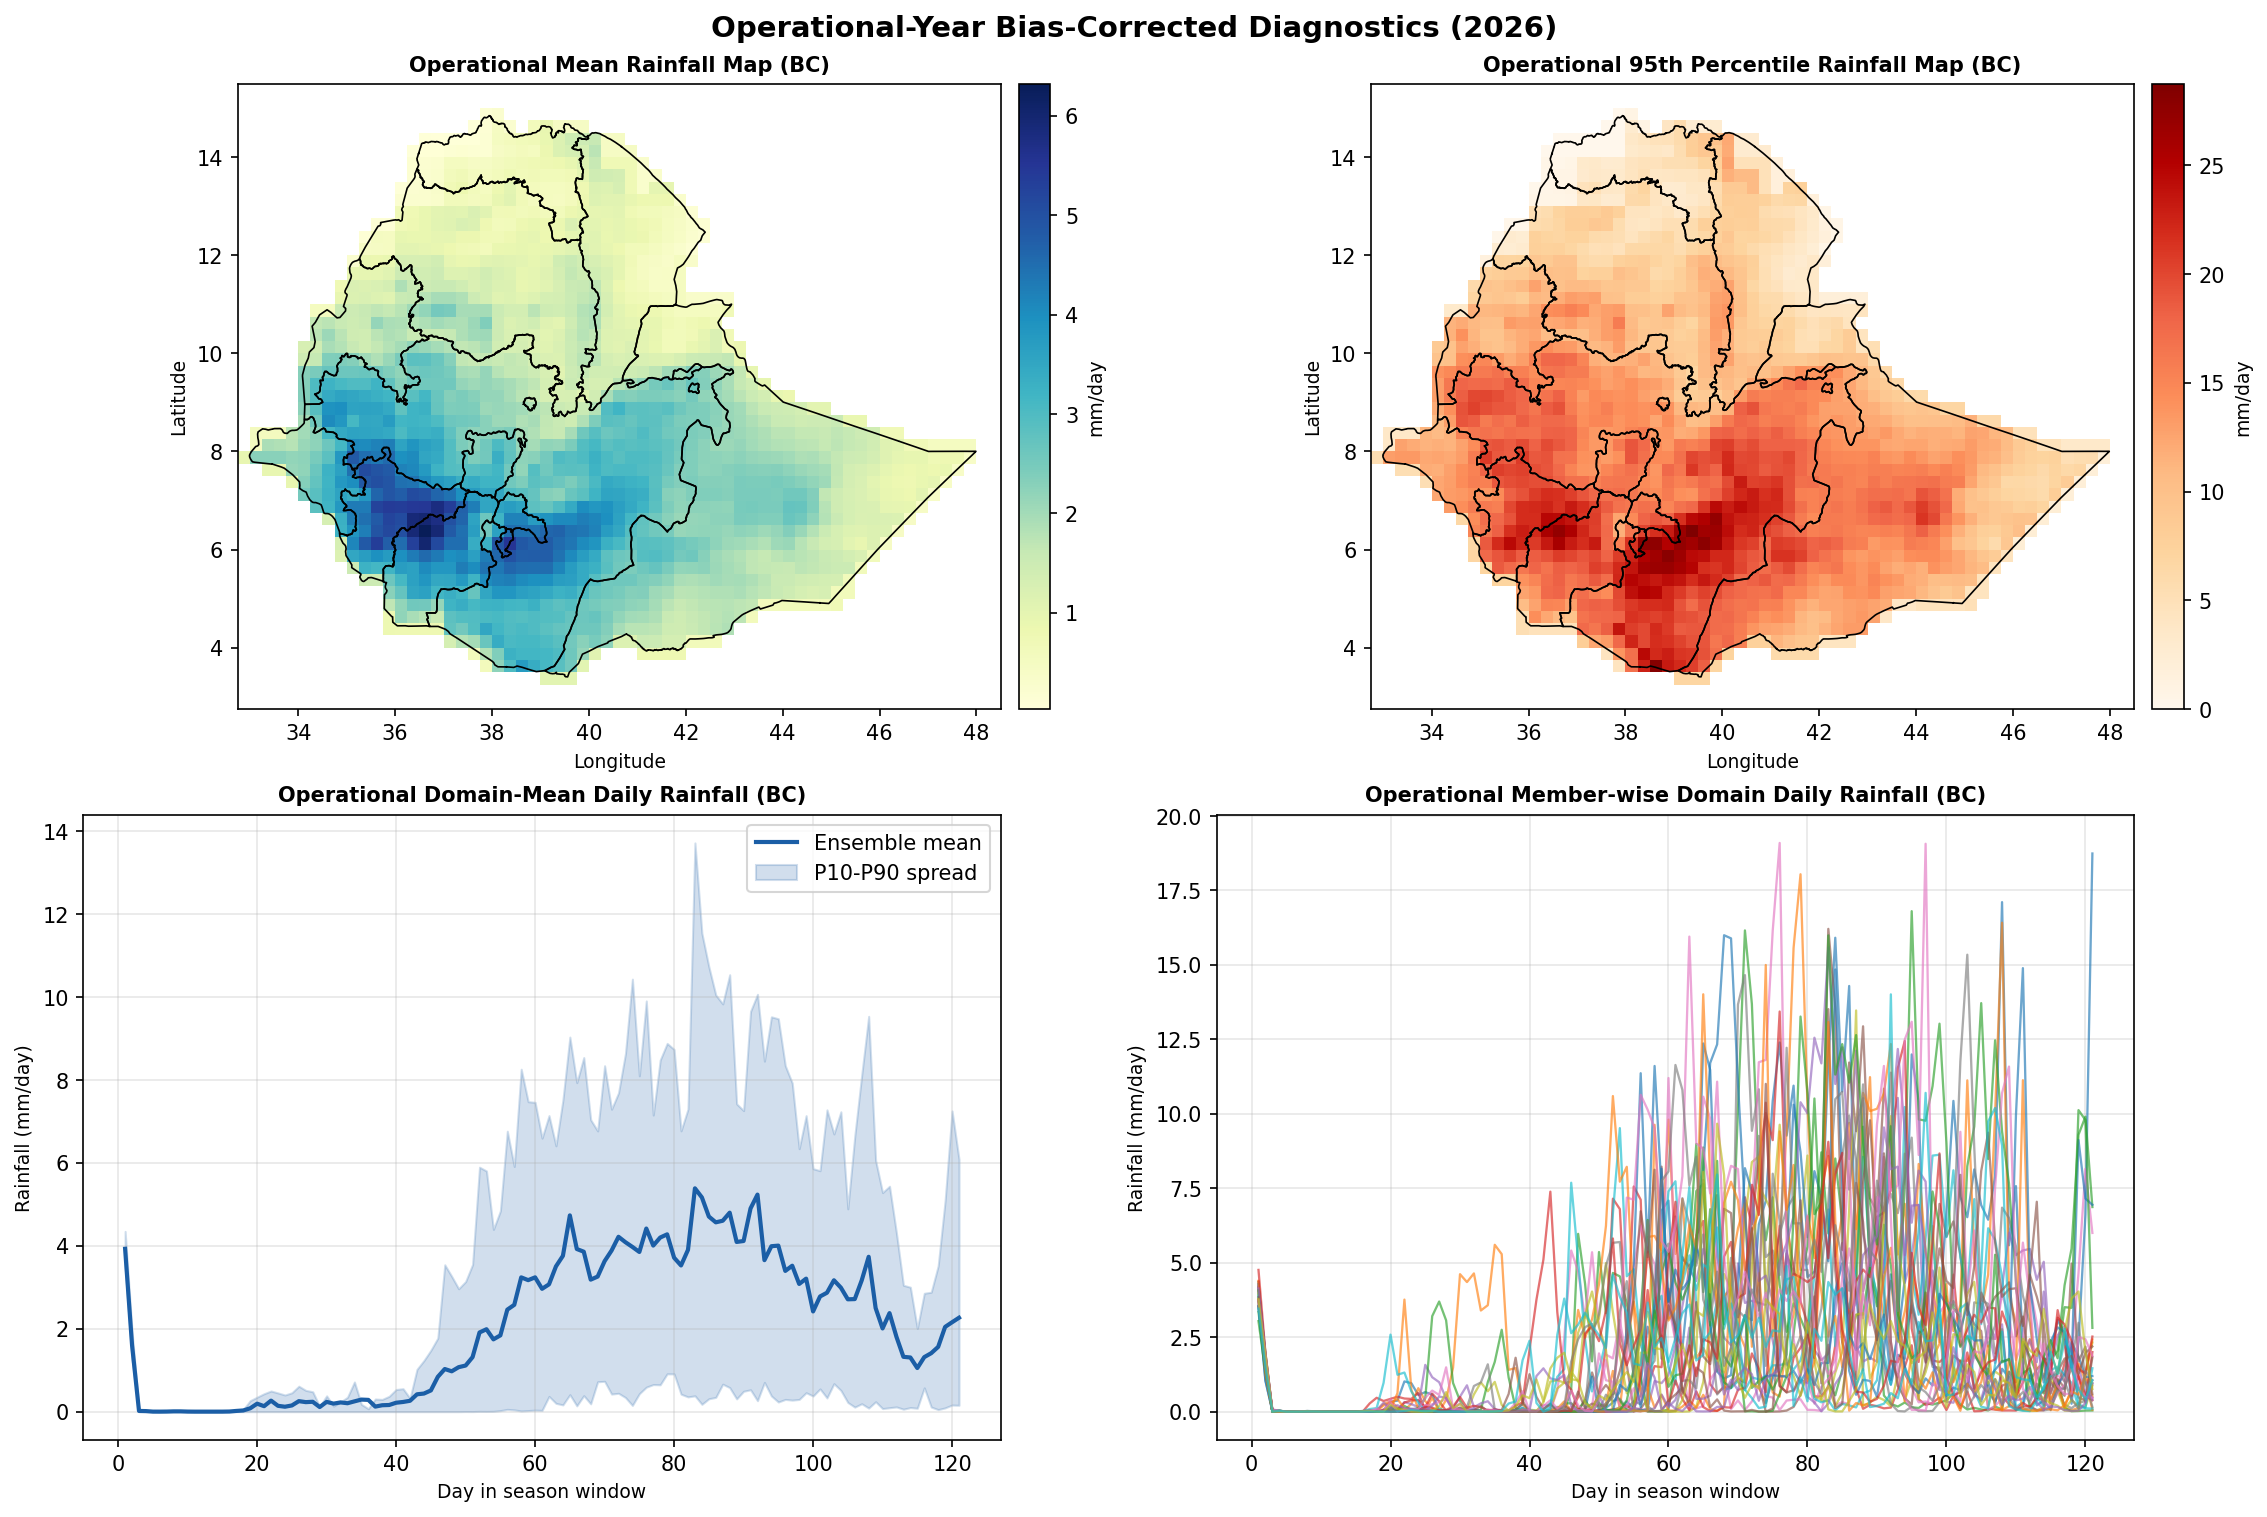

Saved: output_figures\diagnostics\operational_2026_bc_spatial_timeseries.png
Shape used for plotting: (30, 121, 51, 63) | dims: ('member', 'day', 'lat', 'lon')


In [ ]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Optional shapefile overlay
try:
    import geopandas as gpd
except Exception:
    gpd = None


def resolve_file(relative_candidates):
    """Resolve a file by searching from cwd and parent directories."""
    search_roots = [Path.cwd(), *Path.cwd().parents]
    for root in search_roots:
        for rel in relative_candidates:
            p = (root / rel).resolve()
            if p.exists():
                return p
    return None


op_rel_candidates = [
    Path("data/processed/seasonal_data/outputs_dwd_v3/DWD_bc_daily_operational_2026.nc"),
    Path("outputs/DWD_bc_daily_operational_2026.nc"),
    Path("data/processed/seasonal_data/outputs_dwd_v3/DWD_bc_daily_operational.nc"),
]

op_path = resolve_file(op_rel_candidates)
if op_path is None:
    raise FileNotFoundError(
        "Operational BC file not found. Checked relative paths: "
        f"{[str(p) for p in op_rel_candidates]} from cwd/parents"
    )

print(f"Using operational BC source: {op_path}")
op = xr.open_dataarray(op_path)

# Expected dimensions: [member, year, day, lat, lon] (year can be length-1)
for d in ["member", "day", "lat", "lon"]:
    if d not in op.dims:
        op.close()
        raise ValueError(f"Expected dim '{d}' in operational BC file, found: {op.dims}")

# If year dimension exists, squeeze it for cleaner plotting.
if "year" in op.dims and op.sizes["year"] == 1:
    op_plot = op.isel(year=0)
    op_year_label = int(op["year"].values[0])
else:
    op_plot = op
    op_year_label = 2026

# Spatial diagnostics
spatial_mean = op_plot.mean(dim=["member", "day"], skipna=True)
spatial_p95 = op_plot.quantile(0.95, dim=["member", "day"], skipna=True)

# Time-series diagnostics
ts_member = op_plot.mean(dim=["lat", "lon"], skipna=True)         # [member, day]
ts_mean = ts_member.mean(dim="member", skipna=True)                 # [day]
ts_p10 = ts_member.quantile(0.10, dim="member", skipna=True)
ts_p90 = ts_member.quantile(0.90, dim="member", skipna=True)

x_day = np.arange(1, ts_mean.sizes["day"] + 1)

# Resolve country boundary shapefile (Ethiopia)
country_gdf = None
if gpd is not None:
    shp_rel_candidates = [
        Path("ETH_Admins_2024/ETH_Regions.shp"),
        Path("ETH_Admins_2024/ETH_Zones.shp"),
        Path("ETH_Admins_2024/ETH_Woredas.shp"),
    ]
    shp_path = resolve_file(shp_rel_candidates)
    if shp_path is not None:
        try:
            country_gdf = gpd.read_file(shp_path)
            print(f"Country boundary overlay: {shp_path}")
        except Exception as exc:
            print(f"Could not read shapefile ({shp_path}): {exc}")
    else:
        print("No Ethiopia shapefile found for overlay. Plotting without boundaries.")
else:
    print("geopandas is not available. Plotting without shapefile overlay.")

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

# A) Spatial mean map
im1 = axes[0, 0].pcolormesh(
    op_plot["lon"].values,
    op_plot["lat"].values,
    spatial_mean.values,
    cmap="YlGnBu",
    shading="auto",
)
axes[0, 0].set_title("Operational Mean Rainfall Map (BC)")
axes[0, 0].set_xlabel("Longitude")
axes[0, 0].set_ylabel("Latitude")
cb1 = fig.colorbar(im1, ax=axes[0, 0], pad=0.02)
cb1.set_label("mm/day")

# B) Spatial p95 map
im2 = axes[0, 1].pcolormesh(
    op_plot["lon"].values,
    op_plot["lat"].values,
    spatial_p95.values,
    cmap="OrRd",
    shading="auto",
)
axes[0, 1].set_title("Operational 95th Percentile Rainfall Map (BC)")
axes[0, 1].set_xlabel("Longitude")
axes[0, 1].set_ylabel("Latitude")
cb2 = fig.colorbar(im2, ax=axes[0, 1], pad=0.02)
cb2.set_label("mm/day")

# Overlay country boundary on both map axes
if country_gdf is not None and len(country_gdf) > 0:
    for ax in [axes[0, 0], axes[0, 1]]:
        country_gdf.boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=5)

# C) Domain-mean daily time series with all members + spread + mean
for idx, m in enumerate(op_plot["member"].values):
    label = "All members" if idx == 0 else None
    axes[1, 0].plot(
        x_day,
        ts_member.sel(member=m).values,
        color="#4C78A8",
        lw=0.9,
        alpha=0.35,
        label=label,
        zorder=1,
    )

axes[1, 0].fill_between(
    x_day,
    ts_p10.values,
    ts_p90.values,
    color="#1B5EA6",
    alpha=0.2,
    label="P10-P90 spread",
    zorder=2,
)
axes[1, 0].plot(x_day, ts_mean.values, color="#1B5EA6", lw=2.2, label="Ensemble mean", zorder=3)
axes[1, 0].set_title("Operational Domain-Mean Daily Rainfall (BC)")
axes[1, 0].set_xlabel("Day in season window")
axes[1, 0].set_ylabel("Rainfall (mm/day)")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# D) Individual member trajectories
for m in op_plot["member"].values:
    axes[1, 1].plot(x_day, ts_member.sel(member=m).values, lw=1.1, alpha=0.65)
axes[1, 1].set_title("Operational Member-wise Domain Daily Rainfall (BC)")
axes[1, 1].set_xlabel("Day in season window")
axes[1, 1].set_ylabel("Rainfall (mm/day)")
axes[1, 1].grid(alpha=0.3)

fig.suptitle(
    f"Operational-Year Bias-Corrected Diagnostics ({op_year_label})",
    fontsize=14,
    fontweight="bold",
    y = 1.06,

)

save_dir = Path("output_figures") / "diagnostics"
save_dir.mkdir(parents=True, exist_ok=True)
out_file = save_dir / f"operational_{op_year_label}_bc_spatial_timeseries.png"
fig.savefig(out_file, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved: {out_file}")
print(f"Shape used for plotting: {tuple(op_plot.shape)} | dims: {op_plot.dims}")

op.close()

## Operational vs Validation Climatology Overlay

This section compares the 2026 operational bias-corrected rainfall signal against the validation climatology (2017-2023):
- Domain-mean daily rainfall overlay
- Ensemble spread comparison (P10-P90)
- Cumulative rainfall comparison
- Daily anomaly (Operational minus Validation climatology)

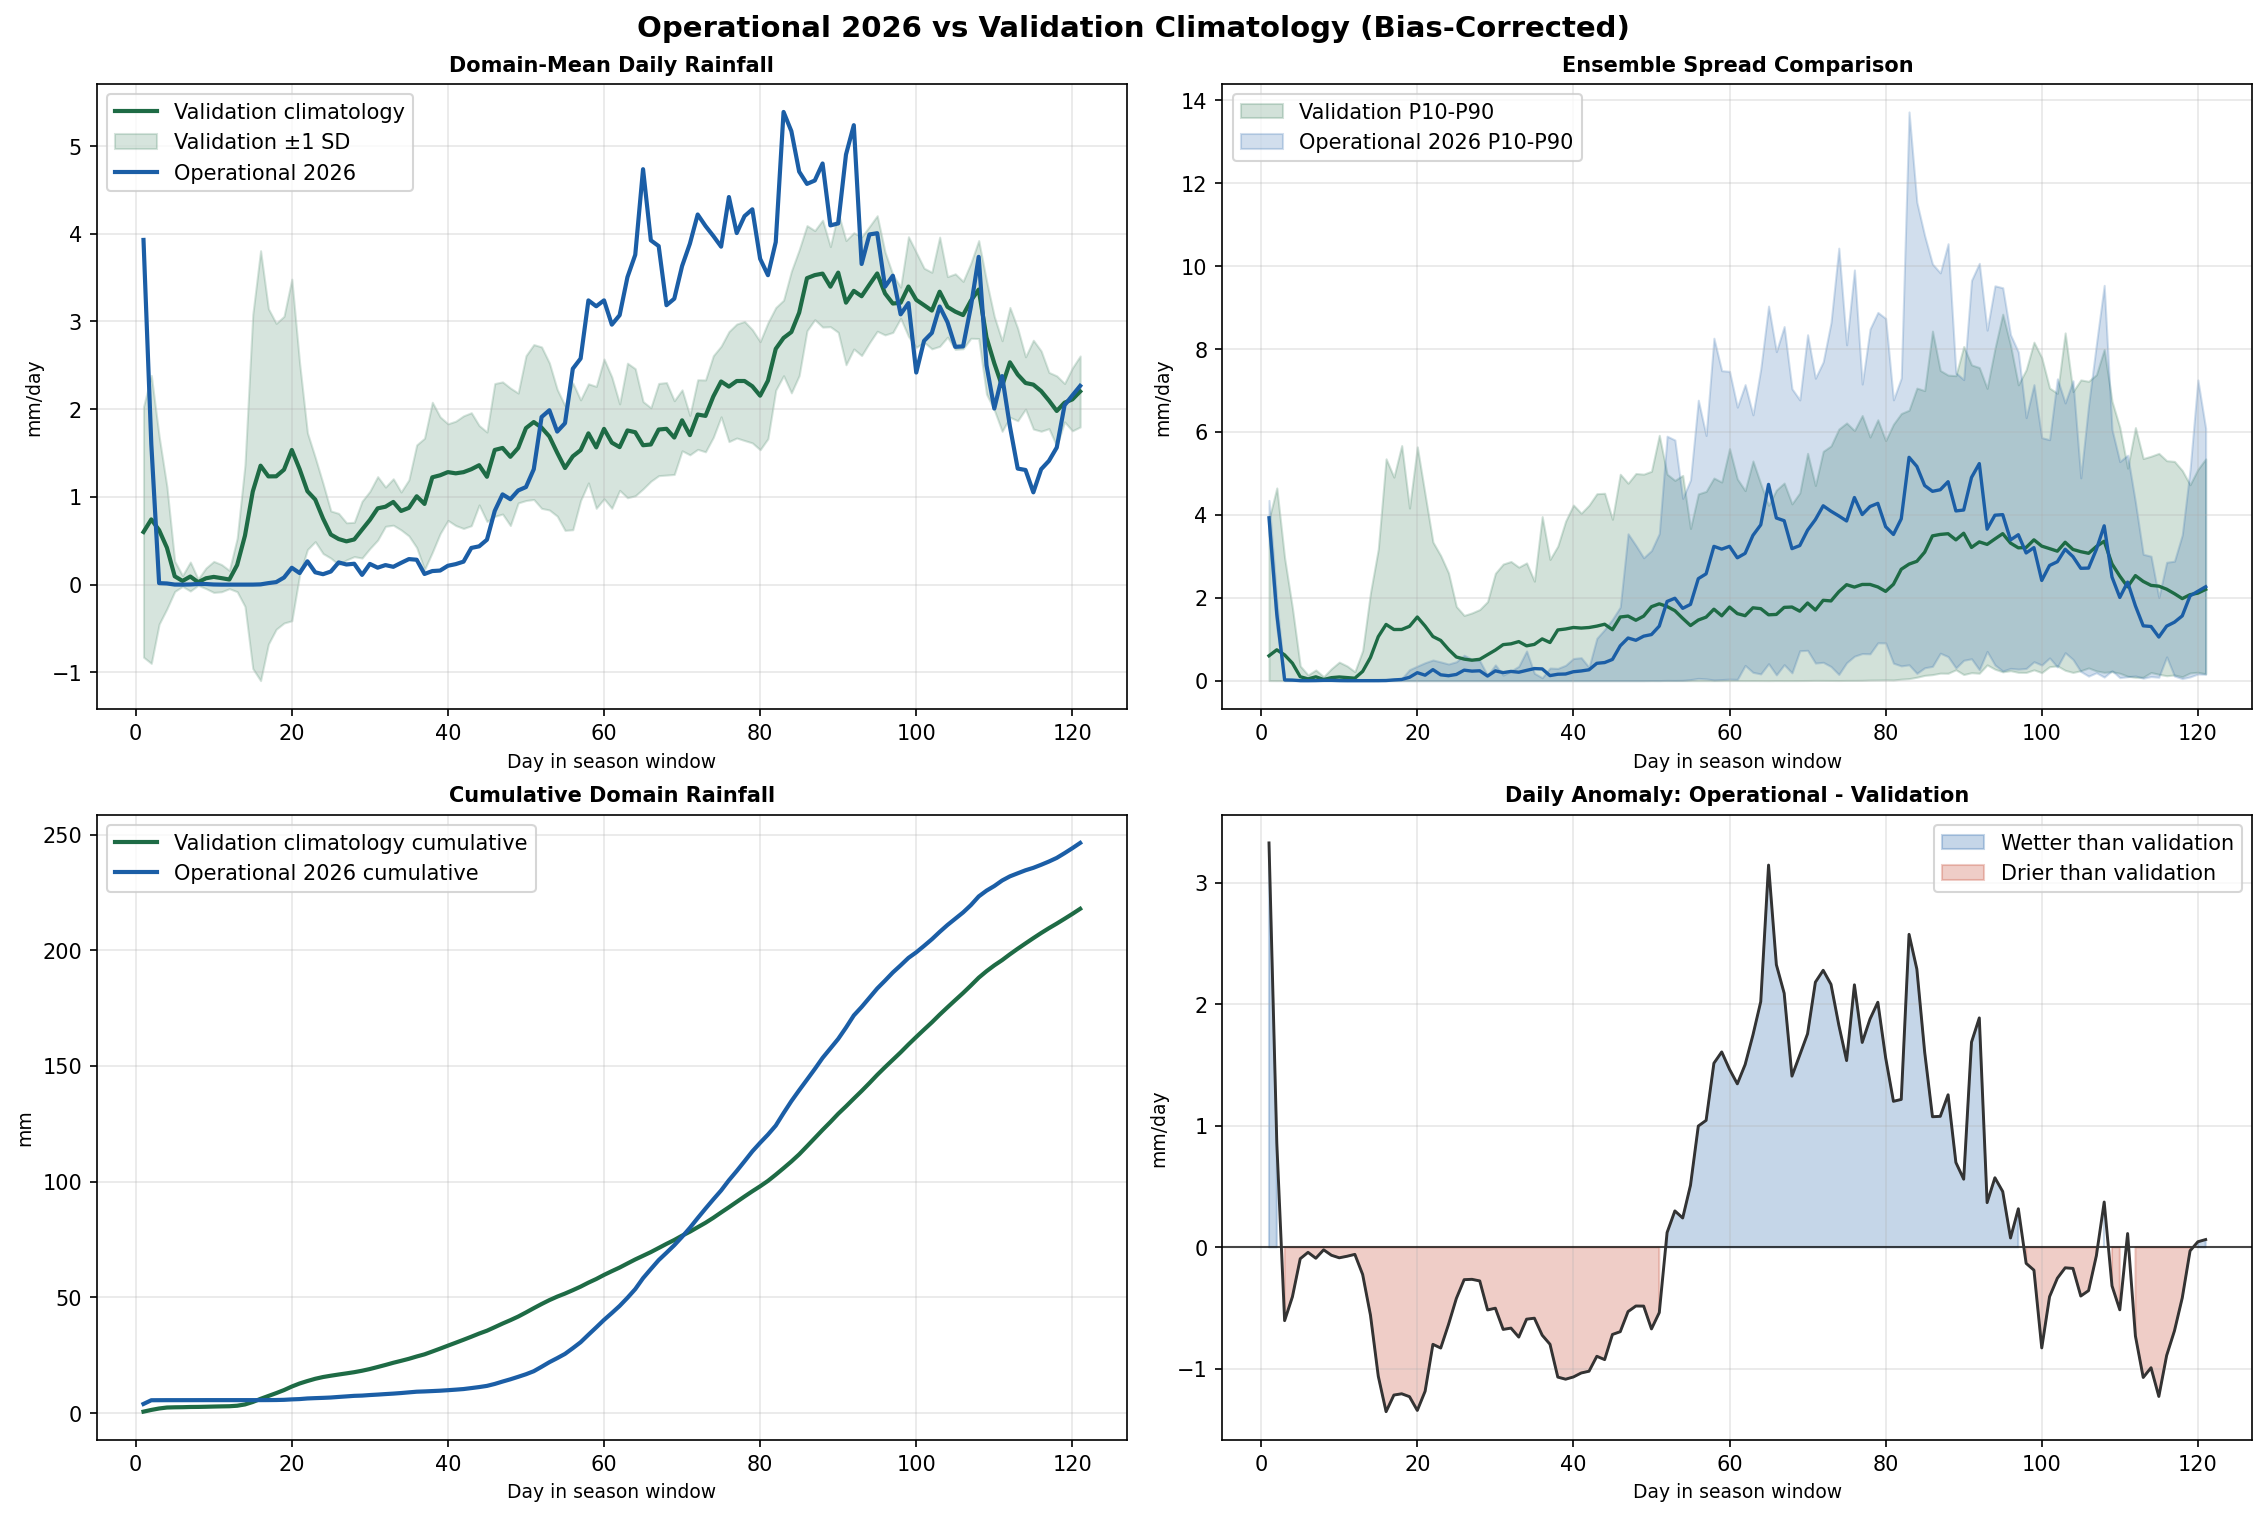

Saved overlay figure: output_figures\diagnostics\operational_2026_vs_validation_overlay.png
Final cumulative rainfall | Validation: 217.9 mm | Operational 2026: 246.4 mm


In [60]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Overlay: operational 2026 vs validation climatology
# -----------------------------------------------------------------------------
val_path = Path("data/processed/seasonal_data/outputs_dwd_v3/DWD_bc_daily_validation_years.nc")
op_path = Path("data/processed/seasonal_data/outputs_dwd_v3/DWD_bc_daily_operational_2026.nc")

if not val_path.exists():
    raise FileNotFoundError(f"Validation BC file missing: {val_path}")
if not op_path.exists():
    raise FileNotFoundError(f"Operational BC file missing: {op_path}")

val = xr.open_dataarray(val_path)   # [member, year, day, lat, lon]
op = xr.open_dataarray(op_path)     # [member, year, day, lat, lon] or [member, day, lat, lon]

for d in ["member", "day", "lat", "lon"]:
    if d not in val.dims or d not in op.dims:
        val.close()
        op.close()
        raise ValueError(f"Required dim '{d}' not found in both datasets. val={val.dims}, op={op.dims}")

# Squeeze single operational year dim if present
if "year" in op.dims and op.sizes["year"] == 1:
    op_ = op.isel(year=0)
    op_year = int(op["year"].values[0])
else:
    op_ = op
    op_year = 2026

# Build domain-mean ensemble daily series
val_dom = val.mean(dim=["lat", "lon"], skipna=True)                 # [member, year, day]
val_ens_year = val_dom.mean(dim="member", skipna=True)               # [year, day]
val_clim = val_ens_year.mean(dim="year", skipna=True)                # [day]
val_clim_sd = val_ens_year.std(dim="year", skipna=True)              # [day]

val_p10 = val_dom.quantile(0.10, dim=["member", "year"], skipna=True)  # [day]
val_p90 = val_dom.quantile(0.90, dim=["member", "year"], skipna=True)  # [day]

op_dom = op_.mean(dim=["lat", "lon"], skipna=True)                  # [member, day]
op_mean = op_dom.mean(dim="member", skipna=True)                     # [day]
op_p10 = op_dom.quantile(0.10, dim="member", skipna=True)            # [day]
op_p90 = op_dom.quantile(0.90, dim="member", skipna=True)            # [day]

day_n = int(min(val_clim.sizes["day"], op_mean.sizes["day"]))
val_clim = val_clim.isel(day=slice(0, day_n))
val_clim_sd = val_clim_sd.isel(day=slice(0, day_n))
val_p10 = val_p10.isel(day=slice(0, day_n))
val_p90 = val_p90.isel(day=slice(0, day_n))
op_mean = op_mean.isel(day=slice(0, day_n))
op_p10 = op_p10.isel(day=slice(0, day_n))
op_p90 = op_p90.isel(day=slice(0, day_n))

x_day = np.arange(1, day_n + 1)

# Cumulative series
val_cum = np.cumsum(val_clim.values)
op_cum = np.cumsum(op_mean.values)

# Daily anomaly
anom = op_mean.values - val_clim.values

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

# A) Mean daily overlay
axes[0, 0].plot(x_day, val_clim.values, color="#1E6B45", lw=2.0, label="Validation climatology")
axes[0, 0].fill_between(
    x_day,
    (val_clim - val_clim_sd).values,
    (val_clim + val_clim_sd).values,
    color="#1E6B45",
    alpha=0.18,
    label="Validation ±1 SD",
)
axes[0, 0].plot(x_day, op_mean.values, color="#1B5EA6", lw=2.0, label=f"Operational {op_year}")
axes[0, 0].set_title("Domain-Mean Daily Rainfall")
axes[0, 0].set_xlabel("Day in season window")
axes[0, 0].set_ylabel("mm/day")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# B) Spread overlay (P10-P90)
axes[0, 1].fill_between(x_day, val_p10.values, val_p90.values, color="#1E6B45", alpha=0.20, label="Validation P10-P90")
axes[0, 1].fill_between(x_day, op_p10.values, op_p90.values, color="#1B5EA6", alpha=0.20, label=f"Operational {op_year} P10-P90")
axes[0, 1].plot(x_day, val_clim.values, color="#1E6B45", lw=1.6)
axes[0, 1].plot(x_day, op_mean.values, color="#1B5EA6", lw=1.6)
axes[0, 1].set_title("Ensemble Spread Comparison")
axes[0, 1].set_xlabel("Day in season window")
axes[0, 1].set_ylabel("mm/day")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

# C) Cumulative rainfall
axes[1, 0].plot(x_day, val_cum, color="#1E6B45", lw=2.0, label="Validation climatology cumulative")
axes[1, 0].plot(x_day, op_cum, color="#1B5EA6", lw=2.0, label=f"Operational {op_year} cumulative")
axes[1, 0].set_title("Cumulative Domain Rainfall")
axes[1, 0].set_xlabel("Day in season window")
axes[1, 0].set_ylabel("mm")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# D) Daily anomaly
axes[1, 1].axhline(0.0, color="k", lw=1.0, alpha=0.7)
axes[1, 1].fill_between(x_day, 0, anom, where=anom >= 0, color="#1B5EA6", alpha=0.25, label="Wetter than validation")
axes[1, 1].fill_between(x_day, 0, anom, where=anom < 0, color="#C23B22", alpha=0.25, label="Drier than validation")
axes[1, 1].plot(x_day, anom, color="#333333", lw=1.4)
axes[1, 1].set_title("Daily Anomaly: Operational - Validation")
axes[1, 1].set_xlabel("Day in season window")
axes[1, 1].set_ylabel("mm/day")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

fig.suptitle(f"Operational {op_year} vs Validation Climatology (Bias-Corrected)", fontsize=14, fontweight="bold")

save_dir = Path("output_figures") / "diagnostics"
save_dir.mkdir(parents=True, exist_ok=True)
out_overlay = save_dir / f"operational_{op_year}_vs_validation_overlay.png"
fig.savefig(out_overlay, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved overlay figure: {out_overlay}")
print(f"Final cumulative rainfall | Validation: {val_cum[-1]:.1f} mm | Operational {op_year}: {op_cum[-1]:.1f} mm")

val.close()
op.close()